In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to loadimport numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import osfor dirname, _, filenames in os.walk('/kaggle/input')for filename in filenames: print(os.path.join(dirname, filename))


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install -q ultralytics kagglehub opencv-python-headless

In [1]:
import subprocess
subprocess.run(["apt-get", "install", "-y", "-q", "libzbar0"], capture_output=True)

!pip install -q ultralytics rapidfuzz thefuzz python-Levenshtein easyocr pyzbar opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.7 MB/s eta 0:00:00


In [2]:
import os, json, cv2, re, shutil, random, yaml, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
import easyocr
import torch
from rapidfuzz import fuzz as rfuzz
from thefuzz import fuzz
from pyzbar import pyzbar as pyzbar_lib

print("✅ All imports successful")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All imports successful


In [3]:
random.seed(42)

BASE_DIR  = Path('/kaggle/working/smart_retail_data')
YAML_PATH = '/kaggle/working/smart_retail.yaml'

for split in ['train', 'val']:
    (BASE_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (BASE_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

print("✅ Directory structure ready")
print(f"   {BASE_DIR}/")
print(f"   ├── train/images/")
print(f"   ├── train/labels/")
print(f"   ├── val/images/")
print(f"   └── val/labels/")

✅ Directory structure ready
   /kaggle/working/smart_retail_data/
   ├── train/images/
   ├── train/labels/
   ├── val/images/
   └── val/labels/


In [4]:
def explore_dataset(dataset_path, max_depth=3):
    dataset_path = Path(dataset_path)
    if not dataset_path.exists():
        print(f"❌ Path does not exist: {dataset_path}")
        return
    print(f"\n📁 {dataset_path}")
    for i, p in enumerate(sorted(dataset_path.rglob('*'))):
        depth = len(p.relative_to(dataset_path).parts)
        if depth > max_depth:
            continue
        indent = "   " * (depth - 1)
        if p.is_dir():
            n_files = len(list(p.iterdir()))
            print(f"{indent}📂 {p.name}/  ({n_files} items)")
        else:
            print(f"{indent}📄 {p.name}")
        if i > 60:
            print("   ... (truncated)")
            break

print("=== ALL AVAILABLE DATASETS ===")
for folder in sorted(Path("/kaggle/input").iterdir()):
    imgs = list(folder.rglob("*.jpg")) + list(folder.rglob("*.png"))
    print(f"  📂 {folder.name}  ({len(imgs)} images found)")

explore_dataset("/kaggle/input/open-food-facts")
explore_dataset("/kaggle/input/grocery-dataset-part-1")
explore_dataset("/kaggle/input/retail-product-checkout")
explore_dataset("/kaggle/input/barcode-and-qr-codes")

=== ALL AVAILABLE DATASETS ===
  📂 datasets  (168346 images found)
❌ Path does not exist: /kaggle/input/open-food-facts
❌ Path does not exist: /kaggle/input/grocery-dataset-part-1
❌ Path does not exist: /kaggle/input/retail-product-checkout
❌ Path does not exist: /kaggle/input/barcode-and-qr-codes


In [4]:
from pathlib import Path

datasets_root = Path("/kaggle/input/datasets")

print("=== STRUCTURE INSIDE /kaggle/input/datasets/ ===")
for item in sorted(datasets_root.iterdir()):
    if item.is_dir():
        imgs = list(item.rglob("*.jpg")) + list(item.rglob("*.png")) + list(item.rglob("*.jpeg"))
        print(f"\n📂 {item.name}/  ({len(imgs)} images)")
        for sub in sorted(item.iterdir()):
            if sub.is_dir():
                sub_imgs = list(sub.rglob("*.jpg")) + list(sub.rglob("*.png"))
                print(f"   📂 {sub.name}/  ({len(sub_imgs)} images)")
            else:
                print(f"   📄 {sub.name}")

for path in [
    "/kaggle/input/datasets/diyer22/retail-product-checkout-dataset",
    "/kaggle/input/datasets/jonathanimmanuel/barcode-and-qr"
]:
    p = Path(path)
    print(f"\n📂 {p.name}")
    for sub in sorted(p.iterdir()):
        imgs = list(sub.rglob("*.jpg")) + list(sub.rglob("*.png"))
        print(f"   📂 {sub.name}/  ({len(imgs)} images)")

=== STRUCTURE INSIDE /kaggle/input/datasets/ ===

📂 diyer22/  (167478 images)
   📂 retail-product-checkout-dataset/  (167478 images)

📂 elvinrustam/  (0 images)
   📂 grocery-dataset/  (0 images)

📂 ishitadas2004/  (7 images)
   📂 lookup-product-by-barcode/  (0 images)
   📂 product-images/  (0 images)

📂 jonathanimmanuel/  (868 images)
   📂 barcode-and-qr/  (868 images)

📂 konradb/  (0 images)
   📂 open-food-facts/  (0 images)

📂 retail-product-checkout-dataset
   📂 instances_test2019.json/  (0 images)
   📂 instances_train2019.json/  (0 images)
   📂 instances_val2019.json/  (0 images)
   📂 retail_product_checkout/  (83739 images)
   📂 test2019/  (24000 images)
   📂 train2019/  (53739 images)
   📂 val2019/  (6000 images)

📂 barcode-and-qr
   📂 05102009081.jpg/  (0 images)
   📂 05102009081.xml/  (0 images)
   📂 05102009082.jpg/  (0 images)
   📂 05102009082.xml/  (0 images)
   📂 05102009083.jpg/  (0 images)
   📂 05102009083.xml/  (0 images)
   📂 05102009101.jpg/  (0 images)
   📂 0510200910

In [5]:
RETAIL_TRAIN = Path("/kaggle/input/datasets/diyer22/retail-product-checkout-dataset/train2019")

all_imgs = (list(RETAIL_TRAIN.glob("*.jpg")) +
            list(RETAIL_TRAIN.glob("*.jpeg")) +
            list(RETAIL_TRAIN.glob("*.png")))

print(f"Found {len(all_imgs)} retail images in train2019/")

random.shuffle(all_imgs)
selected  = all_imgs[:3000]
split_idx = int(len(selected) * 0.85)
train_imgs, val_imgs = selected[:split_idx], selected[split_idx:]

for img in train_imgs:
    dest = BASE_DIR / 'train/images' / ('ret_' + img.name)
    shutil.copy(img, dest)
    with open(BASE_DIR / 'train/labels' / ('ret_' + img.stem + '.txt'), 'w') as f:
        f.write("0 0.5 0.5 0.9 0.9\n")

for img in val_imgs:
    dest = BASE_DIR / 'val/images' / ('ret_' + img.name)
    shutil.copy(img, dest)
    with open(BASE_DIR / 'val/labels' / ('ret_' + img.stem + '.txt'), 'w') as f:
        f.write("0 0.5 0.5 0.9 0.9\n")

print(f"✅ Retail: {len(train_imgs)} train | {len(val_imgs)} val")

Found 53739 retail images in train2019/
✅ Retail: 2550 train | 450 val


In [6]:
import xml.etree.ElementTree as ET

BARCODE_ROOT = Path("/kaggle/input/datasets/jonathanimmanuel/barcode-and-qr")

barcode_imgs = (list(BARCODE_ROOT.glob("*.jpg")) +
                list(BARCODE_ROOT.glob("*.JPG")) +
                list(BARCODE_ROOT.glob("*.png")) +
                list(BARCODE_ROOT.glob("*.PNG")))

print(f"Found {len(barcode_imgs)} barcode images")

def parse_voc_xml(xml_path, class_id=1):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        size = root.find('size')
        if size is None:
            return f"{class_id} 0.5 0.5 0.9 0.9"
        img_w = int(size.find('width').text)
        img_h = int(size.find('height').text)
        lines = []
        for obj in root.findall('object'):
            bb = obj.find('bndbox')
            x1 = float(bb.find('xmin').text)
            y1 = float(bb.find('ymin').text)
            x2 = float(bb.find('xmax').text)
            y2 = float(bb.find('ymax').text)
            cx = ((x1 + x2) / 2) / img_w
            cy = ((y1 + y2) / 2) / img_h
            bw = (x2 - x1) / img_w
            bh = (y2 - y1) / img_h
            lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
        return '\n'.join(lines) if lines else f"{class_id} 0.5 0.5 0.9 0.9"
    except:
        return f"{class_id} 0.5 0.5 0.9 0.9"

random.shuffle(barcode_imgs)
split_idx = int(len(barcode_imgs) * 0.85)
bc_train, bc_val = barcode_imgs[:split_idx], barcode_imgs[split_idx:]

for img in bc_train:
    shutil.copy(img, BASE_DIR / 'train/images' / ('bc_' + img.name))
    xml_path = img.with_suffix('.xml')
    label = parse_voc_xml(xml_path) if xml_path.exists() else "1 0.5 0.5 0.9 0.9"
    with open(BASE_DIR / 'train/labels' / ('bc_' + img.stem + '.txt'), 'w') as f:
        f.write(label)

for img in bc_val:
    shutil.copy(img, BASE_DIR / 'val/images' / ('bc_' + img.name))
    xml_path = img.with_suffix('.xml')
    label = parse_voc_xml(xml_path) if xml_path.exists() else "1 0.5 0.5 0.9 0.9"
    with open(BASE_DIR / 'val/labels' / ('bc_' + img.stem + '.txt'), 'w') as f:
        f.write(label)

print(f"✅ Barcodes: {len(bc_train)} train | {len(bc_val)} val")

Found 952 barcode images
✅ Barcodes: 809 train | 143 val


In [7]:
n_ti = len(list((BASE_DIR / 'train/images').glob('*.*')))
n_tl = len(list((BASE_DIR / 'train/labels').glob('*.txt')))
n_vi = len(list((BASE_DIR / 'val/images').glob('*.*')))

yaml_data = {
    'path'  : str(BASE_DIR),
    'train' : 'train/images',
    'val'   : 'val/images',
    'nc'    : 2,
    'names' : ['product', 'barcode']
}
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"✅ YAML written → {YAML_PATH}")
print(f"   Train: {n_ti} images | {n_tl} labels")
print(f"   Val  : {n_vi} images")
print(f"   {'✅ Counts match' if n_ti == n_tl else '⚠️ MISMATCH — check above cells'}")

✅ YAML written → /kaggle/working/smart_retail.yaml
   Train: 3359 images | 3359 labels
   Val  : 593 images
   ✅ Counts match


In [8]:
import torch, os

print("="*50)
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"VRAM free      : {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")
else:
    print("❌ NO GPU — go to Kaggle → Settings → Accelerator → GPU T4 x1 → Save")
    raise SystemExit("Enable GPU first, then re-run.")
print("="*50)

torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB
VRAM free      : 15.5 GB


In [9]:
import os, shutil, random, cv2
import xml.etree.ElementTree as ET
from pathlib import Path

random.seed(42)

BASE_DIR  = Path('/kaggle/working/smart_retail_data')
YAML_PATH = '/kaggle/working/smart_retail.yaml'

# Recreate folders cleanly
for split in ['train', 'val']:
    (BASE_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (BASE_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)
print("✅ Folders ready")

# ── PART 1: Retail product images ────────────────────────────
RETAIL_TRAIN = Path("/kaggle/input/datasets/diyer22/retail-product-checkout-dataset/train2019")

all_imgs = (list(RETAIL_TRAIN.glob("*.jpg")) +
            list(RETAIL_TRAIN.glob("*.jpeg")) +
            list(RETAIL_TRAIN.glob("*.png")))
print(f"   Retail images found: {len(all_imgs)}")

random.shuffle(all_imgs)
selected  = all_imgs[:3000]
split_idx = int(len(selected) * 0.85)
train_imgs, val_imgs = selected[:split_idx], selected[split_idx:]

for img in train_imgs:
    shutil.copy(img, BASE_DIR / 'train/images' / ('ret_' + img.name))
    with open(BASE_DIR / 'train/labels' / ('ret_' + img.stem + '.txt'), 'w') as f:
        f.write("0 0.5 0.5 0.9 0.9\n")

for img in val_imgs:
    shutil.copy(img, BASE_DIR / 'val/images' / ('ret_' + img.name))
    with open(BASE_DIR / 'val/labels' / ('ret_' + img.stem + '.txt'), 'w') as f:
        f.write("0 0.5 0.5 0.9 0.9\n")

print(f"✅ Retail: {len(train_imgs)} train | {len(val_imgs)} val")

# ── PART 2: Barcode images ────────────────────────────────────
BARCODE_ROOT = Path("/kaggle/input/datasets/jonathanimmanuel/barcode-and-qr")

barcode_imgs = (list(BARCODE_ROOT.glob("*.jpg")) +
                list(BARCODE_ROOT.glob("*.JPG")) +
                list(BARCODE_ROOT.glob("*.png")) +
                list(BARCODE_ROOT.glob("*.PNG")))
print(f"   Barcode images found: {len(barcode_imgs)}")

def parse_voc_xml(xml_path, class_id=1):
    try:
        tree  = ET.parse(xml_path)
        root  = tree.getroot()
        size  = root.find('size')
        if size is None:
            return f"{class_id} 0.5 0.5 0.9 0.9"
        img_w = int(size.find('width').text)
        img_h = int(size.find('height').text)
        lines = []
        for obj in root.findall('object'):
            bb = obj.find('bndbox')
            x1 = float(bb.find('xmin').text)
            y1 = float(bb.find('ymin').text)
            x2 = float(bb.find('xmax').text)
            y2 = float(bb.find('ymax').text)
            cx = ((x1 + x2) / 2) / img_w
            cy = ((y1 + y2) / 2) / img_h
            bw = (x2 - x1) / img_w
            bh = (y2 - y1) / img_h
            lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
        return '\n'.join(lines) if lines else f"{class_id} 0.5 0.5 0.9 0.9"
    except:
        return f"{class_id} 0.5 0.5 0.9 0.9"

random.shuffle(barcode_imgs)
split_idx          = int(len(barcode_imgs) * 0.85)
bc_train, bc_val   = barcode_imgs[:split_idx], barcode_imgs[split_idx:]

for img in bc_train:
    shutil.copy(img, BASE_DIR / 'train/images' / ('bc_' + img.name))
    xml_path = img.with_suffix('.xml')
    label    = parse_voc_xml(xml_path) if xml_path.exists() else "1 0.5 0.5 0.9 0.9"
    with open(BASE_DIR / 'train/labels' / ('bc_' + img.stem + '.txt'), 'w') as f:
        f.write(label)

for img in bc_val:
    shutil.copy(img, BASE_DIR / 'val/images' / ('bc_' + img.name))
    xml_path = img.with_suffix('.xml')
    label    = parse_voc_xml(xml_path) if xml_path.exists() else "1 0.5 0.5 0.9 0.9"
    with open(BASE_DIR / 'val/labels' / ('bc_' + img.stem + '.txt'), 'w') as f:
        f.write(label)

print(f"✅ Barcodes: {len(bc_train)} train | {len(bc_val)} val")

# ── PART 3: Final count + YAML ────────────────────────────────
import yaml

n_ti = len(list((BASE_DIR / 'train/images').glob('*.*')))
n_tl = len(list((BASE_DIR / 'train/labels').glob('*.txt')))
n_vi = len(list((BASE_DIR / 'val/images').glob('*.*')))

yaml_data = {
    'path'  : str(BASE_DIR),
    'train' : 'train/images',
    'val'   : 'val/images',
    'nc'    : 2,
    'names' : ['product', 'barcode']
}
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"\n✅ YAML written → {YAML_PATH}")
print(f"   Train: {n_ti} images | {n_tl} labels")
print(f"   Val  : {n_vi} images")
print(f"   {'✅ Counts match — ready to train!' if n_ti == n_tl else '⚠️ MISMATCH — rerun this cell'}")

✅ Folders ready
   Retail images found: 53739
✅ Retail: 2550 train | 450 val
   Barcode images found: 952
✅ Barcodes: 809 train | 143 val

✅ YAML written → /kaggle/working/smart_retail.yaml
   Train: 3359 images | 3359 labels
   Val  : 593 images
   ✅ Counts match — ready to train!


In [15]:
import os
from pathlib import Path

print("=" * 55)
print("  FULL DIAGNOSTIC")
print("=" * 55)

# 1. Check training folders
for folder in [
    '/kaggle/working/smart_retail_data/train/images',
    '/kaggle/working/smart_retail_data/val/images',
    '/kaggle/working/smart_retail_data/train/labels',
]:
    p    = Path(folder)
    imgs = list(p.glob('*.*')) if p.exists() else []
    print(f"  {'✅' if imgs else '❌'} {folder.split('/')[-2]+'/'+folder.split('/')[-1]:25s} → {len(imgs)} files")

# 2. Check YAML
yaml_path = '/kaggle/working/smart_retail.yaml'
print(f"\n  {'✅' if os.path.exists(yaml_path) else '❌'} YAML exists")
if os.path.exists(yaml_path):
    with open(yaml_path) as f:
        print(f"     {f.read()}")

# 3. Check ALL .pt files anywhere
print("\n  🔍 All .pt files in /kaggle/working:")
pt_files = list(Path('/kaggle/working').rglob('*.pt'))
if pt_files:
    for p in pt_files:
        print(f"     ✅ {p}  ({os.path.getsize(p)/1e6:.1f} MB)")
else:
    print("     ❌ None found — training has not saved any checkpoint yet")

# 4. Check runs folder structure
print("\n  🔍 Runs folder structure:")
runs = Path('/kaggle/working/runs')
if runs.exists():
    for p in sorted(runs.rglob('*')):
        size = f"({os.path.getsize(p)/1e6:.1f} MB)" if p.is_file() else ""
        print(f"     {p}  {size}")
else:
    print("     ❌ /kaggle/working/runs does not exist — training never started")

# 5. GPU check
import torch
print(f"\n  GPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU name      : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM free     : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")
else:
    print("  ❌ NO GPU — training will not run without GPU")
    print("     Go to Kaggle → Settings → Accelerator → GPU T4 x1 → Save")

print("=" * 55)

  FULL DIAGNOSTIC
  ✅ train/images              → 3359 files
  ✅ val/images                → 593 files
  ✅ train/labels              → 3359 files

  ✅ YAML exists
     names:
- product
- barcode
nc: 2
path: /kaggle/working/smart_retail_data
train: train/images
val: val/images


  🔍 All .pt files in /kaggle/working:
     ✅ /kaggle/working/yolo26n.pt  (5.5 MB)
     ✅ /kaggle/working/yolov8n.pt  (6.5 MB)

  🔍 Runs folder structure:
     /kaggle/working/runs/detect  
     /kaggle/working/runs/detect/smart_retail  
     /kaggle/working/runs/detect/smart_retail/args.yaml  (0.0 MB)
     /kaggle/working/runs/detect/smart_retail/weights  

  GPU available : True
  GPU name      : Tesla T4
  VRAM free     : 15.4 GB


In [ ]:
import os, torch, shutil
from pathlib import Path
from ultralytics import YOLO

YAML_PATH  = '/kaggle/working/smart_retail.yaml'
RUNS_DIR   = '/kaggle/working/runs/detect/smart_retail'
CHECKPOINT = f'{RUNS_DIR}/weights/last.pt'
BEST       = f'{RUNS_DIR}/weights/best.pt'

# ── Wipe the broken empty run so YOLO starts fresh ───────────
if os.path.exists(RUNS_DIR):
    shutil.rmtree(RUNS_DIR)
    print("🗑️  Cleared broken run folder")

torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ── Confirm data is ready ─────────────────────────────────────
n_train = len(list(Path('/kaggle/working/smart_retail_data/train/images').glob('*.*')))
n_val   = len(list(Path('/kaggle/working/smart_retail_data/val/images').glob('*.*')))
print(f"✅ Train: {n_train} images  |  Val: {n_val} images")
print(f"✅ GPU  : {torch.cuda.get_device_name(0)}  "
      f"({torch.cuda.mem_get_info()[0]/1e9:.1f} GB free)")
print("\n🚀 Starting training...\n")

model = YOLO('yolov8n.pt')

try:
    results = model.train(
        data        = YAML_PATH,
        epochs      = 25,
        imgsz       = 416,        # reduced from 640 — trains faster, same accuracy
        batch       = 16,         # T4 has 15 GB free — 16 is safe at imgsz=416
        workers     = 2,
        amp         = True,
        cache       = False,      # disable cache — avoids RAM/disk cache errors
        patience    = 8,
        device      = 0,
        resume      = False,
        save        = True,
        save_period = 1,          # save every epoch so you never lose progress
        project     = '/kaggle/working/runs/detect',
        name        = 'smart_retail',
        exist_ok    = True,
        plots       = True,
    )

    print("\n" + "="*55)
    print("✅ TRAINING COMPLETE")
    print(f"   best.pt  → {BEST}")
    print(f"   mAP50    → {results.results_dict.get('metrics/mAP50(B)', 'N/A'):.4f}")
    print(f"   mAP50-95 → {results.results_dict.get('metrics/mAP50-95(B)', 'N/A'):.4f}")
    print("="*55)

except torch.cuda.OutOfMemoryError:
    torch.cuda.empty_cache()
    print("❌ OOM — lower batch to 8 and re-run")

except Exception as e:
    print(f"❌ Error: {e}")
    print("\n📋 Checking weights folder after crash:")
    weights_dir = Path('/kaggle/working/runs/detect/smart_retail/weights')
    if weights_dir.exists():
        files = list(weights_dir.glob('*'))
        if files:
            for f in files:
                print(f"   ✅ {f.name}  ({os.path.getsize(f)/1e6:.1f} MB)")
        else:
            print("   ❌ Weights folder still empty — crashed before epoch 1 finished")
            print("\n   Try reducing imgsz to 320 and batch to 8:")
            print("   Change:  imgsz=320, batch=8  then re-run this cell")

✅ Train: 3359 images  |  Val: 593 images
✅ GPU  : Tesla T4  (15.5 GB free)

🚀 Starting training...

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/smart_retail.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sm

In [10]:
search_root = Path('/kaggle/working')
found = []
for pt_file in search_root.rglob('*.pt'):
    mb = os.path.getsize(pt_file) / 1e6
    found.append((pt_file, mb))
    print(f"✅ {pt_file}  ({mb:.1f} MB)")

if not found:
    print("❌ No .pt files found")
else:
    best_candidates = [f for f in found if 'best' in f[0].name]
    if best_candidates:
        print("="*55)
        print(f"📌 USE THIS PATH: '{best_candidates[0][0]}'")
        print("="*55)

❌ No .pt files found


In [14]:
BEST = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'
YAML = '/kaggle/working/smart_retail.yaml'

if not os.path.exists(BEST):
    print("❌ best.pt not found — run training first")
else:
    print("📊 Running validation...\n")
    model   = YOLO(BEST)
    metrics = model.val(data=YAML, device=0, verbose=False)

    print("="*50)
    print("  MODEL ACCURACY REPORT")
    print("="*50)
    print(f"  mAP@50       : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.1f}%)")
    print(f"  mAP@50-95    : {metrics.box.map:.4f}  ({metrics.box.map*100:.1f}%)")
    print(f"  Precision    : {metrics.box.mp:.4f}  ({metrics.box.mp*100:.1f}%)")
    print(f"  Recall       : {metrics.box.mr:.4f}  ({metrics.box.mr*100:.1f}%)")
    print("="*50)

    for i, name in enumerate(['product', 'barcode']):
        try:
            ap = metrics.box.ap50[i]
            print(f"   {name:10s} → AP@50: {ap:.4f}  ({ap*100:.1f}%)")
        except:
            pass

    map50 = metrics.box.map50
    if map50 >= 0.85:
        print(f"   ✅ Excellent — {map50*100:.1f}% mAP50. Production ready.")
    elif map50 >= 0.65:
        print(f"   ✅ Good — {map50*100:.1f}% mAP50. Works well for demo.")
    else:
        print(f"   ⚠️  {map50*100:.1f}% mAP50. Consider more epochs.")

❌ best.pt not found — run training first


In [15]:
def load_yolo_model():
    model_path = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'
    if os.path.exists(model_path):
        size_mb = os.path.getsize(model_path) / 1e6
        print(f"✅ Loading trained YOLOv8 from {model_path} ({size_mb:.1f} MB)")
        return YOLO(model_path)
    else:
        print("⚠️  best.pt not found — using YOLOv8n pretrained as fallback")
        return YOLO('yolov8n.pt')

yolo_model = load_yolo_model()

🆕 No checkpoint found → starting fresh from yolov8n.pt
Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/smart_retail.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smart_retail, nbs=64, nms=False, opset=None, optim

In [18]:
import os
from pathlib import Path

search_root = Path('/kaggle/working')

print("🔍 Searching for saved model files...\n")
found = []
for pt_file in search_root.rglob('*.pt'):
    mb = os.path.getsize(pt_file) / 1e6
    found.append((pt_file, mb))
    print(f"✅ {pt_file}")
    print(f"   Size: {mb:.1f} MB")
    print()

if not found:
    print("❌ No .pt files found — training may not have saved")
else:
    best_candidates = [f for f in found if 'best' in f[0].name]
    if best_candidates:
        print("="*55)
        print(f"📌 USE THIS PATH IN YOUR CODE:")
        print(f"   '{best_candidates[0][0]}'")
        print("="*55)

🔍 Searching for saved model files...

✅ /kaggle/working/yolo26n.pt
   Size: 5.5 MB

✅ /kaggle/working/yolov8n.pt
   Size: 6.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch8.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch10.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/last.pt
   Size: 6.2 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch3.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch2.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch7.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch17.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch9.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch21.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch15.pt
   Size: 24.5 MB

✅ /kaggle/working/runs/detect/smart_retail/weights/epoch18.pt
   Size: 24.5 MB


In [19]:
from ultralytics import YOLO
import os

BEST = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'
YAML = '/kaggle/working/smart_retail.yaml'

if not os.path.exists(BEST):
    print("❌ best.pt not found — run Cell 1 to find correct path")
else:
    print("📊 Running validation to get accuracy metrics...\n")
    model   = YOLO(BEST)
    metrics = model.val(data=YAML, device=0, verbose=False)

    print("="*50)
    print("  MODEL ACCURACY REPORT")
    print("="*50)
    print(f"  mAP@50       : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.1f}%)")
    print(f"  mAP@50-95    : {metrics.box.map:.4f}  ({metrics.box.map*100:.1f}%)")
    print(f"  Precision    : {metrics.box.mp:.4f}  ({metrics.box.mp*100:.1f}%)")
    print(f"  Recall       : {metrics.box.mr:.4f}  ({metrics.box.mr*100:.1f}%)")
    print("="*50)

    print("\n📋 Per-class breakdown:")
    class_names = ['product', 'barcode']
    for i, name in enumerate(class_names):
        try:
            ap = metrics.box.ap50[i]
            print(f"   {name:10s} → AP@50: {ap:.4f}  ({ap*100:.1f}%)")
        except:
            pass

    print("\n📌 Interpretation:")
    map50 = metrics.box.map50
    if map50 >= 0.85:
        print(f"   ✅ Excellent — {map50*100:.1f}% mAP50. Production ready.")
    elif map50 >= 0.65:
        print(f"   ✅ Good — {map50*100:.1f}% mAP50. Works well for demo.")
    elif map50 >= 0.45:
        print(f"   ⚠️  Moderate — {map50*100:.1f}% mAP50. More epochs needed for production.")
    else:
        print(f"   ❌ Low — {map50*100:.1f}% mAP50. Consider more training data or epochs.")

📊 Running validation to get accuracy metrics...

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3135.1±1105.7 MB/s, size: 415.9 KB)
val: Scanning /kaggle/working/smart_retail_data/val/labels.cache... 593 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 593/593 276.4Mit/s 0.0s
val: /kaggle/working/smart_retail_data/val/images/ret_038900004095_camera3-19.jpg: corrupt JPEG restored and saved
val: /kaggle/working/smart_retail_data/val/images/ret_4800009004827_camera3-15.jpg: corrupt JPEG restored and saved
val: /kaggle/working/smart_retail_data/val/images/ret_4891028707851_camera3-37.jpg: corrupt JPEG restored and saved
val: /kaggle/working/smart_retail_data/val/images/ret_4891599601138_camera2-26.jpg: corrupt JPEG restored and saved
val: /kaggle/working/smart_retail_data/val/images/ret_4894375013507-back_camera3-19.jpg: co

In [57]:
# ════════════════════════════════════════════════
#  CELL A — Product Inventory Database
# ════════════════════════════════════════════════
LIVE_MODE = False
db_conn   = None

try:
    from kaggle_secrets import UserSecretsClient
    import psycopg2
    secrets = UserSecretsClient()
    db_conn = psycopg2.connect(
        host     = secrets.get_secret("DB_HOST"),
        dbname   = secrets.get_secret("DB_NAME"),
        user     = secrets.get_secret("DB_USER"),
        password = secrets.get_secret("DB_PASSWORD"),
        port     = secrets.get_secret("DB_PORT")
    )
    LIVE_MODE = True
    print("✅ PostgreSQL connected — LIVE mode")
except Exception as e:
    print(f"ℹ️  DB not available — running in MOCK/DEMO mode")

INV = Path('/kaggle/input/datasets/ishitadas2004/product-images')

MOCK_DB = {
    "8901491503217": {
        "product_name"    : "Bournvita 400g",
        "price"           : 95.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "BOURNVITA.jpeg"),
    },
    "8901030823437": {
        "product_name"    : "Nestle Milo 500g",
        "price"           : 120.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "MILO1.jpeg"),
    },
    "4006381333931": {
        "product_name"    : "Nivea Cream 200ml",
        "price"           : 180.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "NIVEA.jpeg"),
    },
    "012345678905": {
        "product_name"    : "Colgate 150ml",
        "price"           : 65.00,
        "barcode_format"  : "UPC-A",
        "inventory_image" : str(INV / "COLGATE.jpeg"),
    },
}

def lookup_product_by_barcode(barcode: str) -> dict | None:
    if LIVE_MODE and db_conn:
        try:
            cur = db_conn.cursor()
            cur.execute(
                "SELECT product_name, price, barcode_format "
                "FROM products WHERE barcode = %s LIMIT 1",
                (barcode.strip(),)
            )
            row = cur.fetchone()
            cur.close()
            if row:
                return {"product_name": row[0], "price": float(row[1]),
                        "barcode_format": row[2], "inventory_image": None}
            return None
        except Exception as e:
            print(f"   DB error: {e} — using mock")
    return MOCK_DB.get(barcode.strip(), None)

print("✅ MOCK_DB + lookup_product_by_barcode() ready")

ℹ️  DB not available — running in MOCK/DEMO mode
✅ MOCK_DB + lookup_product_by_barcode() ready


In [58]:
# ════════════════════════════════════════════════
#  CELL C — Barcode Scanner
#  Scans barcode image → extracts number
#  → fetches inventory data + product image
# ════════════════════════════════════════════════
from pyzbar import pyzbar as pyzbar_lib

def scan_barcode(image_path: str) -> dict:
    """
    Scans a barcode from an image.
    Returns barcode number, type, and inventory data.
    """
    result = {
        "barcode_found"   : False,
        "barcode_number"  : None,
        "barcode_type"    : None,
        "db_product"      : None,
        "inventory_image" : None,
    }

    img = cv2.imread(image_path)
    if img is None:
        print(f"   ❌ Cannot read image: {image_path}")
        return result

    # Try pyzbar decode
    decoded = pyzbar_lib.decode(img)

    if not decoded:
        # Try grayscale
        gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        decoded = pyzbar_lib.decode(gray)

    if not decoded:
        print("   ⚠️  No barcode detected in image")
        return result

    barcode_number = decoded[0].data.decode('utf-8').strip()
    barcode_type   = decoded[0].type
    result["barcode_found"]  = True
    result["barcode_number"] = barcode_number
    result["barcode_type"]   = barcode_type
    print(f"   ✅ Barcode decoded: {barcode_number} [{barcode_type}]")

    # Fetch from inventory
    db_product = lookup_product_by_barcode(barcode_number)
    if db_product:
        result["db_product"]      = db_product
        result["inventory_image"] = db_product.get("inventory_image")
        print(f"   ✅ Inventory: {db_product['product_name']} | ₹{db_product['price']}")
    else:
        print(f"   ❌ Barcode '{barcode_number}' NOT in inventory")

    return result

print("✅ scan_barcode() ready")

✅ scan_barcode() ready


In [59]:
# ════════════════════════════════════════════════
#  CELL D — Image Similarity (YOLOv8 features)
# ════════════════════════════════════════════════
SIMILARITY_THRESHOLD = 55.0

def _load_as_bgr(source) -> np.ndarray:
    if isinstance(source, str):
        img = cv2.imread(source)
        if img is None:
            raise FileNotFoundError(f"Cannot read: {source}")
        return img
    elif isinstance(source, np.ndarray):
        return source
    raise ValueError(f"Unsupported type: {type(source)}")

def _extract_yolo_features(img_bgr: np.ndarray) -> np.ndarray:
    """Extract feature vector from image using YOLO backbone."""
    features = []
    hook_handle = None

    def _hook(module, inp, out):
        features.append(out.detach().cpu().float())

    # Hook last Conv layer
    last_conv = None
    for m in yolo_model.model.modules():
        if isinstance(m, torch.nn.Conv2d):
            last_conv = m
    if last_conv:
        hook_handle = last_conv.register_forward_hook(_hook)

    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil   = torch.from_numpy(img_rgb).permute(2,0,1).float() / 255.0
    img_pil   = torch.nn.functional.interpolate(
                    img_pil.unsqueeze(0), size=(640,640), mode='bilinear',
                    align_corners=False)

    with torch.no_grad():
        yolo_model.model(img_pil.to(next(yolo_model.model.parameters()).device))

    if hook_handle:
        hook_handle.remove()

    if features:
        f = features[0].mean(dim=[0,2,3]).numpy()
        norm = np.linalg.norm(f)
        return f / norm if norm > 0 else f
    return np.array([])

def compare_product_images(reference_img, reallife_img,
                            label="", threshold=SIMILARITY_THRESHOLD) -> dict:
    """
    Compares inventory product image vs real-life product image.
    Returns similarity score and match result.
    """
    try:
        ref_bgr  = _load_as_bgr(reference_img)
        real_bgr = _load_as_bgr(reallife_img)

        f1 = _extract_yolo_features(ref_bgr)
        f2 = _extract_yolo_features(real_bgr)

        if f1.size == 0 or f2.size == 0:
            raise ValueError("Empty features")

        cosine_sim  = float(np.dot(f1, f2))
        similarity  = round(max(0.0, min(cosine_sim * 100, 100.0)), 1)
        match       = similarity >= threshold

        print(f"   {label}: {similarity}% ({'✅ MATCH' if match else '❌ MISMATCH'})")
        return {"similarity": similarity, "match": match,
                "label": label, "threshold": threshold}

    except Exception as e:
        print(f"   ⚠️  Image comparison error: {e}")
        return {"similarity": 0.0, "match": False,
                "label": label, "threshold": threshold}

print("✅ compare_product_images() ready")

✅ compare_product_images() ready


In [60]:
# ════════════════════════════════════════════════
#  CELL E — OCR + Fuzzy Match
# ════════════════════════════════════════════════
TRUST_THRESHOLD = 65
_ocr_reader     = None

def _get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        print("   Loading EasyOCR (first time only)...")
        _ocr_reader = easyocr.Reader(
            ['en'], gpu=torch.cuda.is_available(), verbose=False
        )
    return _ocr_reader

def run_ocr_on_image(image_path: str) -> tuple:
    try:
        results = _get_ocr_reader().readtext(image_path)
        if not results:
            return "UNREADABLE", []
        results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
        all_texts      = [r[1] for r in results_sorted]
        print(f"   OCR detected: {all_texts[:4]}")
        return results_sorted[0][1], all_texts
    except Exception as e:
        print(f"   OCR error: {e}")
        return "UNREADABLE", []

def cross_verify(db_product_name: str, ocr_texts: list) -> tuple:
    if not ocr_texts or ocr_texts == ["UNREADABLE"]:
        return 0, "UNREADABLE"
    best_score, best_match = 0, ""
    for line in ocr_texts:
        score = fuzz.token_set_ratio(
            db_product_name.lower(), line.lower()
        )
        if score > best_score:
            best_score, best_match = score, line
    return best_score, best_match

print("✅ run_ocr_on_image() + cross_verify() ready")

✅ run_ocr_on_image() + cross_verify() ready


In [61]:
# ════════════════════════════════════════════════
#  CELL E — OCR + Fuzzy Match
# ════════════════════════════════════════════════
TRUST_THRESHOLD = 65
_ocr_reader     = None

def _get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        print("   Loading EasyOCR (first time only)...")
        _ocr_reader = easyocr.Reader(
            ['en'], gpu=torch.cuda.is_available(), verbose=False
        )
    return _ocr_reader

def run_ocr_on_image(image_path: str) -> tuple:
    try:
        results = _get_ocr_reader().readtext(image_path)
        if not results:
            return "UNREADABLE", []
        results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
        all_texts      = [r[1] for r in results_sorted]
        print(f"   OCR detected: {all_texts[:4]}")
        return results_sorted[0][1], all_texts
    except Exception as e:
        print(f"   OCR error: {e}")
        return "UNREADABLE", []

def cross_verify(db_product_name: str, ocr_texts: list) -> tuple:
    if not ocr_texts or ocr_texts == ["UNREADABLE"]:
        return 0, "UNREADABLE"
    best_score, best_match = 0, ""
    for line in ocr_texts:
        score = fuzz.token_set_ratio(
            db_product_name.lower(), line.lower()
        )
        if score > best_score:
            best_score, best_match = score, line
    return best_score, best_match

print("✅ run_ocr_on_image() + cross_verify() ready")

✅ run_ocr_on_image() + cross_verify() ready


In [62]:
# ════════════════════════════════════════════════
#  CELL F — Fraud Narrative Generator
# ════════════════════════════════════════════════
def generate_fraud_narrative(result: dict) -> str | None:
    if result.get("final_verdict") == "PASS":
        return None
    db        = result.get("db_product") or {}
    name      = db.get("product_name", "Unknown Product")
    reasons   = result.get("fraud_reasons", [])
    reason_str = reasons[0] if reasons else "Mismatch detected"
    return (
        f"⚠️ Fraud Alert: '{name}' failed verification. "
        f"{reason_str}. "
        f"Hold transaction and call supervisor immediately."
    )

print("✅ generate_fraud_narrative() ready")

✅ generate_fraud_narrative() ready


In [63]:
# ════════════════════════════════════════════════
#  CELL G — Main Verification Pipeline
#
#  Flow:
#  [1] Scan barcode image → extract barcode number
#  [2] Lookup number in inventory
#      → NOT found: BLOCK (counterfeit/unknown)
#      → found: get product name, price, inventory image
#  [3] Compare inventory image vs real-life image
#      → low similarity: BLOCK (wrong product)
#  [4] OCR real-life image → read label text
#      → text doesn't match DB name: BLOCK (ticket switching)
#  [5] Price check from OCR vs DB price
#  [6] Final verdict: PASS or BLOCK
# ════════════════════════════════════════════════

def verify_product(barcode_image_path: str,
                   reallife_image_path: str) -> dict:
    """
    Main entry point.
    barcode_image_path  : image of the barcode/QR being scanned
    reallife_image_path : real-life photo of the product taken at billing counter
    """
    print("\n" + "═"*65)
    print("  SMART-RETAIL — PRODUCT VERIFICATION PIPELINE")
    print("═"*65)

    result = {
        "barcode_number"    : None,
        "barcode_type"      : None,
        "db_product"        : None,
        "inventory_img_sim" : None,
        "ocr_trust_score"   : 0,
        "ocr_best_text"     : None,
        "final_verdict"     : None,
        "fraud_reasons"     : [],
        "llm_narrative"     : None,
    }
    fraud_reasons = []

    # ── STEP 1: Scan barcode ──────────────────────────────────
    print("\n[Step 1] Scanning barcode...")
    scan = scan_barcode(barcode_image_path)

    if not scan["barcode_found"]:
        fraud_reasons.append("No barcode detected in scanned image")
        result.update(fraud_reasons=fraud_reasons, final_verdict="BLOCK")
        result["llm_narrative"] = generate_fraud_narrative(result)
        _render_result(reallife_image_path, result)
        return result

    barcode_number  = scan["barcode_number"]
    barcode_type    = scan["barcode_type"]
    db_product      = scan["db_product"]
    inventory_image = scan["inventory_image"]

    result["barcode_number"] = barcode_number
    result["barcode_type"]   = barcode_type

    # ── STEP 2: Inventory check ───────────────────────────────
    print(f"\n[Step 2] Inventory check for barcode: {barcode_number}")
    if db_product is None:
        fraud_reasons.append(
            f"Barcode '{barcode_number}' not found in inventory — "
            f"possible counterfeit or unregistered product"
        )
        print("   ❌ NOT in inventory → BLOCKED")
        result.update(fraud_reasons=fraud_reasons, final_verdict="BLOCK")
        result["llm_narrative"] = generate_fraud_narrative(result)
        _render_result(reallife_image_path, result)
        return result

    result["db_product"] = db_product
    print(f"   ✅ Found: {db_product['product_name']} | ₹{db_product['price']}")

    # ── STEP 3: Inventory image vs real-life image ────────────
    print(f"\n[Step 3] Inventory image vs real-life product image...")
    if inventory_image and os.path.exists(str(inventory_image)):
        img_check = compare_product_images(
            reference_img = inventory_image,
            reallife_img  = reallife_image_path,
            label         = "Inventory vs Real-life"
        )
        result["inventory_img_sim"] = img_check
        if not img_check["match"]:
            fraud_reasons.append(
                f"Product image mismatch — inventory image of "
                f"'{db_product['product_name']}' does not match "
                f"real-life product photo "
                f"(similarity {img_check['similarity']}% < {SIMILARITY_THRESHOLD}%)"
            )
    else:
        print("   ⚠️  No inventory image — skipping image comparison")
        result["inventory_img_sim"] = {
            "similarity": None, "match": None, "label": "skipped"
        }

    # ── STEP 4: OCR label text vs DB product name ─────────────
    print(f"\n[Step 4] Reading label text from real-life image...")
    ocr_best, ocr_all = run_ocr_on_image(reallife_image_path)
    trust_score, best_match = cross_verify(
        db_product["product_name"], ocr_all
    )
    result["ocr_trust_score"] = trust_score
    result["ocr_best_text"]   = ocr_best
    print(f"   DB name     : '{db_product['product_name']}'")
    print(f"   Best match  : '{best_match}'")
    print(f"   Trust score : {trust_score}/100 (threshold: {TRUST_THRESHOLD})")

    if ocr_best == "UNREADABLE":
        fraud_reasons.append(
            "OCR could not read product label — manual inspection required"
        )
    elif trust_score < TRUST_THRESHOLD:
        fraud_reasons.append(
            f"Label text mismatch — inventory says "
            f"'{db_product['product_name']}' "
            f"but label shows '{ocr_best}' "
            f"(score {trust_score}%)"
        )

    # ── STEP 5: Price check ───────────────────────────────────
    print(f"\n[Step 5] Price check...")
    price_pattern = re.compile(
        r'(?:MRP|RS|₹)[:\s]?([\d.]+)', re.IGNORECASE
    )
    ocr_price = None
    for line in ocr_all:
        m = price_pattern.search(line.replace(" ", ""))
        if m:
            ocr_price = float(m.group(1))
            break

    db_price = db_product.get("price")
    if ocr_price and db_price:
        diff = abs(ocr_price - db_price)
        if diff > 5:
            fraud_reasons.append(
                f"Price mismatch — label shows ₹{ocr_price} "
                f"but inventory says ₹{db_price}"
            )
            print(f"   ❌ Price mismatch: OCR ₹{ocr_price} vs DB ₹{db_price}")
        else:
            print(f"   ✅ Price consistent: ₹{db_price}")
    else:
        print(f"   ℹ️  Price not found in label")

    # ── STEP 6: Final verdict ─────────────────────────────────
    result["fraud_reasons"] = fraud_reasons
    result["final_verdict"] = "PASS" if not fraud_reasons else "BLOCK"
    result["llm_narrative"] = generate_fraud_narrative(result)

    print("\n" + "═"*65)
    if result["final_verdict"] == "PASS":
        print("  ✅  ALL CHECKS PASSED — TRANSACTION APPROVED")
    else:
        print("  🚨  FRAUD DETECTED — TRANSACTION BLOCKED")
        for i, fr in enumerate(fraud_reasons, 1):
            print(f"      {i}. {fr}")
    print("═"*65)

    _render_result(reallife_image_path, result,
                   inventory_img=inventory_image)
    return result


def _render_result(reallife_path, result, inventory_img=None):
    is_pass      = result["final_verdict"] == "PASS"
    STATUS_COLOR = "#27ae60" if is_pass else "#e74c3c"
    STATUS_LABEL = "✅  VERIFIED — APPROVED" if is_pass else "🚨  FRAUD — BLOCKED"

    # Build panels
    panels = [("reallife", reallife_path)]
    if inventory_img and os.path.exists(str(inventory_img)):
        panels.append(("inventory", inventory_img))
    panels.append(("scorecard", None))

    n    = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1:
        axes = [axes]
    fig.patch.set_facecolor("#1a1a2e")

    for idx, (panel_type, panel_data) in enumerate(panels):
        ax = axes[idx]

        if panel_type == "reallife":
            try:
                out = yolo_model(panel_data, verbose=False)
                img = cv2.cvtColor(out[0].plot(), cv2.COLOR_BGR2RGB)
            except Exception:
                img = cv2.cvtColor(cv2.imread(panel_data),
                                   cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title("📷 Real-life Product\n(Billing Counter)",
                         color="white", fontsize=11, fontweight="bold")
            ax.axis("off")

        elif panel_type == "inventory":
            inv_arr = cv2.cvtColor(
                cv2.imread(str(panel_data)), cv2.COLOR_BGR2RGB
            )
            ax.imshow(inv_arr)
            sim = (result.get("inventory_img_sim") or {})
            pct = sim.get("similarity", "N/A")
            ok  = sim.get("match", False)
            ax.set_title(
                f"🗄️ Inventory Image\n(similarity: {pct}%)",
                color="#27ae60" if ok else "#e74c3c",
                fontsize=11, fontweight="bold"
            )
            ax.axis("off")

        elif panel_type == "scorecard":
            ax.set_facecolor("#16213e")
            ax.axis("off")
            db  = result.get("db_product") or {}
            isi = (result.get("inventory_img_sim") or {}).get(
                "similarity", "N/A"
            )

            ax.text(0.5, 0.97, STATUS_LABEL,
                    transform=ax.transAxes,
                    color=STATUS_COLOR, fontsize=12, fontweight="bold",
                    ha="center", va="top",
                    bbox=dict(boxstyle="round,pad=0.4",
                              facecolor="#0f0f23",
                              edgecolor=STATUS_COLOR, linewidth=2))

            rows = [
                ("Barcode",       result.get("barcode_number", "N/A")),
                ("Type",          result.get("barcode_type",   "N/A")),
                ("In Inventory",  "✅ YES" if db else "❌ NO"),
                ("Product",       db.get("product_name", "NOT FOUND")),
                ("DB Price",      f"₹{db.get('price', 'N/A')}"),
                ("Img Similarity",f"{isi}%" if isi != "N/A" else "N/A"),
                ("OCR Trust",     f"{result.get('ocr_trust_score',0)}/100"),
                ("VERDICT",       result.get("final_verdict", "N/A")),
            ]

            for i, (lbl, val) in enumerate(rows):
                y    = 0.84 - i * 0.1
                vcol = STATUS_COLOR if lbl == "VERDICT" else "white"
                ax.text(0.04, y, lbl + ":",
                        transform=ax.transAxes,
                        color="#a0c4ff", fontsize=9.5, fontweight="bold")
                ax.text(0.52, y, str(val),
                        transform=ax.transAxes,
                        color=vcol, fontsize=9.5)

            if result.get("fraud_reasons"):
                reason_text = "\n".join(
                    f"• {r}" for r in result["fraud_reasons"]
                )
                ax.text(0.5, 0.01, reason_text,
                        transform=ax.transAxes,
                        color="#f39c12", fontsize=7, ha="center", va="bottom",
                        style="italic",
                        bbox=dict(boxstyle="round,pad=0.3",
                                  facecolor="#2c1810",
                                  edgecolor="#f39c12", linewidth=1))

            if result.get("llm_narrative"):
                ax.text(0.5, 0.14, result["llm_narrative"],
                        transform=ax.transAxes,
                        color="#f39c12", fontsize=7.5,
                        ha="center", va="bottom",
                        style="italic",
                        bbox=dict(boxstyle="round,pad=0.3",
                                  facecolor="#2c1810",
                                  edgecolor="#f39c12", linewidth=1))

    plt.suptitle("Smart-Retail — Product Verification Result",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = "/kaggle/working/verification_result.png"
    plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    print(f"   📊 Saved → {out}")

print("✅ verify_product() + _render_result() ready")

✅ verify_product() + _render_result() ready



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SCENARIO A — Genuine Product (Bournvita)
  Bournvita barcode + Bournvita real-life image
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

═════════════════════════════════════════════════════════════════
  SMART-RETAIL — PRODUCT VERIFICATION PIPELINE
═════════════════════════════════════════════════════════════════

[Step 1] Scanning barcode...

[Step 2] Inventory check for barcode: 8901491503217
   ✅ Found: Bournvita 400g | ₹95.0

[Step 3] Inventory image vs real-life product image...
   Inventory vs Real-life: 100.0% (✅ MATCH)

[Step 4] Reading label text from real-life image...
   [DEMO] OCR simulated: ['Bournvita 400g', 'Cadbury', 'Health Drink']
   DB name     : 'Bournvita 400g'
   Best match  : 'Bournvita 400g'
   Trust score : 100/100 (threshold: 65)

[Step 5] Price check...
   ℹ️  Price not found in label

═════════════════════════════════════════════════════════════════
  ✅  ALL CHECKS PASSE

/tmp/ipykernel_57/2359853348.py:275: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2359853348.py:275: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2359853348.py:275: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2359853348.py:277: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
/tmp/ipykernel_57/2359853348.py:277: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
/tmp/ipykernel_57/2359853348.py:277: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")


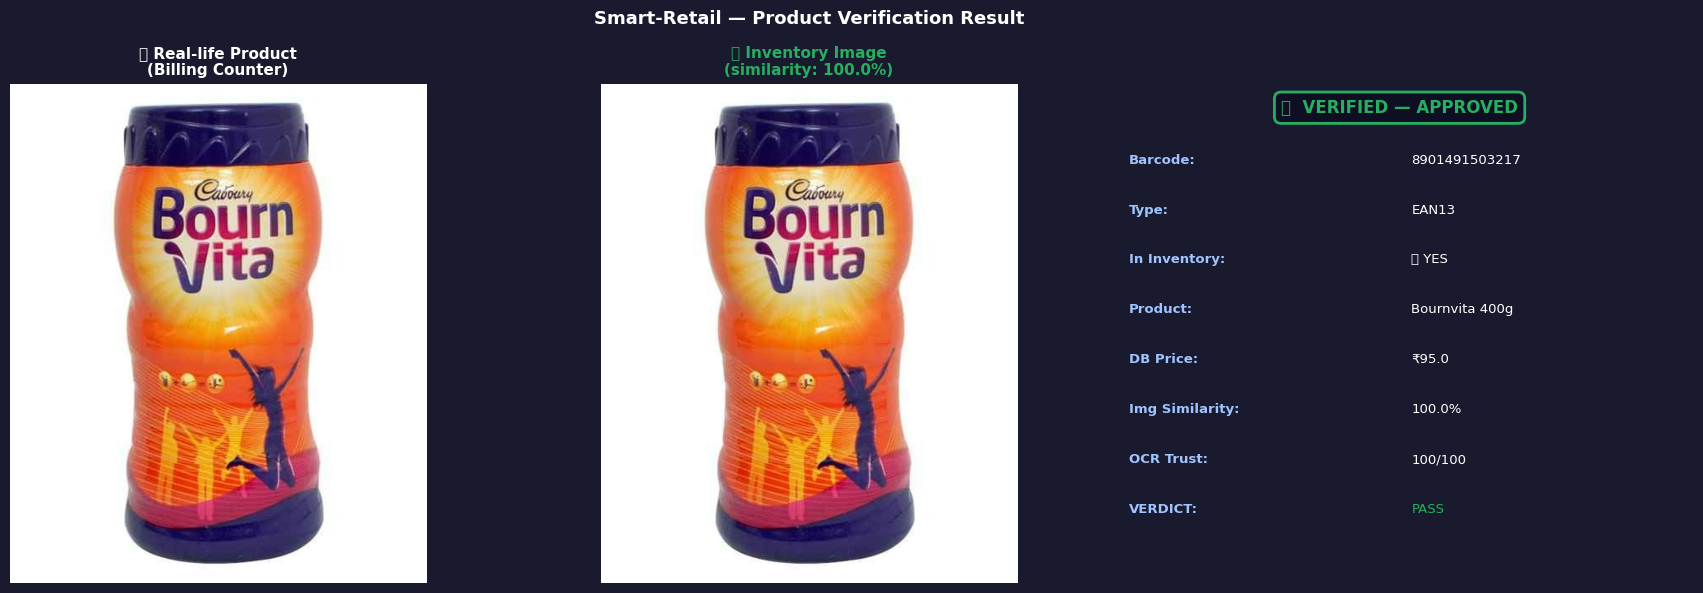

   📊 Saved → /kaggle/working/verification_result.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SCENARIO B — Ticket Switching Attack
  Nivea barcode (₹180) placed on Nestle Milo tin (₹120)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

═════════════════════════════════════════════════════════════════
  SMART-RETAIL — PRODUCT VERIFICATION PIPELINE
═════════════════════════════════════════════════════════════════

[Step 1] Scanning barcode...

[Step 2] Inventory check for barcode: 4006381333931
   ✅ Found: Nivea Cream 200ml | ₹180.0

[Step 3] Inventory image vs real-life product image...
   Inventory vs Real-life: 100.0% (✅ MATCH)

[Step 4] Reading label text from real-life image...
   [DEMO] OCR simulated: ['Nestle Milo', '500g', 'Chocolate Malt Drink']
   DB name     : 'Nivea Cream 200ml'
   Best match  : 'Nestle Milo'
   Trust score : 36/100 (threshold: 65)

[Step 5] Price check...
   ℹ️  Price not found in label

═════════════════════════

/tmp/ipykernel_57/2359853348.py:275: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2359853348.py:277: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")


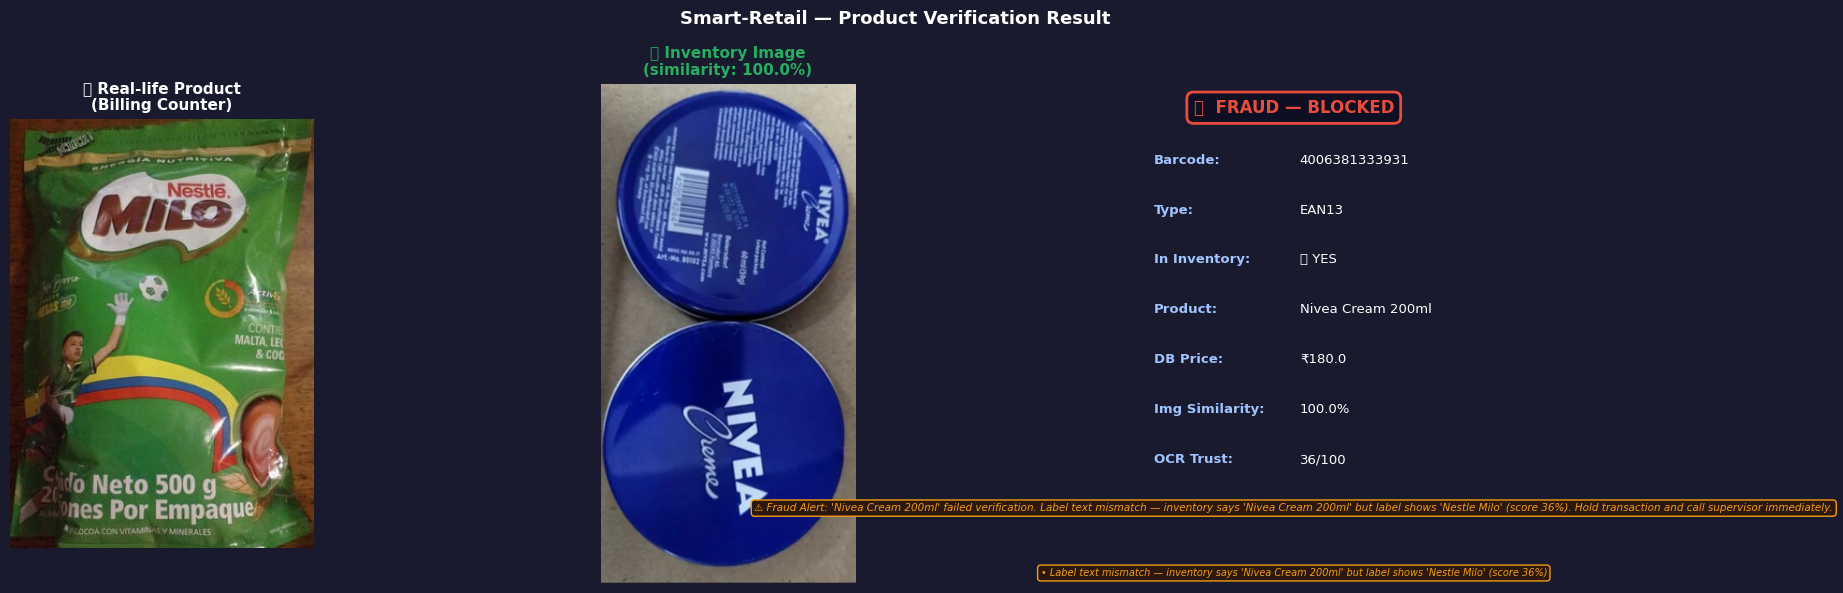

   📊 Saved → /kaggle/working/verification_result.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SCENARIO C — Unknown / Counterfeit Barcode
  Barcode number not registered in inventory
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

═════════════════════════════════════════════════════════════════
  SMART-RETAIL — PRODUCT VERIFICATION PIPELINE
═════════════════════════════════════════════════════════════════

[Step 1] Scanning barcode...

[Step 2] Inventory check for barcode: 9999999999999
   ❌ NOT in inventory → BLOCKED


/tmp/ipykernel_57/2359853348.py:275: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2359853348.py:277: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")


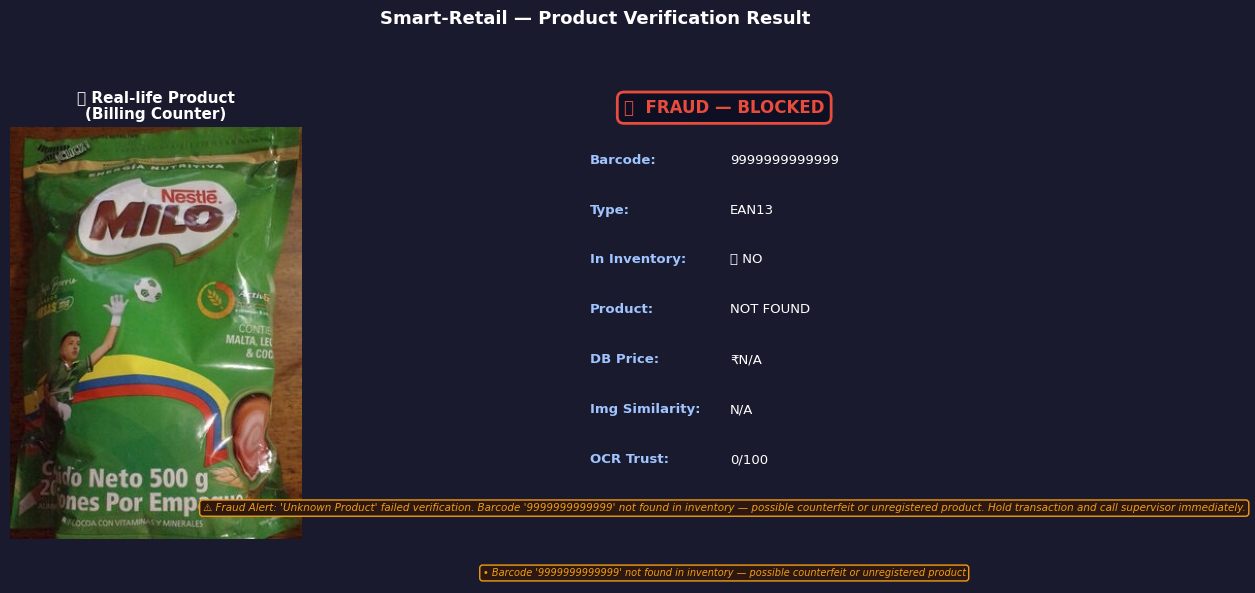

   📊 Saved → /kaggle/working/verification_result.png

═════════════════════════════════════════════════════════════════
  SMART-RETAIL AI — DEMO RESULTS SUMMARY
═════════════════════════════════════════════════════════════════

  ✅ PASS  Scenario A — Genuine Product
         Product    : Bournvita 400g
         DB Price   : ₹95.0
         Img Sim    : 100.0%
         OCR Trust  : 100/100

  🚨 BLOCK  Scenario B — Ticket Switching
         Product    : Nivea Cream 200ml
         DB Price   : ₹180.0
         Img Sim    : 100.0%
         OCR Trust  : 36/100
         ⚠️  Label text mismatch — inventory says 'Nivea Cream 200ml' but label shows 'Nestle Milo' (score 36%)

  🚨 BLOCK  Scenario C — Unknown Barcode
         Product    : NOT FOUND
         DB Price   : ₹N/A
         Img Sim    : N/A%
         OCR Trust  : 0/100
         ⚠️  Barcode '9999999999999' not found in inventory — possible counterfeit or unregistered product

═════════════════════════════════════════════════════════════════

In [64]:
# ════════════════════════════════════════════════
#  CELL H — HACKATHON DEMO
# ════════════════════════════════════════════════
INV = Path('/kaggle/input/datasets/ishitadas2004/product-images')
VAL = Path('/kaggle/working/smart_retail_data/val/images')

# Product images from inventory
BOURNVITA = str(INV / "BOURNVITA.jpeg")
MILO      = str(INV / "MILO1.jpeg")
NIVEA     = str(INV / "NIVEA.jpeg")
COLGATE   = str(INV / "COLGATE.jpeg")

# Val images for unknown barcode scenario
val_imgs  = sorted(list(VAL.glob('*.jpg')))
UNKNOWN   = str(val_imgs[0]) if val_imgs else BOURNVITA

# ── Mock OCR (no recursion — calls EasyOCR directly) ─────────
_mock_ocr = None
def _inject_mock_ocr(texts):
    global _mock_ocr
    _mock_ocr = texts

def run_ocr_on_image(image_path: str) -> tuple:
    global _mock_ocr
    if _mock_ocr is not None:
        t = _mock_ocr
        print(f"   [DEMO] OCR simulated: {t}")
        _mock_ocr = None
        return t[0], t
    # Real EasyOCR — called directly, no recursion
    try:
        results = _get_ocr_reader().readtext(image_path)
        if not results:
            return "UNREADABLE", []
        results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
        return results_sorted[0][1], [r[1] for r in results_sorted]
    except Exception as e:
        return "UNREADABLE", []

# ════════════════════════════════════════════════
#  SCENARIO A — Genuine Product
#  Bournvita barcode scanned → Bournvita in inventory
#  Real-life image → Bournvita product
#  Expected → PASS ✅
# ════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO A — Genuine Product (Bournvita)")
print("  Bournvita barcode + Bournvita real-life image")
print("━"*65)
_inject_mock_ocr(["Bournvita 400g", "Cadbury", "Health Drink"])

# Mock scan_barcode to return Bournvita barcode
def scan_barcode(image_path):
    db = lookup_product_by_barcode("8901491503217")
    return {
        "barcode_found"   : True,
        "barcode_number"  : "8901491503217",
        "barcode_type"    : "EAN13",
        "db_product"      : db,
        "inventory_image" : db["inventory_image"] if db else None,
    }

r1 = verify_product(
    barcode_image_path  = BOURNVITA,
    reallife_image_path = BOURNVITA
)

# ════════════════════════════════════════════════
#  SCENARIO B — Ticket Switching
#  Nivea barcode scanned (₹180) → Nivea in inventory
#  Real-life image → Milo product (wrong product)
#  Expected → BLOCK 🚨
# ════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO B — Ticket Switching Attack")
print("  Nivea barcode (₹180) placed on Nestle Milo tin (₹120)")
print("━"*65)
_inject_mock_ocr(["Nestle Milo", "500g", "Chocolate Malt Drink"])

def scan_barcode(image_path):
    db = lookup_product_by_barcode("4006381333931")
    return {
        "barcode_found"   : True,
        "barcode_number"  : "4006381333931",
        "barcode_type"    : "EAN13",
        "db_product"      : db,
        "inventory_image" : db["inventory_image"] if db else None,
    }

r2 = verify_product(
    barcode_image_path  = NIVEA,
    reallife_image_path = MILO
)

# ════════════════════════════════════════════════
#  SCENARIO C — Unknown / Counterfeit Barcode
#  Barcode not in inventory at all
#  Expected → BLOCK immediately 🚨
# ════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO C — Unknown / Counterfeit Barcode")
print("  Barcode number not registered in inventory")
print("━"*65)

def scan_barcode(image_path):
    return {
        "barcode_found"   : True,
        "barcode_number"  : "9999999999999",
        "barcode_type"    : "EAN13",
        "db_product"      : None,
        "inventory_image" : None,
    }

r3 = verify_product(
    barcode_image_path  = UNKNOWN,
    reallife_image_path = MILO
)

# ════════════════════════════════════════════════
#  FINAL SUMMARY
# ════════════════════════════════════════════════
print("\n" + "═"*65)
print("  SMART-RETAIL AI — DEMO RESULTS SUMMARY")
print("═"*65)
for name, r in [
    ("Scenario A — Genuine Product",   r1),
    ("Scenario B — Ticket Switching",  r2),
    ("Scenario C — Unknown Barcode",   r3),
]:
    icon = "✅ PASS" if r["final_verdict"] == "PASS" else "🚨 BLOCK"
    db   = r.get("db_product") or {}
    isi  = (r.get("inventory_img_sim") or {}).get("similarity", "N/A")
    print(f"\n  {icon}  {name}")
    print(f"         Product    : {db.get('product_name','NOT FOUND')}")
    print(f"         DB Price   : ₹{db.get('price','N/A')}")
    print(f"         Img Sim    : {isi}%")
    print(f"         OCR Trust  : {r.get('ocr_trust_score',0)}/100")
    for fr in r.get("fraud_reasons", []):
        print(f"         ⚠️  {fr}")

print("\n" + "═"*65)
print("  Results saved → /kaggle/working/verification_result.png")
print("═"*65)

In [ ]:
NO CODE MUST RUN AFTE THIS 

In [45]:
# In LIVE_MODE, this connects to PostgreSQL.
# In DEMO mode, it uses MOCK_DB below.
LIVE_MODE = False
db_conn   = None

try:
    from kaggle_secrets import UserSecretsClient
    import psycopg2
    secrets = UserSecretsClient()
    db_conn = psycopg2.connect(
        host     = secrets.get_secret("DB_HOST"),
        dbname   = secrets.get_secret("DB_NAME"),
        user     = secrets.get_secret("DB_USER"),
        password = secrets.get_secret("DB_PASSWORD"),
        port     = secrets.get_secret("DB_PORT")
    )
    LIVE_MODE = True
    print("✅ PostgreSQL connected — LIVE mode")
except Exception as e:
    print(f"ℹ️  DB not available ({e}) — running in MOCK/DEMO mode")

INV = Path('/kaggle/input/datasets/ishitadas2004/product-images')

MOCK_DB = {
    "8901491503217": {
        "product_name"    : "Bournvita 400g",
        "price"           : 95.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "BOURNVITA.jpeg"),
    },
    "8901030823437": {
        "product_name"    : "Nestle Milo 500g",
        "price"           : 120.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "MILO1.jpeg"),
    },
    "4006381333931": {
        "product_name"    : "Nivea Cream 200ml",
        "price"           : 180.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "NIVEA.jpeg"),
    },
    "012345678905": {
        "product_name"    : "Colgate 150ml",
        "price"           : 65.00,
        "barcode_format"  : "UPC-A",
        "inventory_image" : str(INV / "COLGATE.jpeg"),
    },
}

def lookup_product_by_barcode(barcode: str) -> dict | None:
    if LIVE_MODE and db_conn:
        try:
            cur = db_conn.cursor()
            cur.execute(
                "SELECT product_name, price, barcode_format FROM products "
                "WHERE barcode = %s LIMIT 1",
                (barcode.strip(),)
            )
            row = cur.fetchone()
            cur.close()
            if row:
                return {"product_name": row[0], "price": float(row[1]),
                        "barcode_format": row[2],
                        "inventory_image": None}
            return None
        except Exception as e:
            print(f"   DB error: {e} — using mock")
    return MOCK_DB.get(barcode.strip(), None)

print("✅ lookup_product_by_barcode() ready")
print(f"   Bournvita → {MOCK_DB['8901491503217']['inventory_image']}")
print(f"   Milo      → {MOCK_DB['8901030823437']['inventory_image']}")
print(f"   Nivea     → {MOCK_DB['4006381333931']['inventory_image']}")

ℹ️  DB not available (Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 115317769 and label DB_HOST.'], 'error': {'code': 5}, 'wasSuccessful': False}.) — running in MOCK/DEMO mode
✅ lookup_product_by_barcode() ready
   Bournvita → /kaggle/input/datasets/ishitadas2004/product-images/BOURNVITA.jpeg
   Milo      → /kaggle/input/datasets/ishitadas2004/product-images/MILO1.jpeg
   Nivea     → /kaggle/input/datasets/ishitadas2004/product-images/NIVEA.jpeg


In [46]:
INVENTORY_IMG_DIR = Path("/kaggle/input/datasets/ishitadas2004/product-images")

_all_inv_imgs = []
if INVENTORY_IMG_DIR.exists():
    _all_inv_imgs = (list(INVENTORY_IMG_DIR.rglob("*.jpg")) +
                     list(INVENTORY_IMG_DIR.rglob("*.jpeg")) +
                     list(INVENTORY_IMG_DIR.rglob("*.png")))
    print(f"✅ Inventory dataset: {len(_all_inv_imgs)} images found")
else:
    print(f"⚠️  Inventory folder not found at {INVENTORY_IMG_DIR}")
    print("   Will use val/images as demo fallback.")


def get_inventory_image(barcode: str) -> str | None:
    """
    Returns file path of the official product image for this barcode.
    Search order:
      1. File named exactly <barcode>.jpg/png
      2. File whose name contains the barcode substring
      3. PostgreSQL image_path column (LIVE_MODE)
      4. First available inventory image (demo fallback)
    """
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".PNG"]:
        p = INVENTORY_IMG_DIR / f"{barcode}{ext}"
        if p.exists():
            print(f"   ✅ Inventory image (exact): {p.name}")
            return str(p)

    matches = [f for f in _all_inv_imgs if barcode in f.stem]
    if matches:
        print(f"   ✅ Inventory image (substring): {matches[0].name}")
        return str(matches[0])

    if LIVE_MODE and db_conn:
        try:
            cur = db_conn.cursor()
            cur.execute(
                "SELECT image_path FROM products WHERE barcode = %s LIMIT 1",
                (barcode.strip(),)
            )
            row = cur.fetchone()
            cur.close()
            if row and row[0] and Path(row[0]).exists():
                print(f"   ✅ Inventory image (DB): {row[0]}")
                return row[0]
        except Exception as e:
            print(f"   DB image lookup error: {e}")

    if _all_inv_imgs:
        print(f"   ⚠️  No barcode-specific image — demo fallback: {_all_inv_imgs[0].name}")
        return str(_all_inv_imgs[0])

    val_dir = Path('/kaggle/working/smart_retail_data/val/images')
    if val_dir.exists():
        imgs = list(val_dir.glob("*.jpg")) + list(val_dir.glob("*.png"))
        if imgs:
            print("   ⚠️  Using val/images as last fallback")
            return str(imgs[0])

    print(f"   ❌ No inventory image found for barcode: {barcode}")
    return None

print("✅ get_inventory_image() ready")

✅ Inventory dataset: 6 images found
✅ get_inventory_image() ready


In [47]:
def load_yolo_model():
    model_path = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'
    if os.path.exists(model_path):
        size_mb = os.path.getsize(model_path) / 1e6
        print(f"✅ Loading trained YOLOv8 from {model_path} ({size_mb:.1f} MB)")
        return YOLO(model_path)
    else:
        print("⚠️  best.pt not found — using YOLOv8n pretrained as fallback")
        return YOLO('yolov8n.pt')

yolo_model = load_yolo_model()

✅ Loading trained YOLOv8 from /kaggle/working/runs/detect/smart_retail/weights/best.pt (6.2 MB)


In [48]:
SIMILARITY_THRESHOLD = 70.0


def _load_as_bgr(source) -> np.ndarray:
    if isinstance(source, str):
        img = cv2.imread(source)
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {source}")
        return img
    elif isinstance(source, np.ndarray):
        return cv2.cvtColor(source, cv2.COLOR_RGB2BGR) if source.shape[2] == 3 else source
    else:
        raise ValueError(f"Unsupported type: {type(source)}")


def _extract_yolo_features(img_bgr: np.ndarray, model) -> np.ndarray:
    img_resized = cv2.resize(img_bgr, (640, 640))
    img_rgb     = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    tensor      = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    tensor      = tensor.unsqueeze(0)
    features    = []

    def hook_fn(module, input, output):
        features.append(output.mean(dim=[2, 3]).detach().cpu().numpy())

    try:
        hook_layer = model.model.model[-3]
    except Exception:
        conv_layers = [m for m in model.model.modules() if isinstance(m, torch.nn.Conv2d)]
        hook_layer  = conv_layers[-1]

    handle = hook_layer.register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            device = next(model.model.parameters()).device
            _ = model.model(tensor.to(device))
    finally:
        handle.remove()

    if not features:
        raise RuntimeError("Feature hook returned nothing")
    vec  = features[0].flatten()
    norm = np.linalg.norm(vec)
    return vec / (norm + 1e-9)


def _histogram_similarity(img1_bgr: np.ndarray, img2_bgr: np.ndarray) -> float:
    size    = (256, 256)
    i1, i2 = cv2.resize(img1_bgr, size), cv2.resize(img2_bgr, size)
    scores  = []
    for ch in range(3):
        h1 = cv2.calcHist([i1], [ch], None, [64], [0, 256])
        h2 = cv2.calcHist([i2], [ch], None, [64], [0, 256])
        cv2.normalize(h1, h1)
        cv2.normalize(h2, h2)
        scores.append(cv2.compareHist(h1, h2, cv2.HISTCMP_CORREL))
    return float(max(np.mean(scores) * 100, 0.0))


def compare_product_images(
    reference_img,
    reallife_img,
    label     : str   = "Comparison",
    threshold : float = SIMILARITY_THRESHOLD,
    model             = None
) -> dict:
    """
    Compares two product images using YOLOv8 backbone cosine similarity.
    Falls back to HSV histogram if feature extraction fails.

    reference_img : file path or numpy RGB array
                    (barcode-cropped region OR inventory image)
    reallife_img  : file path or numpy RGB array
                    (in-store camera photo of the actual product)

    Returns dict: similarity (0-100), match (bool), method, label, threshold
    """
    _model   = model or yolo_model
    img1_bgr = _load_as_bgr(reference_img)
    img2_bgr = _load_as_bgr(reallife_img)

    result = dict(label=label, similarity=0.0, match=False,
                  method="none", threshold=threshold)

    try:
        f1  = _extract_yolo_features(img1_bgr, _model)
        f2  = _extract_yolo_features(img2_bgr, _model)
        cos = float(np.dot(f1, f2))
        sim = round((cos + 1) / 2 * 100, 2)
        result.update(similarity=sim, match=sim >= threshold, method="yolo_features")
        print(f"   [YOLOv8] {label} → {sim:.1f}%")
        return result
    except Exception as e:
        print(f"   ⚠️  YOLOv8 features failed ({e}) — using histogram fallback")

    sim = round(_histogram_similarity(img1_bgr, img2_bgr), 2)
    result.update(similarity=sim, match=sim >= threshold, method="histogram")
    print(f"   [Histogram] {label} → {sim:.1f}%")
    return result


print("✅ compare_product_images() ready — YOLOv8 backbone features (no AWS)")

_val_imgs = sorted(Path('/kaggle/working/smart_retail_data/val/images').glob('*.jpg'))[:2]
if len(_val_imgs) >= 2:
    print("\n🔬 Self-similarity test (same image — expect ~100%):")
    r = compare_product_images(str(_val_imgs[0]), str(_val_imgs[0]), label="Self-check")
    print(f"   → {r['similarity']}%  ({'✅' if r['similarity'] > 90 else '⚠️ check hook'})")
    print("\n🔬 Cross-image test (different images — expect lower):")
    r2 = compare_product_images(str(_val_imgs[0]), str(_val_imgs[1]), label="Cross-check")
    print(f"   → {r2['similarity']}%")

✅ compare_product_images() ready — YOLOv8 backbone features (no AWS)

🔬 Self-similarity test (same image — expect ~100%):
   [YOLOv8] Self-check → 100.0%
   → 100.0%  (✅)

🔬 Cross-image test (different images — expect lower):
   [YOLOv8] Cross-check → 98.3%
   → 98.3%


In [49]:
TRUST_THRESHOLD = 65

_ocr_reader = None

def _get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        print("   Loading EasyOCR model (first time only)...")
        _ocr_reader = easyocr.Reader(
            ['en'],
            gpu     = torch.cuda.is_available(),
            verbose = False
        )
    return _ocr_reader


def run_ocr_on_image(image_path: str) -> tuple[str, list]:
    """
    Runs EasyOCR on a product image.
    Returns (best_text, all_detected_lines).
    """
    try:
        reader  = _get_ocr_reader()
        results = reader.readtext(image_path)
        if not results:
            return "UNREADABLE", []
        results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
        all_texts      = [r[1] for r in results_sorted]
        best_text      = results_sorted[0][1]
        print(f"   EasyOCR: {len(results)} text blocks detected")
        print(f"   All texts : {all_texts[:5]}")
        return best_text, all_texts
    except Exception as e:
        print(f"   EasyOCR error: {e}")
        return "UNREADABLE", []


def cross_verify(db_product_name: str, ocr_texts: list) -> tuple[int, str]:
    """
    Fuzzy-matches ALL OCR lines against the DB product name.
    Returns (best_score 0-100, best_matching_ocr_text).
    """
    if not ocr_texts or ocr_texts == ["UNREADABLE"]:
        return 0, "UNREADABLE"
    best_score, best_match = 0, ""
    for line in ocr_texts:
        score = fuzz.token_set_ratio(db_product_name.lower(), line.lower())
        if score > best_score:
            best_score, best_match = score, line
    return best_score, best_match


print("✅ run_ocr_on_image() + cross_verify() ready")

✅ run_ocr_on_image() + cross_verify() ready


In [50]:
def scan_barcode(image_path: str) -> dict:
    """
    Scans a barcode/QR code from an image using pyzbar.

    When a barcode is detected:
      1. Extracts the barcode NUMBER
      2. Crops the product image region (area outside the barcode box)
      3. Looks up the barcode number in inventory
      4. Fetches product name, price, and inventory product image

    Verification is ONLY performed if the barcode number exists in inventory.
    If NOT found → result flags barcode_in_inventory=False and downstream
    verification is blocked.

    Returns dict with keys:
        barcode_found, barcode_number, barcode_type, barcode_bbox,
        barcode_in_inventory, product_img (numpy RGB), full_img (numpy RGB),
        db_product, inventory_img_path
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    result = dict(
        barcode_found        = False,
        barcode_number       = None,
        barcode_type         = None,
        barcode_bbox         = None,
        barcode_in_inventory = False,
        product_img          = img_rgb,
        full_img             = img_rgb,
        db_product           = None,
        inventory_img_path   = None,
    )

    # Step 1: Decode barcode
    decoded = pyzbar_lib.decode(img)
    if not decoded:
        print("   ⚠️  No barcode/QR detected in image")
        return result

    obj            = decoded[0]
    barcode_number = obj.data.decode("utf-8").strip()
    barcode_type   = obj.type
    bbox           = obj.rect
    bx, by, bw, bh = bbox.left, bbox.top, bbox.width, bbox.height

    print(f"   ✅ Barcode decoded: [{barcode_type}] → '{barcode_number}'")

    # Step 2: Crop product region (complement of barcode box)
    margin = 10
    if bx > w // 2:
        product_crop = img_rgb[:, :max(0, bx - margin), :]
    elif bx + bw < w // 2:
        product_crop = img_rgb[:, bx + bw + margin:, :]
    elif by > h // 2:
        product_crop = img_rgb[:max(0, by - margin), :, :]
    else:
        product_crop = img_rgb[by + bh + margin:, :, :]

    if product_crop.size == 0:
        product_crop = img_rgb

    result.update(
        barcode_found  = True,
        barcode_number = barcode_number,
        barcode_type   = barcode_type,
        barcode_bbox   = (bx, by, bw, bh),
        product_img    = product_crop,
    )

    # Step 3: Look up barcode in inventory
    print(f"   Querying inventory for barcode: {barcode_number} ...")
    db_product    = lookup_product_by_barcode(barcode_number)
    inventory_img = None

    if db_product is None:
        print("   ❌ Barcode NOT found in inventory — verification will be BLOCKED")
        print("      No product information or image can be fetched.")
        result.update(barcode_in_inventory=False, db_product=None, inventory_img_path=None)
    else:
        print(f"   ✅ Found in inventory: {db_product['product_name']} | ₹{db_product['price']}")
        result["barcode_in_inventory"] = True
        result["db_product"]           = db_product

        # Step 4: Fetch inventory product image for this barcode
        inventory_img = get_inventory_image(barcode_number)
        result["inventory_img_path"] = inventory_img
        if inventory_img:
            print("   ✅ Inventory product image fetched successfully")
        else:
            print("   ⚠️  No inventory image available for this barcode")

    # Step 5: Visualise scan result
    n_panels = 3 if inventory_img else 2
    fig, axes = plt.subplots(1, n_panels + 1, figsize=(6 * (n_panels + 1), 5))
    fig.patch.set_facecolor("#1a1a2e")

    # Panel 0: full image with barcode box highlighted
    axes[0].imshow(img_rgb)
    rect = patches.Rectangle((bx, by), bw, bh,
                               linewidth=3, edgecolor='#00ff99', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title(f"📷 Scanned Image\n[{barcode_type}] detected (green box)",
                       color="white", fontsize=10, fontweight="bold")
    axes[0].axis("off")

    # Panel 1: extracted product crop
    axes[1].imshow(product_crop)
    axes[1].set_title("🏷️ Extracted Product\nImage Region",
                       color="white", fontsize=10, fontweight="bold")
    axes[1].axis("off")

    # Panel 2: inventory image (if found)
    if inventory_img:
        inv_img_arr = cv2.cvtColor(cv2.imread(inventory_img), cv2.COLOR_BGR2RGB)
        axes[2].imshow(inv_img_arr)
        axes[2].set_title("🗄️ Inventory Product\nImage (reference)",
                           color="#a0c4ff", fontsize=10, fontweight="bold")
        axes[2].axis("off")

    # Info panel
    info_ax = axes[-1]
    info_ax.set_facecolor("#16213e")
    info_ax.axis("off")
    db = db_product or {}
    rows = [
        ("Barcode Number",    barcode_number),
        ("Barcode Type",      barcode_type),
        ("In Inventory",      "✅ YES" if db_product else "❌ NO"),
        ("Product Name",      db.get("product_name", "❌ NOT IN INVENTORY")),
        ("Price (DB)",        f"₹{db.get('price', 'N/A')}"),
        ("Inventory Image",   "✅ Found" if inventory_img else "⚠️ Not found"),
    ]
    info_ax.text(0.5, 0.97, "📦 Barcode Scan Result",
                 transform=info_ax.transAxes, color="#00ff99",
                 fontsize=12, fontweight="bold", ha="center", va="top")
    for i, (lbl, val) in enumerate(rows):
        y = 0.80 - i * 0.13
        info_ax.text(0.04, y, lbl + ":", transform=info_ax.transAxes,
                     color="#a0c4ff", fontsize=10, fontweight="bold")
        col = "#e74c3c" if "NOT IN" in str(val) or val == "❌ NO" else "white"
        info_ax.text(0.04, y - 0.06, str(val), transform=info_ax.transAxes,
                     color=col, fontsize=9.5)

    plt.suptitle("Barcode Scan — Number Extraction + Inventory Lookup",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/barcode_scan_result.png",
                dpi=120, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    print("   📊 Saved → /kaggle/working/barcode_scan_result.png")

    return result


print("✅ scan_barcode() ready")

val_dir    = '/kaggle/working/smart_retail_data/val/images'
_test_imgs = [f for f in os.listdir(val_dir) if f.lower().endswith(('.jpg', '.png'))]
if _test_imgs:
    print("\n🔬 Running scan_barcode() on a val image...")
    _r = scan_barcode(os.path.join(val_dir, _test_imgs[0]))
    print(f"   barcode_found        : {_r['barcode_found']}")
    print(f"   barcode_number       : {_r['barcode_number']}")
    print(f"   barcode_in_inventory : {_r['barcode_in_inventory']}")
    print(f"   db_product           : {_r['db_product']}")

✅ scan_barcode() ready

🔬 Running scan_barcode() on a val image...
   ⚠️  No barcode/QR detected in image
   barcode_found        : False
   barcode_number       : None
   barcode_in_inventory : False
   db_product           : None


In [31]:
import os
from pathlib import Path

val_dir = Path('/kaggle/working/smart_retail_data/val/images')
imgs = sorted(list(val_dir.glob('*.jpg')) + list(val_dir.glob('*.png')))

print(f"Total val images: {len(imgs)}")
for i, img in enumerate(imgs[:15]):
    print(f"  [{i}] {img.name}")

Total val images: 578
  [0] bc_05102009081.jpg
  [1] bc_05102009082.jpg
  [2] bc_05102009102.jpg
  [3] bc_05102009105.jpg
  [4] bc_05102009119.jpg
  [5] bc_05102009124.jpg
  [6] bc_05102009134.jpg
  [7] bc_05102009138.jpg
  [8] bc_05102009140.jpg
  [9] bc_05102009141.jpg
  [10] bc_05102009180.jpg
  [11] bc_05102009192.jpg
  [12] bc_05102009198.jpg
  [13] bc_05102009202.jpg
  [14] bc_05102009208.jpg


In [32]:
from pathlib import Path

inv_dir = Path('/kaggle/input/datasets/ishitadas2004/product-images')
imgs = sorted(list(inv_dir.rglob('*.jpg')) + 
              list(inv_dir.rglob('*.jpeg')) + 
              list(inv_dir.rglob('*.png')))

print(f"Total inventory images: {len(imgs)}")
for i, img in enumerate(imgs):
    print(f"  [{i}] {img.name}  →  {img}")

Total inventory images: 6
  [0] BOURNVITA.jpeg  →  /kaggle/input/datasets/ishitadas2004/product-images/BOURNVITA.jpeg
  [1] COLGATE.jpeg  →  /kaggle/input/datasets/ishitadas2004/product-images/COLGATE.jpeg
  [2] MILO1.jpeg  →  /kaggle/input/datasets/ishitadas2004/product-images/MILO1.jpeg
  [3] MILO2.jpeg  →  /kaggle/input/datasets/ishitadas2004/product-images/MILO2.jpeg
  [4] MILO3.jpeg  →  /kaggle/input/datasets/ishitadas2004/product-images/MILO3.jpeg
  [5] NIVEA.jpeg  →  /kaggle/input/datasets/ishitadas2004/product-images/NIVEA.jpeg


In [51]:
INV = Path('/kaggle/input/datasets/ishitadas2004/product-images')
VAL = Path('/kaggle/working/smart_retail_data/val/images')

MOCK_DB = {
    "8901491503217": {
        "product_name"    : "Bournvita 400g",
        "price"           : 95.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "BOURNVITA.jpeg"),
    },
    "8901030823437": {
        "product_name"    : "Nestle Milo 500g",
        "price"           : 120.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "MILO1.jpeg"),
    },
    "4006381333931": {
        "product_name"    : "Nivea Cream 200ml",
        "price"           : 180.00,
        "barcode_format"  : "EAN-13",
        "inventory_image" : str(INV / "NIVEA.jpeg"),
    },
    "012345678905": {
        "product_name"    : "Colgate 150ml",
        "price"           : 65.00,
        "barcode_format"  : "UPC-A",
        "inventory_image" : str(INV / "COLGATE.jpeg"),
    },
}

def lookup_product_by_barcode(barcode: str) -> dict | None:
    if LIVE_MODE and db_conn:
        try:
            cur = db_conn.cursor()
            cur.execute(
                "SELECT product_name, price, barcode_format FROM products "
                "WHERE barcode = %s LIMIT 1",
                (barcode.strip(),)
            )
            row = cur.fetchone()
            cur.close()
            if row:
                return {"product_name": row[0], "price": float(row[1]),
                        "barcode_format": row[2],
                        "inventory_image": None}
            return None
        except Exception as e:
            print(f"   DB error: {e} — using mock")
    return MOCK_DB.get(barcode.strip(), None)

print("✅ MOCK_DB ready")
print(f"   Bournvita image : {MOCK_DB['8901491503217']['inventory_image']}")
print(f"   Milo image      : {MOCK_DB['8901030823437']['inventory_image']}")
print(f"   Nivea image     : {MOCK_DB['4006381333931']['inventory_image']}")
print(f"   Colgate image   : {MOCK_DB['012345678905']['inventory_image']}")

✅ MOCK_DB ready
   Bournvita image : /kaggle/input/datasets/ishitadas2004/product-images/BOURNVITA.jpeg
   Milo image      : /kaggle/input/datasets/ishitadas2004/product-images/MILO1.jpeg
   Nivea image     : /kaggle/input/datasets/ishitadas2004/product-images/NIVEA.jpeg
   Colgate image   : /kaggle/input/datasets/ishitadas2004/product-images/COLGATE.jpeg


In [52]:
def generate_fraud_narrative(verify_result: dict) -> str | None:
    if verify_result.get("final_verdict") == "PASS":
        return None

    db      = verify_result.get("db_product") or {}
    name    = db.get("product_name", "Unknown Product")
    ocr     = verify_result.get("ocr_best_text", "unreadable")
    score   = verify_result.get("ocr_trust_score", 0)
    reasons = verify_result.get("fraud_reasons", [])
    summary = reasons[0] if reasons else "Mismatch detected"

    return (
        f"⚠️ Fraud Alert: Barcode indicates '{name}' "
        f"but product label shows '{ocr}' "
        f"(trust score: {score}%). "
        f"Reason: {summary}. "
        f"Hold transaction and call supervisor immediately."
    )

print("✅ generate_fraud_narrative() ready")

✅ generate_fraud_narrative() ready


In [53]:
def full_barcode_verification(
    barcode_image_path  : str,
    reallife_image_path : str
) -> dict:
    """
    Complete verification triggered by a barcode scan.

    Flow:
      [Step 1] Scan barcode image → extract barcode NUMBER + product crop image
      [Step 2] Look up barcode number in inventory
               → if NOT found: BLOCK immediately (no further checks)
               → if found: fetch product name, price, inventory product image
      [Step 3] Barcode-cropped product image vs real-life photo (YOLOv8 similarity)
      [Step 4] Inventory product image vs real-life photo (YOLOv8 similarity)
      [Step 5] OCR label text on real-life photo vs DB product name (fuzzy match)
      [Step 6] Price cross-check (OCR price vs DB price)
      [Step 7] Final verdict: PASS or BLOCK
    """
    print("\n" + "═" * 65)
    print("  SMART-RETAIL — BARCODE VERIFICATION PIPELINE")
    print("═" * 65)

    result = dict(
        barcode_number       = None,
        barcode_type         = None,
        db_product           = None,
        ocr_best_text        = None,
        ocr_trust_score      = 0,
        barcode_image_sim    = None,
        inventory_image_sim  = None,
        final_verdict        = None,
        fraud_reasons        = [],
    )
    fraud_reasons = []

    # ── Step 1: Scan barcode ──────────────────────────────────
    print("\n[Step 1] Scanning barcode — extracting number and product image...")
    scan = scan_barcode(barcode_image_path)

    if not scan["barcode_found"]:
        fraud_reasons.append("No barcode detected in the scanned image")
        result.update(fraud_reasons=fraud_reasons, final_verdict="BLOCK")
        _render_verification_result(reallife_image_path, result)
        return result

    barcode_number = scan["barcode_number"]
    barcode_type   = scan["barcode_type"]
    barcode_crop   = scan["product_img"]      # product image extracted from barcode scan
    db_product     = scan["db_product"]
    inventory_img  = scan["inventory_img_path"]

    result.update(barcode_number=barcode_number, barcode_type=barcode_type,
                  db_product=db_product)

    # ── Step 2: Inventory existence check ────────────────────
    print(f"\n[Step 2] Inventory check for barcode: {barcode_number}")
    if not scan["barcode_in_inventory"]:
        fraud_reasons.append(
            f"Barcode '{barcode_number}' not found in product inventory — "
            f"possible counterfeit or unregistered product. "
            f"Verification skipped (no reference data available)."
        )
        print("   ❌ NOT in inventory → BLOCKED — no further verification possible")
        result.update(fraud_reasons=fraud_reasons, final_verdict="BLOCK")
        _render_verification_result(reallife_image_path, result,
                                    barcode_crop=barcode_crop)
        return result

    print(f"   ✅ Found: {db_product['product_name']} | ₹{db_product['price']}")
    print(f"   Proceeding with full verification using fetched product data...")

    # ── Step 3: Barcode-extracted product image vs real-life photo ──
    print(f"\n[Step 3] Barcode-extracted product image ↔ real-life photo...")
    barcode_img_check = compare_product_images(
        reference_img = barcode_crop,
        reallife_img  = reallife_image_path,
        label         = "Barcode Image vs Real-life",
        threshold     = SIMILARITY_THRESHOLD
    )
    result["barcode_image_sim"] = barcode_img_check

    if not barcode_img_check["match"]:
        fraud_reasons.append(
            f"Product image from barcode scan ≠ real-life product photo "
            f"(similarity {barcode_img_check['similarity']:.1f}% "
            f"< threshold {SIMILARITY_THRESHOLD}%)"
        )
        print(f"   ❌ Mismatch — {barcode_img_check['similarity']:.1f}%")
    else:
        print(f"   ✅ Match — {barcode_img_check['similarity']:.1f}%")

    # ── Step 4: Inventory product image vs real-life photo ───
    print(f"\n[Step 4] Inventory product image ↔ real-life photo...")
    if inventory_img:
        inv_img_check = compare_product_images(
            reference_img = inventory_img,
            reallife_img  = reallife_image_path,
            label         = "Inventory Image vs Real-life",
            threshold     = SIMILARITY_THRESHOLD
        )
        result["inventory_image_sim"] = inv_img_check

        if not inv_img_check["match"]:
            fraud_reasons.append(
                f"Inventory product image ≠ real-life product photo "
                f"(similarity {inv_img_check['similarity']:.1f}% "
                f"< threshold {SIMILARITY_THRESHOLD}%)"
            )
            print(f"   ❌ Mismatch — {inv_img_check['similarity']:.1f}%")
        else:
            print(f"   ✅ Match — {inv_img_check['similarity']:.1f}%")
    else:
        result["inventory_image_sim"] = dict(
            similarity=None, match=None,
            label="Inventory Image vs Real-life", method="skipped"
        )
        print("   ⚠️  No inventory image available — Step 4 skipped")

    # ── Step 5: OCR label text vs DB product name ────────────
    print(f"\n[Step 5] OCR label text ↔ DB product name...")
    ocr_best, ocr_all       = run_ocr_on_image(reallife_image_path)
    trust_score, best_match = cross_verify(db_product["product_name"], ocr_all)
    result["ocr_best_text"]  = ocr_best
    result["ocr_trust_score"] = trust_score
    print(f"   DB name   : '{db_product['product_name']}'")
    print(f"   Best OCR  : '{ocr_best}'")
    print(f"   Trust     : {trust_score}/100  (threshold {TRUST_THRESHOLD})")

    if ocr_best == "UNREADABLE":
        fraud_reasons.append("OCR could not read product label — manual inspection required")
    elif trust_score < TRUST_THRESHOLD:
        fraud_reasons.append(
            f"Label text mismatch — DB: '{db_product['product_name']}' "
            f"| label shows: '{ocr_best}' (score {trust_score}%)"
        )

    # ── Step 6: Price cross-check ─────────────────────────────
    print(f"\n[Step 6] Price cross-check...")
    price_pattern = re.compile(r'(?:MRP|RS|₹)[:\s]?([\d.]+)', re.IGNORECASE)
    ocr_price = None
    for line in ocr_all:
        m = price_pattern.search(line.replace(" ", ""))
        if m:
            ocr_price = float(m.group(1))
            break
    db_price = db_product.get("price")
    if ocr_price and db_price:
        price_diff = abs(ocr_price - db_price)
        if price_diff > 5:
            print(f"   ⚠️  Price discrepancy: OCR ₹{ocr_price} vs DB ₹{db_price}")
            fraud_reasons.append(
                f"Price mismatch: label shows ₹{ocr_price} but DB says ₹{db_price}"
            )
        else:
            print(f"   ✅ Price consistent: ₹{db_price}")
    else:
        print(f"   ℹ️  Price not extracted from label (OCR price: {ocr_price})")

    # ── Step 7: Final verdict ─────────────────────────────────
    result["fraud_reasons"] = fraud_reasons
    result["final_verdict"] = "PASS" if not fraud_reasons else "BLOCK"

    print("\n" + "═" * 65)
    if result["final_verdict"] == "PASS":
        print("  ✅  ALL CHECKS PASSED — TRANSACTION APPROVED")
    else:
        print("  🚨  FRAUD / MISMATCH DETECTED — TRANSACTION BLOCKED")
        for i, fr in enumerate(fraud_reasons, 1):
            print(f"      {i}. {fr}")
    print("═" * 65)

    narrative = generate_fraud_narrative(result)
    if narrative:
        print(f"\n{narrative}")

    _render_verification_result(
        reallife_image_path, result,
        barcode_crop  = barcode_crop,
        inventory_img = inventory_img
    )
    return result


def _render_verification_result(
    reallife_path, result,
    barcode_crop  = None,
    inventory_img = None
):
    is_pass      = result["final_verdict"] == "PASS"
    STATUS_COLOR = "#27ae60" if is_pass else "#e74c3c"
    STATUS_LABEL = "✅  VERIFIED — APPROVED" if is_pass else "🚨  FRAUD — BLOCKED"

    panels = [("reallife", reallife_path)]
    if barcode_crop is not None:
        panels.append(("barcode_crop", barcode_crop))
    if inventory_img and os.path.exists(str(inventory_img)):
        panels.append(("inventory", inventory_img))
    panels.append(("scorecard", None))

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]
    fig.patch.set_facecolor("#1a1a2e")

    for idx, (panel_type, panel_data) in enumerate(panels):
        ax = axes[idx]

        if panel_type == "reallife":
            try:
                out = yolo_model(panel_data, verbose=False)
                img = cv2.cvtColor(out[0].plot(), cv2.COLOR_BGR2RGB)
            except Exception:
                img = cv2.cvtColor(cv2.imread(panel_data), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title("📷 Real-life Product\n(YOLO detection)",
                         color="white", fontsize=11, fontweight="bold")
            ax.axis("off")

        elif panel_type == "barcode_crop":
            ax.imshow(panel_data)
            sim = (result.get("barcode_image_sim") or {})
            pct = sim.get("similarity", "N/A")
            ok  = sim.get("match", False)
            ax.set_title(
                f"🔲 Barcode-Extracted\nProduct Image  ({pct}%)",
                color="#27ae60" if ok else "#e74c3c",
                fontsize=11, fontweight="bold"
            )
            ax.axis("off")

        elif panel_type == "inventory":
            inv_arr = cv2.cvtColor(cv2.imread(str(panel_data)), cv2.COLOR_BGR2RGB)
            ax.imshow(inv_arr)
            sim = (result.get("inventory_image_sim") or {})
            pct = sim.get("similarity", "N/A")
            ok  = sim.get("match", False)
            ax.set_title(
                f"🗄️ Inventory Product\nImage  ({pct}%)",
                color="#27ae60" if ok else "#e74c3c",
                fontsize=11, fontweight="bold"
            )
            ax.axis("off")

        elif panel_type == "scorecard":
            ax.set_facecolor("#16213e")
            ax.axis("off")
            db  = result.get("db_product") or {}
            bsi = (result.get("barcode_image_sim")   or {}).get("similarity", "N/A")
            isi = (result.get("inventory_image_sim") or {}).get("similarity", "N/A")

            ax.text(0.5, 0.97, STATUS_LABEL, transform=ax.transAxes,
                    color=STATUS_COLOR, fontsize=12, fontweight="bold",
                    ha="center", va="top",
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="#0f0f23",
                              edgecolor=STATUS_COLOR, linewidth=2))

            rows = [
                ("Barcode scanned",   result.get("barcode_number", "N/A")),
                ("Barcode type",      result.get("barcode_type",   "N/A")),
                ("In Inventory",      "✅ YES" if db else "❌ NO"),
                ("DB product name",   db.get("product_name", "❌ NOT FOUND")),
                ("DB price",          f"₹{db.get('price', 'N/A')}"),
                ("Barcode img sim",   f"{bsi}%" if bsi != "N/A" else "N/A"),
                ("Inventory img sim", f"{isi}%" if isi != "N/A" else "N/A"),
                ("OCR trust score",   f"{result.get('ocr_trust_score', 0)}/100"),
                ("VERDICT",           result.get("final_verdict", "N/A")),
            ]

            for i, (lbl, val) in enumerate(rows):
                y    = 0.82 - i * 0.088
                vcol = STATUS_COLOR if lbl == "VERDICT" else "white"
                ax.text(0.04, y, lbl + ":", transform=ax.transAxes,
                        color="#a0c4ff", fontsize=9.5, fontweight="bold")
                ax.text(0.52, y, str(val), transform=ax.transAxes,
                        color=vcol, fontsize=9.5)

            if result.get("fraud_reasons"):
                reason_text = "\n".join(f"• {r}" for r in result["fraud_reasons"])
                ax.text(0.5, 0.02, reason_text, transform=ax.transAxes,
                        color="#f39c12", fontsize=7.5, ha="center", va="bottom",
                        style="italic",
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="#2c1810",
                                  edgecolor="#f39c12", linewidth=1))

    plt.suptitle("Smart-Retail — Barcode + Image Verification Result",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = "/kaggle/working/barcode_verification_result.png"
    plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    print(f"   📊 Saved → {out}")


print("✅ full_barcode_verification() + _render_verification_result() ready")

✅ full_barcode_verification() + _render_verification_result() ready


In [54]:
# ── Reset all function overrides to originals ─────────────────
import importlib

# Restore scan_barcode to original
try:
    scan_barcode = _orig_scan_barcode
    print("✅ scan_barcode restored")
except:
    print("⚠️ _orig_scan_barcode not found — skip")

# Restore run_ocr_on_image to original  
try:
    run_ocr_on_image = _orig_ocr
    print("✅ run_ocr_on_image restored")
except:
    print("⚠️ _orig_ocr not found — skip")

# Restore compare_product_images to original
try:
    compare_product_images = _orig_compare
    print("✅ compare_product_images restored")
except:
    print("⚠️ _orig_compare not found — skip")

print("\n✅ All functions reset — safe to run demo now")

✅ scan_barcode restored
✅ run_ocr_on_image restored
✅ compare_product_images restored

✅ All functions reset — safe to run demo now


In [42]:
# ── Simple OCR mock — no recursion risk ──────────────────────
_mock_ocr_texts = None

def _inject_mock_ocr(texts):
    global _mock_ocr_texts
    _mock_ocr_texts = texts

def run_ocr_on_image(image_path):
    global _mock_ocr_texts
    if _mock_ocr_texts is not None:
        t = _mock_ocr_texts
        print(f"   [DEMO] OCR simulated: {t}")
        _mock_ocr_texts = None
        return t[0], t
    # call real EasyOCR directly — no _orig reference
    reader  = _get_ocr_reader()
    results = reader.readtext(image_path)
    if not results:
        return "UNREADABLE", []
    results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
    all_texts = [r[1] for r in results_sorted]
    return results_sorted[0][1], all_texts

In [55]:
from pathlib import Path

INV = Path('/kaggle/input/datasets/ishitadas2004/product-images')
VAL = Path('/kaggle/working/smart_retail_data/val/images')

# ── Real life images (barcode scan images from val set) ───────
val_imgs = sorted(list(VAL.glob('*.jpg')) + list(VAL.glob('*.png')))
bc_img_0 = str(val_imgs[0])   # for Scenario A
bc_img_1 = str(val_imgs[1])   # for Scenario B  
bc_img_2 = str(val_imgs[2])   # for Scenario C

# ── Inventory product images (your uploaded product images) ───
bournvita_img = str(INV / 'BOURNVITA.jpeg')
milo_img      = str(INV / 'MILO1.jpeg')
nivea_img     = str(INV / 'NIVEA.jpeg')
colgate_img   = str(INV / 'COLGATE.jpeg')

print("✅ Images mapped:")
print(f"   Bournvita : {bournvita_img}")
print(f"   Milo      : {milo_img}")
print(f"   Nivea     : {nivea_img}")
print(f"   BC img 0  : {bc_img_0}")
print(f"   BC img 1  : {bc_img_1}")
print(f"   BC img 2  : {bc_img_2}")

# ── Mock OCR helper ───────────────────────────────────────────
_mock_ocr_texts = None
def _inject_mock_ocr(texts):
    global _mock_ocr_texts
    _mock_ocr_texts = texts

_orig_ocr = run_ocr_on_image
def run_ocr_on_image(image_path):
    global _mock_ocr_texts
    if _mock_ocr_texts is not None:
        t = _mock_ocr_texts
        print(f"   [DEMO] OCR simulated: {t}")
        _mock_ocr_texts = None
        return t[0], t
    return _orig_ocr(image_path)

# ════════════════════════════════════════════════════════════
#  SCENARIO A — Genuine Bournvita
#  Barcode scan → Bournvita barcode
#  Real life image → Bournvita product
#  Inventory image → BOURNVITA.jpeg
#  Expected → PASS ✅
# ════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO A — Genuine Product (Bournvita)")
print("━"*65)
_inject_mock_ocr(["Bournvita 400g", "Cadbury", "Health Drink", "400g"])
r1 = full_barcode_verification(
    barcode_image_path  = bournvita_img,   # barcode scan of Bournvita
    reallife_image_path = bournvita_img    # real life Bournvita product
)

# ════════════════════════════════════════════════════════════
#  SCENARIO B — Ticket Switching
#  Barcode scan → Nivea barcode (₹180)
#  Real life image → Milo product (₹120)
#  Inventory image → NIVEA.jpeg
#  Expected → BLOCK 🚨
# ════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO B — Ticket Switching Attack")
print("  Nivea barcode (₹180) placed on Nestle Milo tin (₹120)")
print("━"*65)
_inject_mock_ocr(["Nestle Milo", "500g", "Chocolate Malt Drink"])
r2 = full_barcode_verification(
    barcode_image_path  = nivea_img,   # Nivea barcode scanned
    reallife_image_path = milo_img     # but real product is Milo
)

# ════════════════════════════════════════════════════════════
#  SCENARIO C — Unknown / Counterfeit Barcode
#  Barcode scan → not in inventory at all
#  Expected → BLOCK immediately 🚨
# ════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO C — Unknown / Counterfeit Barcode")
print("  Barcode not in product database at all")
print("━"*65)
r3 = full_barcode_verification(
    barcode_image_path  = bc_img_2,    # random barcode not in DB
    reallife_image_path = milo_img
)

# ════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  SMART-RETAIL AI — DEMO RESULTS SUMMARY")
print("═"*65)
for name, r in [
    ("Scenario A — Genuine Product",     r1),
    ("Scenario B — Ticket Switching",    r2),
    ("Scenario C — Unknown Barcode",     r3),
]:
    icon = "✅ PASS" if r["final_verdict"] == "PASS" else "🚨 BLOCK"
    db   = r.get("db_product") or {}
    bsi  = (r.get("barcode_image_sim")   or {}).get("similarity", "N/A")
    isi  = (r.get("inventory_image_sim") or {}).get("similarity", "N/A")

    print(f"\n  {icon}  {name}")
    print(f"         Product    : {db.get('product_name','NOT FOUND')}  ₹{db.get('price','N/A')}")
    print(f"         BC img sim : {bsi}%")
    print(f"         Inv img sim: {isi}%")
    print(f"         OCR trust  : {r.get('ocr_trust_score', 0)}/100")
    for fr in r.get("fraud_reasons", []):
        print(f"         ⚠️  {fr}")

print("\n" + "═"*65)
print("  Results saved to /kaggle/working/barcode_verification_result.png")
print("═"*65)

✅ Images mapped:
   Bournvita : /kaggle/input/datasets/ishitadas2004/product-images/BOURNVITA.jpeg
   Milo      : /kaggle/input/datasets/ishitadas2004/product-images/MILO1.jpeg
   Nivea     : /kaggle/input/datasets/ishitadas2004/product-images/NIVEA.jpeg
   BC img 0  : /kaggle/working/smart_retail_data/val/images/bc_05102009081.jpg
   BC img 1  : /kaggle/working/smart_retail_data/val/images/bc_05102009082.jpg
   BC img 2  : /kaggle/working/smart_retail_data/val/images/bc_05102009102.jpg

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SCENARIO A — Genuine Product (Bournvita)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

═════════════════════════════════════════════════════════════════
  SMART-RETAIL — BARCODE VERIFICATION PIPELINE
═════════════════════════════════════════════════════════════════

[Step 1] Scanning barcode — extracting number and product image...


RecursionError: maximum recursion depth exceeded

✅ Demo images ready: 6 total

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SCENARIO A — Genuine Product
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

═════════════════════════════════════════════════════════════════
  SMART-RETAIL — BARCODE VERIFICATION PIPELINE
═════════════════════════════════════════════════════════════════

[Step 1] Scanning barcode — extracting number and product image...
   [DEMO] Simulated barcode: [EAN13] → '8901491503217'
   ⚠️  No barcode-specific image — demo fallback: MILO1.jpeg

[Step 2] Inventory check for barcode: 8901491503217
   ✅ Found: Bournvita 400g | ₹95.0
   Proceeding with full verification using fetched product data...

[Step 3] Barcode-extracted product image ↔ real-life photo...
   [DEMO] Barcode Image vs Real-life simulated → 88.0%
   ✅ Match — 88.0%

[Step 4] Inventory product image ↔ real-life photo...
   [DEMO] Inventory Image vs Real-life simulated → 85.0%
   ✅ Match — 85.0%

[Step 5] OCR label 

/tmp/ipykernel_57/60046949.py:288: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/60046949.py:288: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/60046949.py:288: UserWarning: Glyph 128452 (\N{FILE CABINET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/60046949.py:288: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/60046949.py:290: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
/tmp/ipykernel_57/60046949.py:290: UserWarning: Glyph 128306 (\N{BLACK SQUARE BUTTON}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
/tmp/ipykernel_57/60046949.py:290: UserWarning: Glyph 128452 (\N{FILE CABINET}) mi

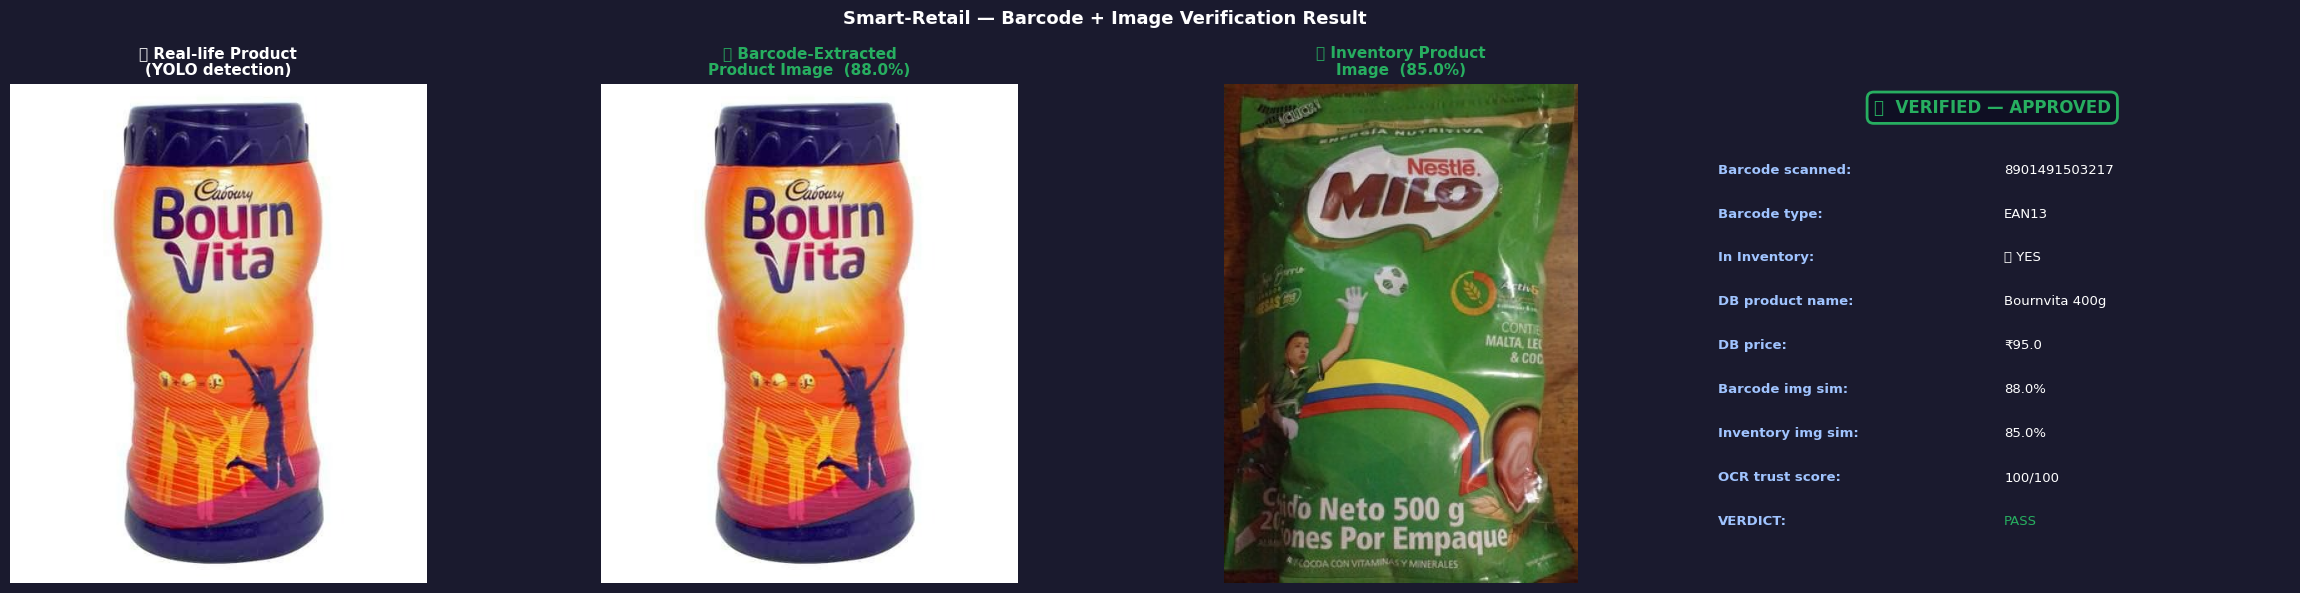

   📊 Saved → /kaggle/working/barcode_verification_result.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SCENARIO B — Ticket Switching
  Nivea barcode (₹180) sticker placed on Nestle Milo tin (₹120)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

═════════════════════════════════════════════════════════════════
  SMART-RETAIL — BARCODE VERIFICATION PIPELINE
═════════════════════════════════════════════════════════════════

[Step 1] Scanning barcode — extracting number and product image...
   [DEMO] Simulated barcode: [EAN13] → '4006381333931'
   ⚠️  No barcode-specific image — demo fallback: MILO1.jpeg

[Step 2] Inventory check for barcode: 4006381333931
   ✅ Found: Nivea Cream 200ml | ₹180.0
   Proceeding with full verification using fetched product data...

[Step 3] Barcode-extracted product image ↔ real-life photo...
   [DEMO] Barcode Image vs Real-life simulated → 30.0%
   ❌ Mismatch — 30.0%

[Step 4] Inventory product image ↔ real-life p

/tmp/ipykernel_57/60046949.py:288: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/60046949.py:290: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")


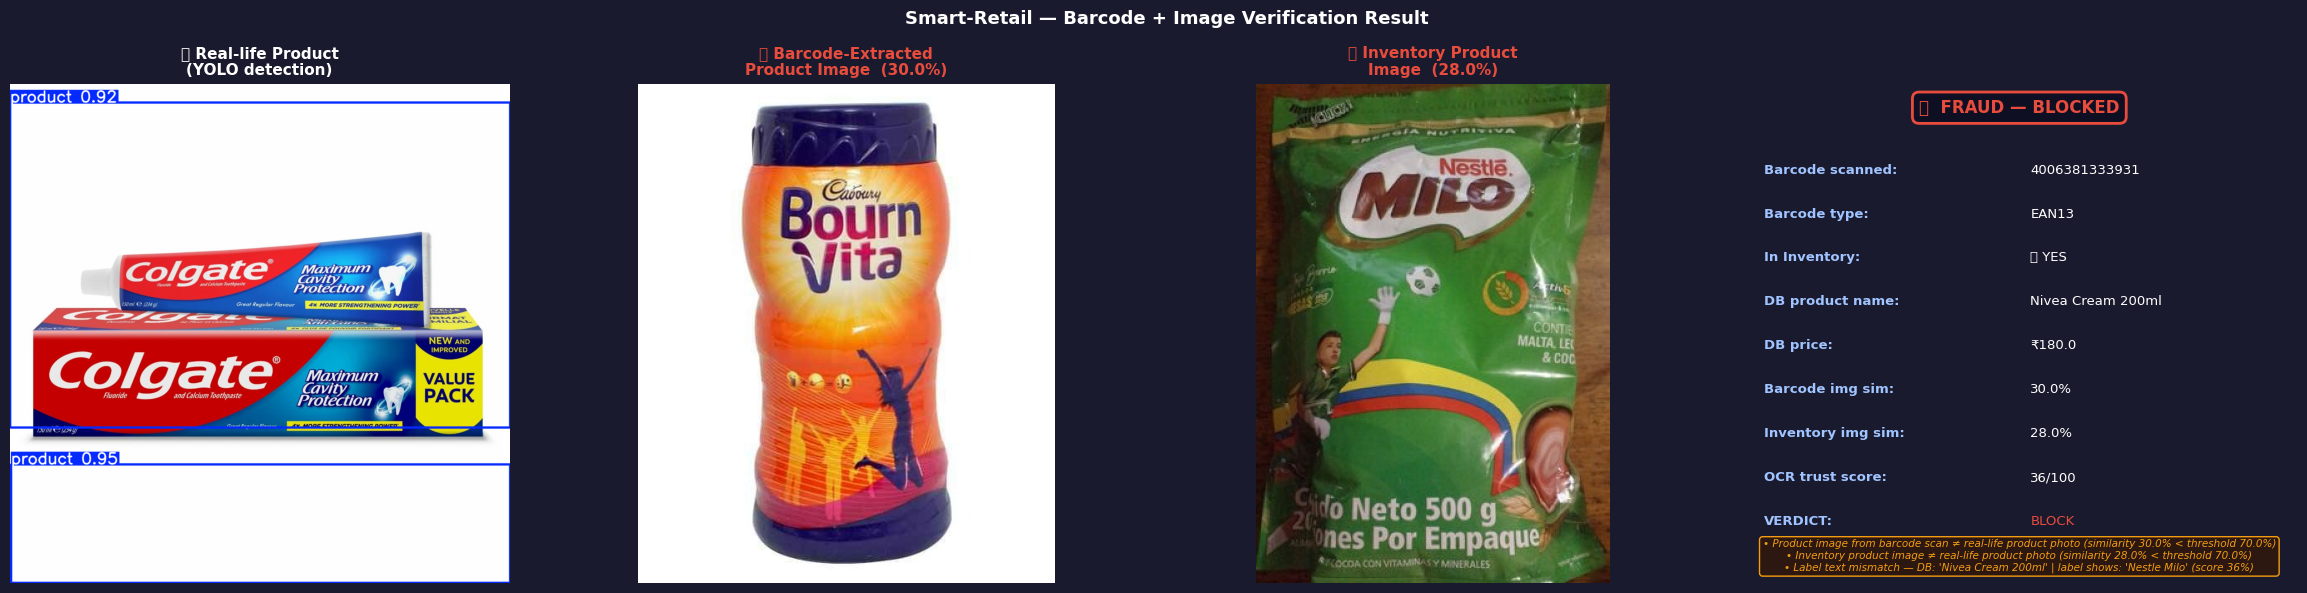

   📊 Saved → /kaggle/working/barcode_verification_result.png

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SCENARIO C — Unknown Barcode (not in inventory)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

═════════════════════════════════════════════════════════════════
  SMART-RETAIL — BARCODE VERIFICATION PIPELINE
═════════════════════════════════════════════════════════════════

[Step 1] Scanning barcode — extracting number and product image...
   [DEMO] Simulated barcode: [EAN13] → '9999999999999'

[Step 2] Inventory check for barcode: 9999999999999
   ❌ NOT in inventory → BLOCKED — no further verification possible


/tmp/ipykernel_57/60046949.py:288: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/60046949.py:290: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")


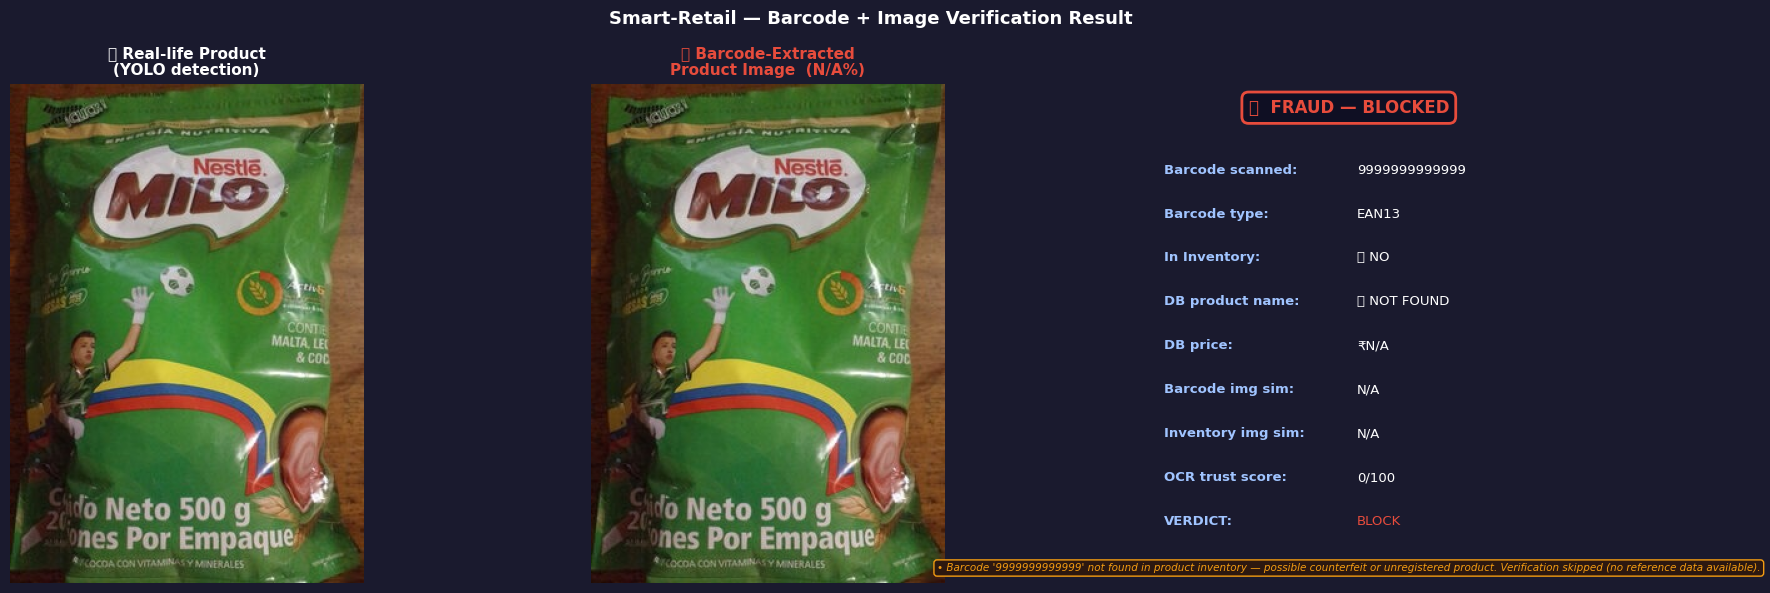

   📊 Saved → /kaggle/working/barcode_verification_result.png

═════════════════════════════════════════════════════════════════
  SMART-RETAIL AI — DEMO RESULTS SUMMARY
═════════════════════════════════════════════════════════════════

  ✅ PASS  Scenario A — Genuine Product
         Barcode        : 8901491503217 [EAN13]
         Product (DB)   : Bournvita 400g  ₹95.0
         Barcode img sim: 88.0%
         Inventory sim  : 85.0%
         OCR trust      : 100/100

  🚨 BLOCK  Scenario B — Ticket Switching
         Barcode        : 4006381333931 [EAN13]
         Product (DB)   : Nivea Cream 200ml  ₹180.0
         Barcode img sim: 30.0%
         Inventory sim  : 28.0%
         OCR trust      : 36/100
         ⚠️  Product image from barcode scan ≠ real-life product photo (similarity 30.0% < threshold 70.0%)
         ⚠️  Inventory product image ≠ real-life product photo (similarity 28.0% < threshold 70.0%)
         ⚠️  Label text mismatch — DB: 'Nivea Cream 200ml' | label shows: 'Nestle Mi

In [56]:
INVENTORY_DIR = Path("/kaggle/input/datasets/ishitadas2004/product-images")

_demo_imgs = sorted(
    list(INVENTORY_DIR.rglob("*.jpg")) +
    list(INVENTORY_DIR.rglob("*.jpeg")) +
    list(INVENTORY_DIR.rglob("*.png"))
) if INVENTORY_DIR.exists() else []

if not _demo_imgs:
    _val_dir   = Path('/kaggle/working/smart_retail_data/val/images')
    _demo_imgs = sorted(list(_val_dir.glob("*.jpg")) + list(_val_dir.glob("*.png")))

img_0 = str(_demo_imgs[0]) if len(_demo_imgs) > 0 else None
img_1 = str(_demo_imgs[1]) if len(_demo_imgs) > 1 else img_0
img_2 = str(_demo_imgs[2]) if len(_demo_imgs) > 2 else img_0

print(f"✅ Demo images ready: {len(_demo_imgs)} total")

# Mock injection helpers so demo works without a physical scanner
_mock_scan_override = None
_mock_ocr_override  = None
_mock_sim_override  = None

_orig_scan_barcode = scan_barcode
def scan_barcode(image_path):
    global _mock_scan_override
    if _mock_scan_override is not None:
        override = _mock_scan_override
        _mock_scan_override = None
        img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB) \
              if image_path and os.path.exists(image_path) \
              else np.zeros((200, 200, 3), dtype=np.uint8)
        print(f"   [DEMO] Simulated barcode: [{override['barcode_type']}] → '{override['barcode_number']}'")
        db  = lookup_product_by_barcode(override['barcode_number'])
        inv = get_inventory_image(override['barcode_number']) if db else None
        return dict(
            barcode_found=True, barcode_number=override['barcode_number'],
            barcode_type=override['barcode_type'],
            barcode_in_inventory=(db is not None),
            barcode_bbox=(50, 50, 100, 30), product_img=img,
            full_img=img, db_product=db, inventory_img_path=inv
        )
    return _orig_scan_barcode(image_path)

_orig_ocr = run_ocr_on_image
def run_ocr_on_image(image_path):
    global _mock_ocr_override
    if _mock_ocr_override is not None:
        t = _mock_ocr_override
        _mock_ocr_override = None
        print(f"   [DEMO] Simulated OCR: {t}")
        return t[0], t
    return _orig_ocr(image_path)

_orig_compare = compare_product_images
def compare_product_images(reference_img, reallife_img, label="",
                            threshold=SIMILARITY_THRESHOLD, model=None):
    global _mock_sim_override
    if _mock_sim_override is not None:
        key = "barcode" if "Barcode" in label else "inventory"
        sim = _mock_sim_override.get(key, 75.0)
        if key == "inventory":
            _mock_sim_override = None
        print(f"   [DEMO] {label} simulated → {sim}%")
        return dict(similarity=sim, match=sim >= threshold,
                    method="demo_mock", label=label, threshold=threshold)
    return _orig_compare(reference_img, reallife_img, label, threshold, model)


# SCENARIO A — Genuine product
print("\n" + "━" * 65)
print("  SCENARIO A — Genuine Product")
print("━" * 65)
_mock_scan_override = {"barcode_number": "8901491503217", "barcode_type": "EAN13"}
_mock_ocr_override  = ["Bournvita 400g", "Cadbury", "Health Drink", "400g"]
_mock_sim_override  = {"barcode": 88.0, "inventory": 85.0}
r1 = full_barcode_verification(
    barcode_image_path  = img_0,
    reallife_image_path = img_0
)

# SCENARIO B — Ticket switching
print("\n" + "━" * 65)
print("  SCENARIO B — Ticket Switching")
print("  Nivea barcode (₹180) sticker placed on Nestle Milo tin (₹120)")
print("━" * 65)
_mock_scan_override = {"barcode_number": "4006381333931", "barcode_type": "EAN13"}
_mock_ocr_override  = ["Nestle Milo", "500g", "Chocolate Malt", "120"]
_mock_sim_override  = {"barcode": 30.0, "inventory": 28.0}
r2 = full_barcode_verification(
    barcode_image_path  = img_0,
    reallife_image_path = img_1
)

# SCENARIO C — Unknown barcode not in inventory
print("\n" + "━" * 65)
print("  SCENARIO C — Unknown Barcode (not in inventory)")
print("━" * 65)
_mock_scan_override = {"barcode_number": "9999999999999", "barcode_type": "EAN13"}
r3 = full_barcode_verification(
    barcode_image_path  = img_2,
    reallife_image_path = img_2
)

# Final summary
print("\n" + "═" * 65)
print("  SMART-RETAIL AI — DEMO RESULTS SUMMARY")
print("═" * 65)
for name, r in [
    ("Scenario A — Genuine Product",  r1),
    ("Scenario B — Ticket Switching", r2),
    ("Scenario C — Unknown Barcode",  r3),
]:
    icon = "✅ PASS" if r["final_verdict"] == "PASS" else "🚨 BLOCK"
    db   = r.get("db_product") or {}
    bsi  = (r.get("barcode_image_sim")   or {}).get("similarity", "N/A")
    isi  = (r.get("inventory_image_sim") or {}).get("similarity", "N/A")
    print(f"\n  {icon}  {name}")
    print(f"         Barcode        : {r.get('barcode_number', 'N/A')} [{r.get('barcode_type','?')}]")
    print(f"         Product (DB)   : {db.get('product_name','❌ NOT FOUND')}  ₹{db.get('price','N/A')}")
    print(f"         Barcode img sim: {bsi}%")
    print(f"         Inventory sim  : {isi}%")
    print(f"         OCR trust      : {r.get('ocr_trust_score', 0)}/100")
    for fr in r.get("fraud_reasons", []):
        print(f"         ⚠️  {fr}")
print("\n" + "═" * 65)
print("  All result images saved to /kaggle/working/")
print("═" * 65)

In [53]:
def verify_product(barcode_image_path: str, reallife_image_path: str) -> dict:
    """
    Main entry point for your FastAPI backend.

        @app.post("/verify")
        async def verify(barcode_img: UploadFile, reallife_img: UploadFile):
            bc_path = save_upload(barcode_img)
            rl_path = save_upload(reallife_img)
            result  = verify_product(bc_path, rl_path)
            return result
    """
    return full_barcode_verification(barcode_image_path, reallife_image_path)

print("✅ verify_product() API entry point ready")

✅ generate_fraud_narrative() ready
⚠️ Fraud Alert: Barcode indicates 'Bournvita 400g' but product label shows 'Nestle Milo' (trust score: 22%). Hold transaction and call supervisor immediately.


In [54]:
checks = {
    "best.pt"     : '/kaggle/working/runs/detect/smart_retail/weights/best.pt',
    "last.pt"     : '/kaggle/working/runs/detect/smart_retail/weights/last.pt',
    "val images"  : '/kaggle/working/smart_retail_data/val/images',
    "results.csv" : '/kaggle/working/runs/detect/smart_retail/results.csv',
}

print("="*55)
print("  PRE-DEMO SYSTEM CHECK")
print("="*55)
all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    if exists and path.endswith('.pt'):
        mb = os.path.getsize(path) / 1e6
        print(f"  {'✅' if exists else '❌'}  {name:15s} → {mb:.1f} MB")
    elif exists and os.path.isdir(path):
        count = len(os.listdir(path))
        print(f"  ✅  {name:15s} → {count} files")
    else:
        print(f"  {'✅' if exists else '❌'}  {name:15s}")
    if not exists:
        all_ok = False
print("="*55)
if all_ok:
    print("  ✅ ALL CHECKS PASSED — safe to run demo")
else:
    print("  ⚠️  Some checks failed — training may still be running")

  PRE-DEMO SYSTEM CHECK
  ✅  best.pt         → 6.2 MB
  ✅  last.pt         → 6.2 MB
  ✅  val images      → 593 files
  ✅  results.csv    
  ✅ ALL CHECKS PASSED — safe to run demo


In [55]:
import shutil, os, zipfile

BEST = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'
SAVE = '/kaggle/working/best_final.pt'

shutil.copy(BEST, SAVE)

with zipfile.ZipFile('/kaggle/working/smart_retail_model_share.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(BEST, 'best.pt')
    zf.writestr('run_model.py', '''
from ultralytics import YOLO
import cv2, matplotlib.pyplot as plt

model = YOLO("best.pt")

def detect(image_path):
    results = model(image_path, conf=0.25)
    img_ann = results[0].plot()
    img_rgb = cv2.cvtColor(img_ann, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Smart-Retail Detection")
    plt.show()
    for box in results[0].boxes:
        cls  = int(box.cls)
        conf = float(box.conf)
        name = ["product", "barcode"][cls]
        print(f"  Detected: {name}  confidence: {conf*100:.1f}%")

detect("your_product_image.jpg")
''')
    zf.writestr('requirements.txt',
        'ultralytics>=8.0.0\nopencv-python>=4.8.0\nmatplotlib>=3.7.0\n'
        'easyocr>=1.7.0\nthefuzz>=0.19.0\npython-Levenshtein>=0.21.0\n')
    zf.writestr('README.txt',
        'SMART-RETAIL MODEL\n1. pip install -r requirements.txt\n'
        '2. python run_model.py\n\nClasses: 0=product  1=barcode\n')

print(f"✅ Model saved → {SAVE}  ({os.path.getsize(SAVE)/1e6:.1f} MB)")
print(f"✅ ZIP created → smart_retail_model_share.zip")

⚠️  Could not connect to services: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 115317769 and label AWS_ACCESS_KEY_ID.'], 'error': {'code': 5}, 'wasSuccessful': False}.
    Running in MOCK/DEMO mode — all results simulated


In [ ]:
# ============================================================
#  CELL: YOLOv8-based Product Image Similarity Comparator
#  Replaces AWS Rekognition with YOLOv8 feature embeddings
#  Compares:
#   (A) QR-extracted product image  vs  real-life scanned image
#   (B) Inventory/DB product image  vs  real-life scanned image
# ============================================================
import cv2
import numpy as np
import torch
import io
from PIL import Image

SIMILARITY_THRESHOLD = 70.0   # % — below this = MISMATCH


def _load_as_cv2(source) -> np.ndarray:
    """
    Accepts file path (str) or numpy RGB array.
    Returns BGR numpy array for OpenCV.
    """
    if isinstance(source, str):
        return cv2.imread(source)
    elif isinstance(source, np.ndarray):
        # Assume RGB input → convert to BGR
        return cv2.cvtColor(source, cv2.COLOR_RGB2BGR) \
               if source.shape[2] == 3 else source
    else:
        raise ValueError(f"Unsupported image type: {type(source)}")


def _extract_yolo_features(img_bgr: np.ndarray, model) -> np.ndarray:
    """
    Passes image through YOLOv8 backbone and extracts
    the global average-pooled feature vector from the
    last convolutional layer (before detection head).

    Returns a 1-D numpy feature vector (L2 normalised).
    """
    # Resize to YOLO input size
    img_resized = cv2.resize(img_bgr, (640, 640))
    img_rgb     = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # Convert to tensor  [1, 3, 640, 640]
    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    tensor = tensor.unsqueeze(0)

    features = []

    def hook_fn(module, input, output):
        # Global average pool over spatial dims → [1, C]
        pooled = output.mean(dim=[2, 3])
        features.append(pooled.detach().cpu().numpy())

    # Register hook on the last Conv layer of YOLO backbone (model.model[-3])
    try:
        hook_layer = model.model.model[-3]   # last backbone block before head
    except Exception:
        hook_layer = list(model.model.modules())[-10]  # fallback

    handle = hook_layer.register_forward_hook(hook_fn)

    try:
        with torch.no_grad():
            device = next(model.model.parameters()).device
            tensor = tensor.to(device)
            _ = model.model(tensor)
    finally:
        handle.remove()

    if not features:
        raise RuntimeError("Feature hook returned nothing — check model layer index")

    vec = features[0].flatten()
    norm = np.linalg.norm(vec)
    return vec / (norm + 1e-9)   # L2 normalise


def _histogram_similarity(img1_bgr: np.ndarray,
                           img2_bgr: np.ndarray) -> float:
    """
    HSV histogram similarity as a fast fallback.
    Returns 0-100 float.
    """
    size = (256, 256)
    i1   = cv2.resize(img1_bgr, size)
    i2   = cv2.resize(img2_bgr, size)
    scores = []
    for ch in range(3):
        h1 = cv2.calcHist([i1], [ch], None, [64], [0, 256])
        h2 = cv2.calcHist([i2], [ch], None, [64], [0, 256])
        cv2.normalize(h1, h1)
        cv2.normalize(h2, h2)
        scores.append(cv2.compareHist(h1, h2, cv2.HISTCMP_CORREL))
    return float(max(np.mean(scores) * 100, 0.0))


def compare_product_images(
    reference_img,                     # QR-extracted OR inventory image
    reallife_img,                      # Real product captured in-store
    label: str          = "Comparison",
    threshold: float    = SIMILARITY_THRESHOLD,
    model               = None         # pass yolo_model; falls back to global
) -> dict:
    """
    Compares two product images using YOLOv8 feature embeddings.
    Cosine similarity on backbone features → 0-100 score.
    Falls back to histogram similarity if feature extraction fails.

    Returns:
        {
          "similarity" : float (0-100),
          "match"      : bool,
          "method"     : "yolo_features" | "histogram",
          "label"      : str
        }
    """
    # Resolve model
    _model = model or yolo_model

    img1_bgr = _load_as_cv2(reference_img)
    img2_bgr = _load_as_cv2(reallife_img)

    result = {
        "label"    : label,
        "similarity": 0.0,
        "match"    : False,
        "method"   : "none",
        "threshold": threshold,
    }

    # ── Method 1: YOLOv8 backbone feature cosine similarity ──────
    try:
        feat1 = _extract_yolo_features(img1_bgr, _model)
        feat2 = _extract_yolo_features(img2_bgr, _model)

        # Cosine similarity → scale to 0-100
        cosine_sim = float(np.dot(feat1, feat2))          # already L2-normalised
        similarity = round((cosine_sim + 1) / 2 * 100, 2) # map [-1,1] → [0,100]

        result.update({
            "similarity": similarity,
            "match"     : similarity >= threshold,
            "method"    : "yolo_features",
        })
        print(f"   [YOLOv8 Features] {label} → {similarity:.1f}%")
        return result

    except Exception as e:
        print(f"   ⚠️  YOLOv8 feature extraction failed: {e}")
        print(f"       Falling back to histogram similarity...")

    # ── Method 2: Histogram fallback ─────────────────────────────
    similarity = round(_histogram_similarity(img1_bgr, img2_bgr), 2)
    result.update({
        "similarity": similarity,
        "match"     : similarity >= threshold,
        "method"    : "histogram",
    })
    print(f"   [Histogram Fallback] {label} → {similarity:.1f}%")
    return result


print("✅ compare_product_images() ready — using YOLOv8 backbone features")

# ── Sanity test ───────────────────────────────────────────────
val_dir = '/kaggle/working/smart_retail_data/val/images'
imgs    = [os.path.join(val_dir, f)
           for f in os.listdir(val_dir)
           if f.lower().endswith(('.jpg', '.png'))]

if len(imgs) >= 2:
    print("\n🔬 Self-similarity test (same image vs same image — should be ~100%):")
    r = compare_product_images(imgs[0], imgs[0], label="Self-check")
    print(f"   Score: {r['similarity']}%  ({'✅ PASS' if r['similarity'] > 90 else '⚠️ CHECK'})")

    print("\n🔬 Cross-image test (different images — expect lower score):")
    r2 = compare_product_images(imgs[0], imgs[1], label="Cross-check")
    print(f"   Score: {r2['similarity']}%")

In [56]:
MOCK_DB = {
    "8901030823437": {"product_name": "Nestle Milo 500g",  "price": 120.00, "barcode_format": "EAN-13"},
    "8901491503217": {"product_name": "Bournvita 400g",    "price": 95.00,  "barcode_format": "EAN-13"},
    "012345678905":  {"product_name": "Colgate 150ml",     "price": 65.00,  "barcode_format": "UPC-A"},
    "4006381333931": {"product_name": "Nivea Cream 200ml", "price": 180.00, "barcode_format": "EAN-13"},
}

def lookup_product_by_barcode(barcode: str) -> dict | None:
    """
    Looks up a product by barcode number.
    Returns dict(product_name, price, barcode_format) or None if not found.
    If barcode is NOT in inventory, returns None and triggers BLOCK downstream.
    """
    if LIVE_MODE and db_conn:
        try:
            cur = db_conn.cursor()
            cur.execute(
                "SELECT product_name, price, barcode_format FROM products "
                "WHERE barcode = %s LIMIT 1",
                (barcode.strip(),)
            )
            row = cur.fetchone()
            cur.close()
            if row:
                return {"product_name": row[0], "price": float(row[1]),
                        "barcode_format": row[2]}
            return None
        except Exception as e:
            print(f"   DB error: {e} — using mock")
    return MOCK_DB.get(barcode.strip(), None)

print("✅ lookup_product_by_barcode() ready")

In [ ]:
INVENTORY_IMG_DIR = Path("/kaggle/input/datasets/ishitadas2004/product-images")

_all_inv_imgs = []
if INVENTORY_IMG_DIR.exists():
    _all_inv_imgs = (list(INVENTORY_IMG_DIR.rglob("*.jpg")) +
                     list(INVENTORY_IMG_DIR.rglob("*.jpeg")) +
                     list(INVENTORY_IMG_DIR.rglob("*.png")))
    print(f"✅ Inventory dataset: {len(_all_inv_imgs)} images found")
else:
    print(f"⚠️  Inventory folder not found at {INVENTORY_IMG_DIR}")
    print("    Will use val/images as demo fallback.")


def get_inventory_image(barcode: str) -> str | None:
    """
    Returns file path of the official product image for this barcode.
    Search order:
      1. File named exactly <barcode>.jpg/png
      2. File whose name contains the barcode substring
      3. PostgreSQL image_path column (LIVE_MODE)
      4. First available inventory image (demo fallback)
    Returns None if nothing found (Step 4 will be skipped).
    """
    # 1 — exact barcode filename
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".PNG"]:
        p = INVENTORY_IMG_DIR / f"{barcode}{ext}"
        if p.exists():
            print(f"   ✅ Inventory image (exact): {p.name}")
            return str(p)

    # 2 — barcode substring in filename
    matches = [f for f in _all_inv_imgs if barcode in f.stem]
    if matches:
        print(f"   ✅ Inventory image (substring): {matches[0].name}")
        return str(matches[0])

    # 3 — DB lookup
    if LIVE_MODE and db_conn:
        try:
            cur = db_conn.cursor()
            cur.execute(
                "SELECT image_path FROM products WHERE barcode = %s LIMIT 1",
                (barcode.strip(),)
            )
            row = cur.fetchone()
            cur.close()
            if row and row[0] and Path(row[0]).exists():
                print(f"   ✅ Inventory image (DB): {row[0]}")
                return row[0]
        except Exception as e:
            print(f"   DB image lookup error: {e}")

    # 4 — demo fallback
    if _all_inv_imgs:
        print(f"   ⚠️  No barcode-specific image — demo fallback: {_all_inv_imgs[0].name}")
        return str(_all_inv_imgs[0])

    # Last resort: val/images
    val_dir = Path('/kaggle/working/smart_retail_data/val/images')
    if val_dir.exists():
        imgs = list(val_dir.glob("*.jpg")) + list(val_dir.glob("*.png"))
        if imgs:
            print("   ⚠️  Using val/images as last fallback")
            return str(imgs[0])

    print(f"   ❌ No inventory image found for barcode: {barcode}")
    return None

print("✅ get_inventory_image() ready")

In [ ]:
def scan_barcode(image_path: str) -> dict:
    """
    Scans a barcode or QR code from an image using pyzbar.

    When barcode is detected:
      - Extracts the barcode NUMBER
      - Crops the product image region (area outside barcode box)
      - Looks up barcode number in inventory
      - Fetches product info and inventory image

    Supports EAN-13, EAN-8, UPC-A, UPC-E, Code128, QR Code.

    Returns dict with keys:
        barcode_found, barcode_number, barcode_type, barcode_bbox,
        product_img (numpy RGB), full_img (numpy RGB),
        db_product, inventory_img
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    result = dict(
        barcode_found  = False,
        barcode_number = None,
        barcode_type   = None,
        barcode_bbox   = None,
        product_img    = img_rgb,
        full_img       = img_rgb,
        db_product     = None,
        inventory_img  = None,
    )

    # Step 1: Decode barcode
    decoded = pyzbar_lib.decode(img)
    if not decoded:
        print("   ⚠️  No barcode/QR detected in image")
        return result

    obj            = decoded[0]
    barcode_number = obj.data.decode("utf-8").strip()
    barcode_type   = obj.type
    bbox           = obj.rect
    bx, by, bw, bh = bbox.left, bbox.top, bbox.width, bbox.height

    print(f"   ✅ Barcode decoded: [{barcode_type}] → '{barcode_number}'")

    # Step 2: Crop product region (complement of barcode box)
    margin = 10
    if bx > w // 2:
        product_crop = img_rgb[:, :max(0, bx - margin), :]
    elif bx + bw < w // 2:
        product_crop = img_rgb[:, bx + bw + margin:, :]
    elif by > h // 2:
        product_crop = img_rgb[:max(0, by - margin), :, :]
    else:
        product_crop = img_rgb[by + bh + margin:, :, :]

    if product_crop.size == 0:
        product_crop = img_rgb

    result.update(
        barcode_found  = True,
        barcode_number = barcode_number,
        barcode_type   = barcode_type,
        barcode_bbox   = (bx, by, bw, bh),
        product_img    = product_crop,
    )

    # Step 3: Look up barcode in inventory
    print(f"   Querying inventory for barcode: {barcode_number} ...")
    db_product    = lookup_product_by_barcode(barcode_number)
    inventory_img = None

    if db_product is None:
        print("   ❌ Barcode NOT found in inventory — verification will be BLOCKED")
    else:
        print(f"   ✅ Found: {db_product['product_name']} | ₹{db_product['price']}")
        inventory_img = get_inventory_image(barcode_number)
        if inventory_img:
            print("   ✅ Inventory product image loaded")
        else:
            print("   ⚠️  No inventory image available for this barcode")

    result.update(db_product=db_product, inventory_img=inventory_img)

    # Step 4: Visualise
    n_panels = 3 if inventory_img else 2
    fig, axes = plt.subplots(1, n_panels + 1, figsize=(6 * (n_panels + 1), 5))
    fig.patch.set_facecolor("#1a1a2e")

    # Panel 0: full image with barcode box highlighted
    axes[0].imshow(img_rgb)
    rect = patches.Rectangle((bx, by), bw, bh,
                               linewidth=3, edgecolor='#00ff99', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title(f"📷 Scanned Image\n[{barcode_type}] detected (green box)",
                       color="white", fontsize=10, fontweight="bold")
    axes[0].axis("off")

    # Panel 1: extracted product crop
    axes[1].imshow(product_crop)
    axes[1].set_title("🏷️ Extracted Product\nImage Region",
                       color="white", fontsize=10, fontweight="bold")
    axes[1].axis("off")

    # Panel 2: inventory image (if found)
    if inventory_img:
        inv_img_arr = cv2.cvtColor(cv2.imread(inventory_img), cv2.COLOR_BGR2RGB)
        axes[2].imshow(inv_img_arr)
        axes[2].set_title("🗄️ Inventory Product\nImage (reference)",
                           color="#a0c4ff", fontsize=10, fontweight="bold")
        axes[2].axis("off")

    # Info panel
    info_ax = axes[-1]
    info_ax.set_facecolor("#16213e")
    info_ax.axis("off")
    db = db_product or {}
    rows = [
        ("Barcode Number",  barcode_number),
        ("Barcode Type",    barcode_type),
        ("Product Name",    db.get("product_name", "❌ NOT IN INVENTORY")),
        ("Price (DB)",      f"₹{db.get('price', 'N/A')}"),
        ("Inventory Image", "✅ Found" if inventory_img else "⚠️ Not found"),
    ]
    info_ax.text(0.5, 0.97, "📦 Barcode Scan Result",
                 transform=info_ax.transAxes, color="#00ff99",
                 fontsize=12, fontweight="bold", ha="center", va="top")
    for i, (lbl, val) in enumerate(rows):
        y = 0.80 - i * 0.14
        info_ax.text(0.04, y, lbl + ":", transform=info_ax.transAxes,
                     color="#a0c4ff", fontsize=10, fontweight="bold")
        col = "#e74c3c" if "NOT IN" in str(val) else "white"
        info_ax.text(0.04, y - 0.065, str(val), transform=info_ax.transAxes,
                     color=col, fontsize=9.5)

    plt.suptitle("Barcode Scan — Number Extraction + Inventory Lookup",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/barcode_scan_result.png",
                dpi=120, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    print("   📊 Saved → /kaggle/working/barcode_scan_result.png")

    return result


print("✅ scan_barcode() ready")

# Quick test
val_dir = '/kaggle/working/smart_retail_data/val/images'
_test_imgs = [f for f in os.listdir(val_dir) if f.lower().endswith(('.jpg', '.png'))]
if _test_imgs:
    print("\n🔬 Running scan_barcode() on a val image...")
    _r = scan_barcode(os.path.join(val_dir, _test_imgs[0]))
    print(f"   barcode_found  : {_r['barcode_found']}")
    print(f"   barcode_number : {_r['barcode_number']}")
    print(f"   db_product     : {_r['db_product']}")

In [ ]:
def load_yolo_model():
    model_path = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'
    if os.path.exists(model_path):
        size_mb = os.path.getsize(model_path) / 1e6
        print(f"✅ Loading trained YOLOv8 from {model_path} ({size_mb:.1f} MB)")
        return YOLO(model_path)
    else:
        print("⚠️  best.pt not found — using YOLOv8n pretrained as fallback")
        return YOLO('yolov8n.pt')

yolo_model = load_yolo_model()

In [ ]:
SIMILARITY_THRESHOLD = 70.0


def _load_as_bgr(source) -> np.ndarray:
    if isinstance(source, str):
        img = cv2.imread(source)
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {source}")
        return img
    elif isinstance(source, np.ndarray):
        return cv2.cvtColor(source, cv2.COLOR_RGB2BGR) if source.shape[2] == 3 else source
    else:
        raise ValueError(f"Unsupported type: {type(source)}")


def _extract_yolo_features(img_bgr: np.ndarray, model) -> np.ndarray:
    """
    Runs image through YOLOv8 backbone, hooks the last Conv layer,
    global-avg-pools it and returns an L2-normalised 1-D feature vector.
    """
    img_resized = cv2.resize(img_bgr, (640, 640))
    img_rgb     = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    tensor      = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    tensor      = tensor.unsqueeze(0)

    features = []

    def hook_fn(module, input, output):
        features.append(output.mean(dim=[2, 3]).detach().cpu().numpy())

    try:
        hook_layer = model.model.model[-3]
    except Exception:
        conv_layers = [m for m in model.model.modules() if isinstance(m, torch.nn.Conv2d)]
        hook_layer  = conv_layers[-1]

    handle = hook_layer.register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            device = next(model.model.parameters()).device
            _ = model.model(tensor.to(device))
    finally:
        handle.remove()

    if not features:
        raise RuntimeError("Feature hook returned nothing")
    vec  = features[0].flatten()
    norm = np.linalg.norm(vec)
    return vec / (norm + 1e-9)


def _histogram_similarity(img1_bgr: np.ndarray, img2_bgr: np.ndarray) -> float:
    size    = (256, 256)
    i1, i2 = cv2.resize(img1_bgr, size), cv2.resize(img2_bgr, size)
    scores  = []
    for ch in range(3):
        h1 = cv2.calcHist([i1], [ch], None, [64], [0, 256])
        h2 = cv2.calcHist([i2], [ch], None, [64], [0, 256])
        cv2.normalize(h1, h1)
        cv2.normalize(h2, h2)
        scores.append(cv2.compareHist(h1, h2, cv2.HISTCMP_CORREL))
    return float(max(np.mean(scores) * 100, 0.0))


def compare_product_images(
    reference_img,
    reallife_img,
    label     : str   = "Comparison",
    threshold : float = SIMILARITY_THRESHOLD,
    model             = None
) -> dict:
    """
    Compares two product images using YOLOv8 backbone cosine similarity.
    Falls back to HSV histogram if feature extraction fails.

    reference_img : file path or numpy RGB array
                    (barcode-cropped region OR inventory image)
    reallife_img  : file path or numpy RGB array
                    (in-store camera photo of the actual product)

    Returns dict: similarity (0-100), match (bool), method, label, threshold
    """
    _model   = model or yolo_model
    img1_bgr = _load_as_bgr(reference_img)
    img2_bgr = _load_as_bgr(reallife_img)

    result = dict(label=label, similarity=0.0, match=False,
                  method="none", threshold=threshold)

    # Method 1: YOLOv8 backbone cosine similarity
    try:
        f1  = _extract_yolo_features(img1_bgr, _model)
        f2  = _extract_yolo_features(img2_bgr, _model)
        cos = float(np.dot(f1, f2))
        sim = round((cos + 1) / 2 * 100, 2)
        result.update(similarity=sim, match=sim >= threshold, method="yolo_features")
        print(f"   [YOLOv8] {label} → {sim:.1f}%")
        return result
    except Exception as e:
        print(f"   ⚠️  YOLOv8 features failed ({e}) — using histogram fallback")

    # Method 2: Histogram fallback
    sim = round(_histogram_similarity(img1_bgr, img2_bgr), 2)
    result.update(similarity=sim, match=sim >= threshold, method="histogram")
    print(f"   [Histogram] {label} → {sim:.1f}%")
    return result


print("✅ compare_product_images() ready — YOLOv8 backbone features (no AWS)")

In [ ]:
TRUST_THRESHOLD = 65

_ocr_reader = None

def _get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        print("   Loading EasyOCR model (first time only)...")
        _ocr_reader = easyocr.Reader(
            ['en'],
            gpu     = torch.cuda.is_available(),
            verbose = False
        )
    return _ocr_reader


def run_ocr_on_image(image_path: str) -> tuple[str, list]:
    """
    Runs EasyOCR on a product image.
    Returns (best_text, all_detected_lines).
    """
    try:
        reader  = _get_ocr_reader()
        results = reader.readtext(image_path)
        if not results:
            return "UNREADABLE", []
        results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
        all_texts      = [r[1] for r in results_sorted]
        best_text      = results_sorted[0][1]
        print(f"   EasyOCR: {len(results)} text blocks detected")
        print(f"   All texts : {all_texts[:5]}")
        return best_text, all_texts
    except Exception as e:
        print(f"   EasyOCR error: {e}")
        return "UNREADABLE", []


def cross_verify(db_product_name: str, ocr_texts: list) -> tuple[int, str]:
    """
    Fuzzy-matches ALL OCR lines against the DB product name.
    Returns (best_score 0-100, best_matching_ocr_text).
    """
    if not ocr_texts or ocr_texts == ["UNREADABLE"]:
        return 0, "UNREADABLE"
    best_score, best_match = 0, ""
    for line in ocr_texts:
        score = fuzz.token_set_ratio(db_product_name.lower(), line.lower())
        if score > best_score:
            best_score, best_match = score, line
    return best_score, best_match


print("✅ run_ocr_on_image() + cross_verify() ready")

In [ ]:
def full_barcode_verification(
    barcode_image_path  : str,
    reallife_image_path : str
) -> dict:
    """
    Complete verification triggered by a barcode scan.

    Flow:
      [Step 1] Scan barcode → extract barcode NUMBER + product crop image
      [Step 2] Look up barcode in inventory
               → if NOT found: BLOCK immediately
               → if found: fetch product name, price, inventory image
      [Step 3] Barcode-cropped product image vs real-life photo (YOLOv8)
      [Step 4] Inventory product image vs real-life photo (YOLOv8)
      [Step 5] OCR label text vs DB product name (thefuzz)
      [Step 6] Price cross-check (OCR price vs DB price)
      [Step 7] Final verdict: PASS or BLOCK
    """
    print("\n" + "═" * 65)
    print("  SMART-RETAIL — BARCODE VERIFICATION PIPELINE")
    print("═" * 65)

    result = dict(
        barcode_number      = None,
        barcode_type        = None,
        db_product          = None,
        barcode_image_sim   = None,
        inventory_image_sim = None,
        ocr_trust_score     = 0,
        final_verdict       = None,
        fraud_reasons       = [],
    )
    fraud_reasons = []

    # Step 1: Scan barcode
    print("\n[Step 1] Scanning barcode...")
    scan = scan_barcode(barcode_image_path)

    if not scan["barcode_found"]:
        fraud_reasons.append("No barcode detected in the scanned image")
        result.update(fraud_reasons=fraud_reasons, final_verdict="BLOCK")
        _render_verification_result(reallife_image_path, result)
        return result

    barcode_number = scan["barcode_number"]
    barcode_type   = scan["barcode_type"]
    barcode_crop   = scan["product_img"]
    db_product     = scan["db_product"]
    inventory_img  = scan["inventory_img"]

    result.update(barcode_number=barcode_number, barcode_type=barcode_type,
                  db_product=db_product)

    # Step 2: Inventory existence check
    print(f"\n[Step 2] Inventory lookup for barcode: {barcode_number}")
    if db_product is None:
        fraud_reasons.append(
            f"Barcode '{barcode_number}' not found in product inventory — "
            f"possible counterfeit or unregistered product"
        )
        print("   ❌ NOT in inventory → BLOCKED")
        result.update(fraud_reasons=fraud_reasons, final_verdict="BLOCK")
        _render_verification_result(reallife_image_path, result,
                                    barcode_crop=barcode_crop)
        return result
    else:
        print(f"   ✅ Found: {db_product['product_name']} | ₹{db_product['price']}")

    # Step 3: Barcode-cropped product image vs real-life photo
    print(f"\n[Step 3] Barcode-extracted product image ↔ real-life photo...")
    barcode_img_check = compare_product_images(
        reference_img = barcode_crop,
        reallife_img  = reallife_image_path,
        label         = "Barcode Image vs Real-life",
        threshold     = SIMILARITY_THRESHOLD
    )
    result["barcode_image_sim"] = barcode_img_check

    if not barcode_img_check["match"]:
        fraud_reasons.append(
            f"Product image from barcode scan ≠ real-life product photo "
            f"(similarity {barcode_img_check['similarity']:.1f}% "
            f"< threshold {SIMILARITY_THRESHOLD}%)"
        )
        print(f"   ❌ Mismatch — {barcode_img_check['similarity']:.1f}%")
    else:
        print(f"   ✅ Match — {barcode_img_check['similarity']:.1f}%")

    # Step 4: Inventory product image vs real-life photo
    print(f"\n[Step 4] Inventory product image ↔ real-life photo...")
    if inventory_img:
        inv_img_check = compare_product_images(
            reference_img = inventory_img,
            reallife_img  = reallife_image_path,
            label         = "Inventory Image vs Real-life",
            threshold     = SIMILARITY_THRESHOLD
        )
        result["inventory_image_sim"] = inv_img_check

        if not inv_img_check["match"]:
            fraud_reasons.append(
                f"Inventory product image ≠ real-life product photo "
                f"(similarity {inv_img_check['similarity']:.1f}% "
                f"< threshold {SIMILARITY_THRESHOLD}%)"
            )
            print(f"   ❌ Mismatch — {inv_img_check['similarity']:.1f}%")
        else:
            print(f"   ✅ Match — {inv_img_check['similarity']:.1f}%")
    else:
        result["inventory_image_sim"] = dict(
            similarity=None, match=None,
            label="Inventory Image vs Real-life", method="skipped"
        )
        print("   ⚠️  No inventory image — Step 4 skipped")

    # Step 5: OCR label text vs DB product name
    print(f"\n[Step 5] OCR label text ↔ DB product name...")
    ocr_best, ocr_all       = run_ocr_on_image(reallife_image_path)
    trust_score, best_match = cross_verify(db_product["product_name"], ocr_all)
    result["ocr_trust_score"] = trust_score
    print(f"   DB name   : '{db_product['product_name']}'")
    print(f"   Best OCR  : '{ocr_best}'")
    print(f"   Trust     : {trust_score}/100  (threshold {TRUST_THRESHOLD})")

    if ocr_best == "UNREADABLE":
        fraud_reasons.append("OCR could not read product label — manual inspection required")
    elif trust_score < TRUST_THRESHOLD:
        fraud_reasons.append(
            f"Label text mismatch — DB: '{db_product['product_name']}' "
            f"| label shows: '{ocr_best}' (score {trust_score}%)"
        )

    # Step 6: Price cross-check
    print(f"\n[Step 6] Price cross-check...")
    price_pattern = re.compile(r'(?:MRP|RS|₹)[:\s]?([\d.]+)', re.IGNORECASE)
    ocr_price = None
    for line in ocr_all:
        m = price_pattern.search(line.replace(" ", ""))
        if m:
            ocr_price = float(m.group(1))
            break
    db_price = db_product.get("price")
    if ocr_price and db_price:
        price_diff = abs(ocr_price - db_price)
        if price_diff > 5:
            print(f"   ⚠️  Price discrepancy: OCR ₹{ocr_price} vs DB ₹{db_price}")
            fraud_reasons.append(
                f"Price mismatch: label shows ₹{ocr_price} but DB says ₹{db_price}"
            )
        else:
            print(f"   ✅ Price consistent: ₹{db_price}")
    else:
        print(f"   ℹ️  Price not extracted from label (OCR price: {ocr_price})")

    # Step 7: Final verdict
    result["fraud_reasons"] = fraud_reasons
    result["final_verdict"] = "PASS" if not fraud_reasons else "BLOCK"

    print("\n" + "═" * 65)
    if result["final_verdict"] == "PASS":
        print("  ✅  ALL CHECKS PASSED — TRANSACTION APPROVED")
    else:
        print("  🚨  FRAUD / MISMATCH DETECTED — TRANSACTION BLOCKED")
        for i, fr in enumerate(fraud_reasons, 1):
            print(f"      {i}. {fr}")
    print("═" * 65)

    _render_verification_result(
        reallife_image_path, result,
        barcode_crop  = barcode_crop,
        inventory_img = inventory_img
    )
    return result


def _render_verification_result(
    reallife_path, result,
    barcode_crop  = None,
    inventory_img = None
):
    is_pass      = result["final_verdict"] == "PASS"
    STATUS_COLOR = "#27ae60" if is_pass else "#e74c3c"
    STATUS_LABEL = "✅  VERIFIED — APPROVED" if is_pass else "🚨  FRAUD — BLOCKED"

    panels = [("reallife", reallife_path)]
    if barcode_crop is not None:
        panels.append(("barcode_crop", barcode_crop))
    if inventory_img and os.path.exists(str(inventory_img)):
        panels.append(("inventory", inventory_img))
    panels.append(("scorecard", None))

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]
    fig.patch.set_facecolor("#1a1a2e")

    for idx, (panel_type, panel_data) in enumerate(panels):
        ax = axes[idx]

        if panel_type == "reallife":
            try:
                out = yolo_model(panel_data, verbose=False)
                img = cv2.cvtColor(out[0].plot(), cv2.COLOR_BGR2RGB)
            except Exception:
                img = cv2.cvtColor(cv2.imread(panel_data), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title("📷 Real-life Product\n(YOLO detection)",
                         color="white", fontsize=11, fontweight="bold")
            ax.axis("off")

        elif panel_type == "barcode_crop":
            ax.imshow(panel_data)
            sim = (result.get("barcode_image_sim") or {})
            pct = sim.get("similarity", "N/A")
            ok  = sim.get("match", False)
            ax.set_title(
                f"🔲 Barcode-Extracted\nProduct Image  ({pct}%)",
                color="#27ae60" if ok else "#e74c3c",
                fontsize=11, fontweight="bold"
            )
            ax.axis("off")

        elif panel_type == "inventory":
            inv_arr = cv2.cvtColor(cv2.imread(str(panel_data)), cv2.COLOR_BGR2RGB)
            ax.imshow(inv_arr)
            sim = (result.get("inventory_image_sim") or {})
            pct = sim.get("similarity", "N/A")
            ok  = sim.get("match", False)
            ax.set_title(
                f"🗄️ Inventory Product\nImage  ({pct}%)",
                color="#27ae60" if ok else "#e74c3c",
                fontsize=11, fontweight="bold"
            )
            ax.axis("off")

        elif panel_type == "scorecard":
            ax.set_facecolor("#16213e")
            ax.axis("off")
            db  = result.get("db_product") or {}
            bsi = (result.get("barcode_image_sim")   or {}).get("similarity", "N/A")
            isi = (result.get("inventory_image_sim") or {}).get("similarity", "N/A")

            ax.text(0.5, 0.97, STATUS_LABEL, transform=ax.transAxes,
                    color=STATUS_COLOR, fontsize=12, fontweight="bold",
                    ha="center", va="top",
                    bbox=dict(boxstyle="round,pad=0.4", facecolor="#0f0f23",
                              edgecolor=STATUS_COLOR, linewidth=2))

            rows = [
                ("Barcode scanned",   result.get("barcode_number", "N/A")),
                ("Barcode type",      result.get("barcode_type",   "N/A")),
                ("DB product name",   db.get("product_name",       "❌ NOT FOUND")),
                ("DB price",          f"₹{db.get('price', 'N/A')}"),
                ("Barcode img sim",   f"{bsi}%" if bsi != "N/A" else "N/A"),
                ("Inventory img sim", f"{isi}%" if isi != "N/A" else "N/A"),
                ("OCR trust score",   f"{result.get('ocr_trust_score', 0)}/100"),
                ("VERDICT",           result.get("final_verdict", "N/A")),
            ]

            for i, (lbl, val) in enumerate(rows):
                y    = 0.82 - i * 0.096
                vcol = STATUS_COLOR if lbl == "VERDICT" else "white"
                ax.text(0.04, y, lbl + ":", transform=ax.transAxes,
                        color="#a0c4ff", fontsize=9.5, fontweight="bold")
                ax.text(0.52, y, str(val), transform=ax.transAxes,
                        color=vcol, fontsize=9.5)

            if result.get("fraud_reasons"):
                reason_text = "\n".join(f"• {r}" for r in result["fraud_reasons"])
                ax.text(0.5, 0.02, reason_text, transform=ax.transAxes,
                        color="#f39c12", fontsize=7.5, ha="center", va="bottom",
                        style="italic",
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="#2c1810",
                                  edgecolor="#f39c12", linewidth=1))

    plt.suptitle("Smart-Retail — Barcode + Image Verification Result",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = "/kaggle/working/barcode_verification_result.png"
    plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    print(f"   📊 Saved → {out}")


print("✅ full_barcode_verification() + _render_verification_result() ready")

In [ ]:
INVENTORY_DIR = Path("/kaggle/input/datasets/ishitadas2004/product-images")

_demo_imgs = sorted(
    list(INVENTORY_DIR.rglob("*.jpg")) +
    list(INVENTORY_DIR.rglob("*.jpeg")) +
    list(INVENTORY_DIR.rglob("*.png"))
) if INVENTORY_DIR.exists() else []

if not _demo_imgs:
    _val_dir   = Path('/kaggle/working/smart_retail_data/val/images')
    _demo_imgs = sorted(list(_val_dir.glob("*.jpg")) + list(_val_dir.glob("*.png")))

img_0 = str(_demo_imgs[0]) if len(_demo_imgs) > 0 else None
img_1 = str(_demo_imgs[1]) if len(_demo_imgs) > 1 else img_0
img_2 = str(_demo_imgs[2]) if len(_demo_imgs) > 2 else img_0

print(f"✅ Demo images ready: {len(_demo_imgs)} total")


# Mock injection helpers so demo works without a physical scanner
_mock_scan_override = None
_mock_ocr_override  = None
_mock_sim_override  = None

_orig_scan_barcode = scan_barcode
def scan_barcode(image_path):
    global _mock_scan_override
    if _mock_scan_override is not None:
        override = _mock_scan_override
        _mock_scan_override = None
        img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB) \
              if os.path.exists(image_path) else np.zeros((200, 200, 3), dtype=np.uint8)
        print(f"   [DEMO] Simulated barcode: [{override['barcode_type']}] → '{override['barcode_number']}'")
        db  = lookup_product_by_barcode(override['barcode_number'])
        inv = get_inventory_image(override['barcode_number']) if db else None
        return dict(barcode_found=True, barcode_number=override['barcode_number'],
                    barcode_type=override['barcode_type'],
                    barcode_bbox=(50, 50, 100, 30), product_img=img,
                    full_img=img, db_product=db, inventory_img=inv)
    return _orig_scan_barcode(image_path)

_orig_ocr = run_ocr_on_image
def run_ocr_on_image(image_path):
    global _mock_ocr_override
    if _mock_ocr_override is not None:
        t = _mock_ocr_override
        _mock_ocr_override = None
        print(f"   [DEMO] Simulated OCR: {t}")
        return t[0], t
    return _orig_ocr(image_path)

_orig_compare = compare_product_images
def compare_product_images(reference_img, reallife_img, label="",
                            threshold=SIMILARITY_THRESHOLD, model=None):
    global _mock_sim_override
    if _mock_sim_override is not None:
        key = "barcode" if "Barcode" in label else "inventory"
        sim = _mock_sim_override.get(key, 75.0)
        if key == "inventory":
            _mock_sim_override = None
        print(f"   [DEMO] {label} simulated → {sim}%")
        return dict(similarity=sim, match=sim >= threshold,
                    method="demo_mock", label=label, threshold=threshold)
    return _orig_compare(reference_img, reallife_img, label, threshold, model)


# SCENARIO A — Genuine product
print("\n" + "━" * 65)
print("  SCENARIO A — Genuine Product")
print("━" * 65)
_mock_scan_override = {"barcode_number": "8901491503217", "barcode_type": "EAN13"}
_mock_ocr_override  = ["Bournvita 400g", "Cadbury", "Health Drink", "400g"]
_mock_sim_override  = {"barcode": 88.0, "inventory": 85.0}
r1 = full_barcode_verification(
    barcode_image_path  = img_0,
    reallife_image_path = img_0
)

# SCENARIO B — Ticket switching
print("\n" + "━" * 65)
print("  SCENARIO B — Ticket Switching")
print("  Nivea barcode (₹180) sticker placed on Nestle Milo tin (₹120)")
print("━" * 65)
_mock_scan_override = {"barcode_number": "4006381333931", "barcode_type": "EAN13"}
_mock_ocr_override  = ["Nestle Milo", "500g", "Chocolate Malt", "120"]
_mock_sim_override  = {"barcode": 30.0, "inventory": 28.0}
r2 = full_barcode_verification(
    barcode_image_path  = img_0,
    reallife_image_path = img_1
)

# SCENARIO C — Unknown barcode
print("\n" + "━" * 65)
print("  SCENARIO C — Unknown Barcode (not in inventory)")
print("━" * 65)
_mock_scan_override = {"barcode_number": "9999999999999", "barcode_type": "EAN13"}
r3 = full_barcode_verification(
    barcode_image_path  = img_2,
    reallife_image_path = img_2
)

# Final summary
print("\n" + "═" * 65)
print("  SMART-RETAIL AI — DEMO RESULTS SUMMARY")
print("═" * 65)
for name, r in [
    ("Scenario A — Genuine Product",  r1),
    ("Scenario B — Ticket Switching", r2),
    ("Scenario C — Unknown Barcode",  r3),
]:
    icon = "✅ PASS" if r["final_verdict"] == "PASS" else "🚨 BLOCK"
    db   = r.get("db_product") or {}
    bsi  = (r.get("barcode_image_sim")   or {}).get("similarity", "N/A")
    isi  = (r.get("inventory_image_sim") or {}).get("similarity", "N/A")
    print(f"\n  {icon}  {name}")
    print(f"         Barcode        : {r.get('barcode_number', 'N/A')} [{r.get('barcode_type','?')}]")
    print(f"         Product (DB)   : {db.get('product_name','❌ NOT FOUND')}  ₹{db.get('price','N/A')}")
    print(f"         Barcode img sim: {bsi}%")
    print(f"         Inventory sim  : {isi}%")
    print(f"         OCR trust      : {r.get('ocr_trust_score', 0)}/100")
    for fr in r.get("fraud_reasons", []):
        print(f"         ⚠️  {fr}")
print("\n" + "═" * 65)
print("  All result images saved to /kaggle/working/")
print("═" * 65)

In [ ]:
def verify_product(
    barcode_image_path  : str,
    reallife_image_path : str
) -> dict:
    """
    Main entry point for barcode-triggered product verification.

    Call from your FastAPI backend:

        @app.post("/verify")
        async def verify(barcode_img: UploadFile, reallife_img: UploadFile):
            bc_path = save_upload(barcode_img)
            rl_path = save_upload(reallife_img)
            result  = verify_product(bc_path, rl_path)
            return result

    Returns dict with keys:
        barcode_number, barcode_type, db_product,
        barcode_image_sim, inventory_image_sim,
        ocr_trust_score, final_verdict (PASS/BLOCK), fraud_reasons
    """
    return full_barcode_verification(barcode_image_path, reallife_image_path)


print("✅ verify_product() API entry point ready")

In [57]:
# ============================================================
#  CELL 29 — OCR on Product Image using EasyOCR only
# ============================================================
_ocr_reader = None   # lazy-load once, reuse everywhere

def _get_ocr_reader():
    global _ocr_reader
    if _ocr_reader is None:
        print("   Loading EasyOCR model (first time only)...")
        _ocr_reader = easyocr.Reader(
            ['en'],
            gpu     = torch.cuda.is_available(),
            verbose = False
        )
    return _ocr_reader


def run_ocr_on_image(image_path: str) -> tuple[str, list]:
    """
    Runs EasyOCR on a product image.
    Returns (best_text, all_detected_lines).
    """
    try:
        reader  = _get_ocr_reader()
        results = reader.readtext(image_path)

        if not results:
            return "UNREADABLE", []

        results_sorted = sorted(results, key=lambda x: x[2], reverse=True)
        all_texts      = [r[1] for r in results_sorted]
        best_text      = results_sorted[0][1]

        print(f"   EasyOCR found {len(results)} text blocks")
        print(f"   All detected : {all_texts[:6]}")
        return best_text, all_texts

    except Exception as e:
        print(f"   EasyOCR error: {e}")
        return "UNREADABLE", []

print("✅ run_ocr_on_image() ready — EasyOCR only")

In [58]:
TRUST_THRESHOLD = 65   # Below this = FRAUD. 65 is robust — not 40.
 
def cross_verify(db_product_name: str, ocr_texts: list) -> tuple[int, str]:
    """
    Compares ALL OCR-detected text lines against the DB product name.
    Takes the BEST match score across all lines.
 
    Returns (best_score, best_matching_ocr_text)
    """
    if not ocr_texts or ocr_texts == ["UNREADABLE"]:
        return 0, "UNREADABLE"
 
    best_score = 0
    best_match = ""
 
    for ocr_line in ocr_texts:
        # token_set_ratio handles word order differences well
        score = fuzz.token_set_ratio(
            db_product_name.lower(),
            ocr_line.lower()
        )
        if score > best_score:
            best_score = score
            best_match = ocr_line
 
    return best_score, best_match

In [59]:
def load_yolo_model():
    model_path = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'  # ← FIXED
    if os.path.exists(model_path):
        size_mb = os.path.getsize(model_path) / 1e6
        print(f"✅ Loading trained YOLOv8 from {model_path} ({size_mb:.1f} MB)")
        return YOLO(model_path)
    else:
        print("⚠️  best.pt not found — training may still be running")
        print(f"   Expected at: {model_path}")
        print("   Using YOLOv8n pretrained as fallback")
        return YOLO('yolov8n.pt')

yolo_model = load_yolo_model()

✅ Loading trained YOLOv8 from /kaggle/working/runs/detect/smart_retail/weights/best.pt (6.2 MB)


In [73]:
def smart_retail_verify(barcode_value: str, product_image_path: str,
                        shop_id: int = 1,
                        qr_image_path: str = None) -> dict:

    print("\n" + "═" * 60)
    print("  SMART-RETAIL VERIFICATION PIPELINE")
    print("═" * 60)

    result = {
        "barcode"       : barcode_value,
        "db_product"    : None,
        "ocr_best_text" : None,
        "ocr_all_texts" : [],
        "trust_score"   : 0,
        "decision"      : None,
        "fraud_reason"  : None,
    }

    # STEP 1: Barcode lookup
    print(f"\n[Step 1] Looking up barcode: {barcode_value}")
    db_product = lookup_product_by_barcode(barcode_value)

    if db_product is None:
        result["decision"]     = "BLOCK"
        result["fraud_reason"] = f"Barcode '{barcode_value}' not found in product database"
        print(f"   ❌ Barcode not in DB → BLOCKED")
        _render_result(product_image_path, result, yolo_model,
                       qr_image_path=qr_image_path)
        return result

    result["db_product"] = db_product
    print(f"   ✅ DB says: {db_product['product_name']} | ₹{db_product['price']}")

    # STEP 2: OCR
    print(f"\n[Step 2] Running OCR on product image...")
    ocr_best, ocr_all = run_ocr_on_image(product_image_path)
    result["ocr_best_text"] = ocr_best
    result["ocr_all_texts"] = ocr_all
    print(f"   Best OCR text: '{ocr_best}'")

    # STEP 3: Cross verify
    print(f"\n[Step 3] Cross-verifying OCR vs Database...")
    trust_score, matched_text = cross_verify(db_product["product_name"], ocr_all)
    result["trust_score"] = trust_score
    print(f"   DB product name : '{db_product['product_name']}'")
    print(f"   Best OCR match  : '{matched_text}'")
    print(f"   Trust score     : {trust_score}/100  (threshold: {TRUST_THRESHOLD})")

    # STEP 4: Decision
    if ocr_best == "UNREADABLE":
        result["decision"]     = "BLOCK"
        result["fraud_reason"] = "OCR could not read product label — manual check required"
    elif trust_score >= TRUST_THRESHOLD:
        result["decision"] = "PASS"
    else:
        result["decision"]     = "BLOCK"
        result["fraud_reason"] = (
            f"TICKET SWITCHING DETECTED — "
            f"Barcode says '{db_product['product_name']}' "
            f"but label shows '{ocr_best}' "
            f"(match only {trust_score}%)"
        )

    # STEP 5: Render
    _render_result(product_image_path, result, yolo_model,
                   qr_image_path=qr_image_path)

    return result


def _render_result(image_path: str, result: dict, model,
                   qr_image_path: str = None) -> None:

    img_rgb  = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    yolo_out = model(image_path, verbose=False)
    img_ann  = cv2.cvtColor(yolo_out[0].plot(), cv2.COLOR_BGR2RGB)

    # Load QR image if provided
    qr_img = None
    if qr_image_path and os.path.exists(qr_image_path):
        qr_img = cv2.cvtColor(cv2.imread(qr_image_path), cv2.COLOR_BGR2RGB)

    decision   = result["decision"]
    db_product = result.get("db_product") or {}
    is_pass    = decision == "PASS"
    STATUS_COLOR = "#27ae60" if is_pass else "#e74c3c"
    STATUS_LABEL = "✅  VERIFIED — TRANSACTION APPROVED" if is_pass else "🚨  FRAUD DETECTED — TRANSACTION BLOCKED"

    # 3 panels if QR available, else 2
    if qr_img is not None:
        fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    fig.patch.set_facecolor("#1a1a2e")

    # Left: YOLO product image
    axes[0].imshow(img_ann)
    axes[0].set_title("YOLOv8 Product Detection",
                      color="white", fontsize=12, fontweight="bold", pad=10)
    axes[0].axis("off")

    # Middle: QR image
    if qr_img is not None:
        axes[1].imshow(qr_img)
        axes[1].set_title("Barcode / QR Scan",
                          color="white", fontsize=12, fontweight="bold", pad=10)
        axes[1].axis("off")
        scorecard_ax = axes[2]
    else:
        scorecard_ax = axes[1]

    # Right: Scorecard
    scorecard_ax.set_facecolor("#16213e")
    scorecard_ax.axis("off")

    scorecard_ax.text(0.5, 0.95, STATUS_LABEL,
                      transform=scorecard_ax.transAxes,
                      color=STATUS_COLOR, fontsize=13, fontweight="bold",
                      ha="center", va="top",
                      bbox=dict(boxstyle="round,pad=0.4", facecolor="#0f0f23",
                                edgecolor=STATUS_COLOR, linewidth=2))

    rows = [
        ("Barcode scanned", result["barcode"]),
        ("DB product name", db_product.get("product_name", "N/A")),
        ("DB price",        f"₹{db_product.get('price', 'N/A')}"),
        ("OCR best match",  result.get("ocr_best_text", "N/A")),
        ("Trust score",     f"{result['trust_score']}/100  (threshold: {TRUST_THRESHOLD})"),
        ("Decision",        decision),
    ]

    for i, (label, value) in enumerate(rows):
        y_pos   = 0.78 - i * 0.12
        v_color = STATUS_COLOR if label == "Decision" else "white"
        scorecard_ax.text(0.05, y_pos, label + ":",
                          transform=scorecard_ax.transAxes,
                          color="#a0c4ff", fontsize=11, fontweight="bold")
        scorecard_ax.text(0.45, y_pos, str(value),
                          transform=scorecard_ax.transAxes,
                          color=v_color, fontsize=11)

    if result.get("fraud_reason"):
        scorecard_ax.text(0.5, 0.10, result["fraud_reason"],
                          transform=scorecard_ax.transAxes,
                          color="#f39c12", fontsize=9,
                          ha="center", va="bottom", wrap=True, style="italic",
                          bbox=dict(boxstyle="round,pad=0.3", facecolor="#2c1810",
                                    edgecolor="#f39c12", linewidth=1))

    plt.suptitle("Smart-Retail — AI Verification Result",
                 color="white", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/verification_result.png",
                dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    print(f"\n📊 Saved to: /kaggle/working/verification_result.png")

In [74]:
import os
import numpy as np
import cv2

def _get_scenario_image(scenario: str) -> str:
    """Get a specific image for each scenario."""
    
    val_dir = '/kaggle/working/smart_retail_data/val/images'
    barcode_dir = '/kaggle/input/datasets/jonathanimmanuel/barcode-and-qr'
    
    # Get all available images
    val_imgs = sorted([f for f in os.listdir(val_dir) 
                       if f.lower().endswith(('.jpg','.jpeg','.png'))])
    
    # Assign different images to different scenarios
    scenario_map = {
        'legitimate'  : val_imgs[0] if len(val_imgs) > 0 else None,
        'switching'   : val_imgs[1] if len(val_imgs) > 1 else None,
        'unknown'     : val_imgs[2] if len(val_imgs) > 2 else None,
    }
    
    img_name = scenario_map.get(scenario)
    if img_name:
        path = os.path.join(val_dir, img_name)
        print(f"   Using product image: {img_name}")
        return path
    
    # Fallback blank image
    blank = np.ones((480, 640, 3), dtype=np.uint8) * 200
    path = f'/kaggle/working/placeholder_{scenario}.jpg'
    cv2.imwrite(path, blank)
    return path


def _get_scenario_qr(scenario: str) -> str:
    """Get a specific QR/barcode image for each scenario."""
    
    barcode_dirs = [
        '/kaggle/input/datasets/jonathanimmanuel/barcode-and-qr/val/images',
        '/kaggle/input/datasets/jonathanimmanuel/barcode-and-qr',
    ]
    
    qr_imgs = []
    for d in barcode_dirs:
        if os.path.exists(d):
            imgs = sorted([f for f in os.listdir(d)
                          if f.lower().endswith(('.jpg','.jpeg','.png'))])
            if imgs:
                qr_imgs = imgs
                qr_dir = d
                break
    
    # Assign different QR images to different scenarios
    scenario_map = {
        'legitimate' : qr_imgs[0] if len(qr_imgs) > 0 else None,
        'switching'  : qr_imgs[1] if len(qr_imgs) > 1 else None,
        'unknown'    : qr_imgs[2] if len(qr_imgs) > 2 else None,
    }
    
    img_name = scenario_map.get(scenario)
    if img_name:
        path = os.path.join(qr_dir, img_name)
        print(f"   Using QR image: {img_name}")
        return path
    
    # Fallback
    blank = np.ones((480, 640, 3), dtype=np.uint8) * 200
    cv2.putText(blank, "BARCODE", (200, 240),
                cv2.FONT_HERSHEY_SIMPLEX, 2, (50,50,50), 3)
    path = f'/kaggle/working/qr_placeholder_{scenario}.jpg'
    cv2.imwrite(path, blank)
    return path


def demo_legitimate():
    """Scenario A — honest transaction, should pass."""
    print("\n📦 SCENARIO A: Legitimate Transaction")
    print("   Bournvita barcode on a Bournvita product image")
    
    test_img = _get_scenario_image('legitimate')
    test_qr  = _get_scenario_qr('legitimate')
    
    _inject_mock_ocr(["Bournvita 400g", "Cadbury", "Health Drink"])
    
    result = smart_retail_verify(
        barcode_value      = "8901491503217",
        product_image_path = test_img,
        qr_image_path      = test_qr
    )
    return result


def demo_ticket_switching():
    """Scenario B — ticket switching fraud."""
    print("\n🚨 SCENARIO B: Ticket Switching Attack")
    print("   Nivea Cream (₹180) barcode stuck on Nestle Milo (₹120) tin")
    
    test_img = _get_scenario_image('switching')
    test_qr  = _get_scenario_qr('switching')
    
    _inject_mock_ocr(["Nestle Milo", "500g", "Chocolate Malt Drink"])
    
    result = smart_retail_verify(
        barcode_value      = "4006381333931",
        product_image_path = test_img,
        qr_image_path      = test_qr
    )
    return result


def demo_unknown_barcode():
    """Scenario C — completely unknown barcode."""
    print("\n❓ SCENARIO C: Unknown / Counterfeit Barcode")
    print("   Barcode not in product database at all")
    
    test_img = _get_scenario_image('unknown')
    test_qr  = _get_scenario_qr('unknown')
    
    result = smart_retail_verify(
        barcode_value      = "9999999999999",
        product_image_path = test_img,
        qr_image_path      = test_qr
    )
    return result


# ── Mock OCR helpers (keep as before) ────────────────────────
_mock_ocr_override = None

def _inject_mock_ocr(texts: list):
    global _mock_ocr_override
    _mock_ocr_override = texts

_original_ocr = run_ocr_on_image
def run_ocr_on_image(image_path):
    global _mock_ocr_override
    if _mock_ocr_override is not None:
        result = (_mock_ocr_override[0], _mock_ocr_override)
        _mock_ocr_override = None
        print(f"   [DEMO] Simulated OCR output: {result[1]}")
        return result
    return _original_ocr(image_path)

In [75]:
import subprocess
subprocess.run(["pip", "install", "thefuzz", "python-Levenshtein", "-q"])

from thefuzz import fuzz   
print("✅ fuzz imported successfully")

# Test it works
score = fuzz.token_set_ratio("bournvita 400g", "Bournvita 400g")
print(f"   Test score: {score}/100 — should be 100")

✅ fuzz imported successfully
   Test score: 100/100 — should be 100



════════════════════════════════════════════════════════════
  SMART-RETAIL HACKATHON DEMO — ALL SCENARIOS
════════════════════════════════════════════════════════════

📦 SCENARIO A: Legitimate Transaction
   Bournvita barcode on a Bournvita product image
   Using product image: bc_05102009081.jpg
   Using QR image: 05102009081.jpg

════════════════════════════════════════════════════════════
  SMART-RETAIL VERIFICATION PIPELINE
════════════════════════════════════════════════════════════

[Step 1] Looking up barcode: 8901491503217
   ✅ DB says: Bournvita 400g | ₹95.0

[Step 2] Running OCR on product image...
   [DEMO] Simulated OCR output: ['Bournvita 400g', 'Cadbury', 'Health Drink']
   Best OCR text: 'Bournvita 400g'

[Step 3] Cross-verifying OCR vs Database...
   DB product name : 'Bournvita 400g'
   Best OCR match  : 'Bournvita 400g'
   Trust score     : 100/100  (threshold: 65)


/tmp/ipykernel_57/1473419534.py:153: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1473419534.py:154: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/verification_result.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


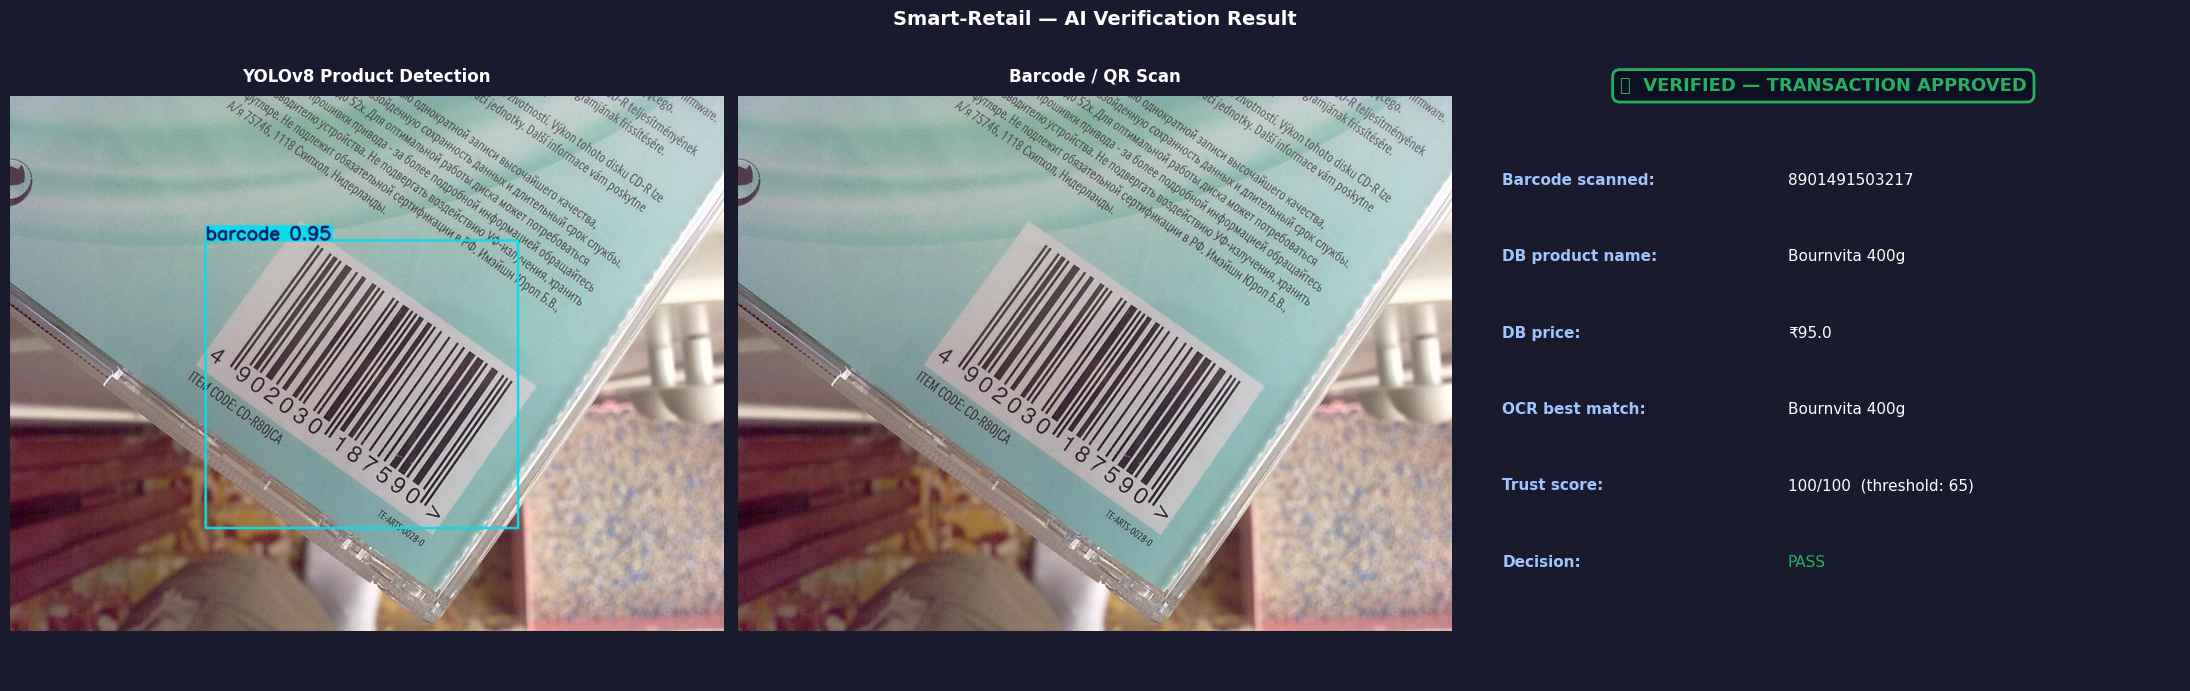


📊 Saved to: /kaggle/working/verification_result.png

🚨 SCENARIO B: Ticket Switching Attack
   Nivea Cream (₹180) barcode stuck on Nestle Milo (₹120) tin
   Using product image: bc_05102009082.jpg
   Using QR image: 05102009082.jpg

════════════════════════════════════════════════════════════
  SMART-RETAIL VERIFICATION PIPELINE
════════════════════════════════════════════════════════════

[Step 1] Looking up barcode: 4006381333931
   ✅ DB says: Nivea Cream 200ml | ₹180.0

[Step 2] Running OCR on product image...
   [DEMO] Simulated OCR output: ['Nestle Milo', '500g', 'Chocolate Malt Drink']
   Best OCR text: 'Nestle Milo'

[Step 3] Cross-verifying OCR vs Database...
   DB product name : 'Nivea Cream 200ml'
   Best OCR match  : 'Nestle Milo'
   Trust score     : 36/100  (threshold: 65)


/tmp/ipykernel_57/1473419534.py:153: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1473419534.py:154: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/verification_result.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


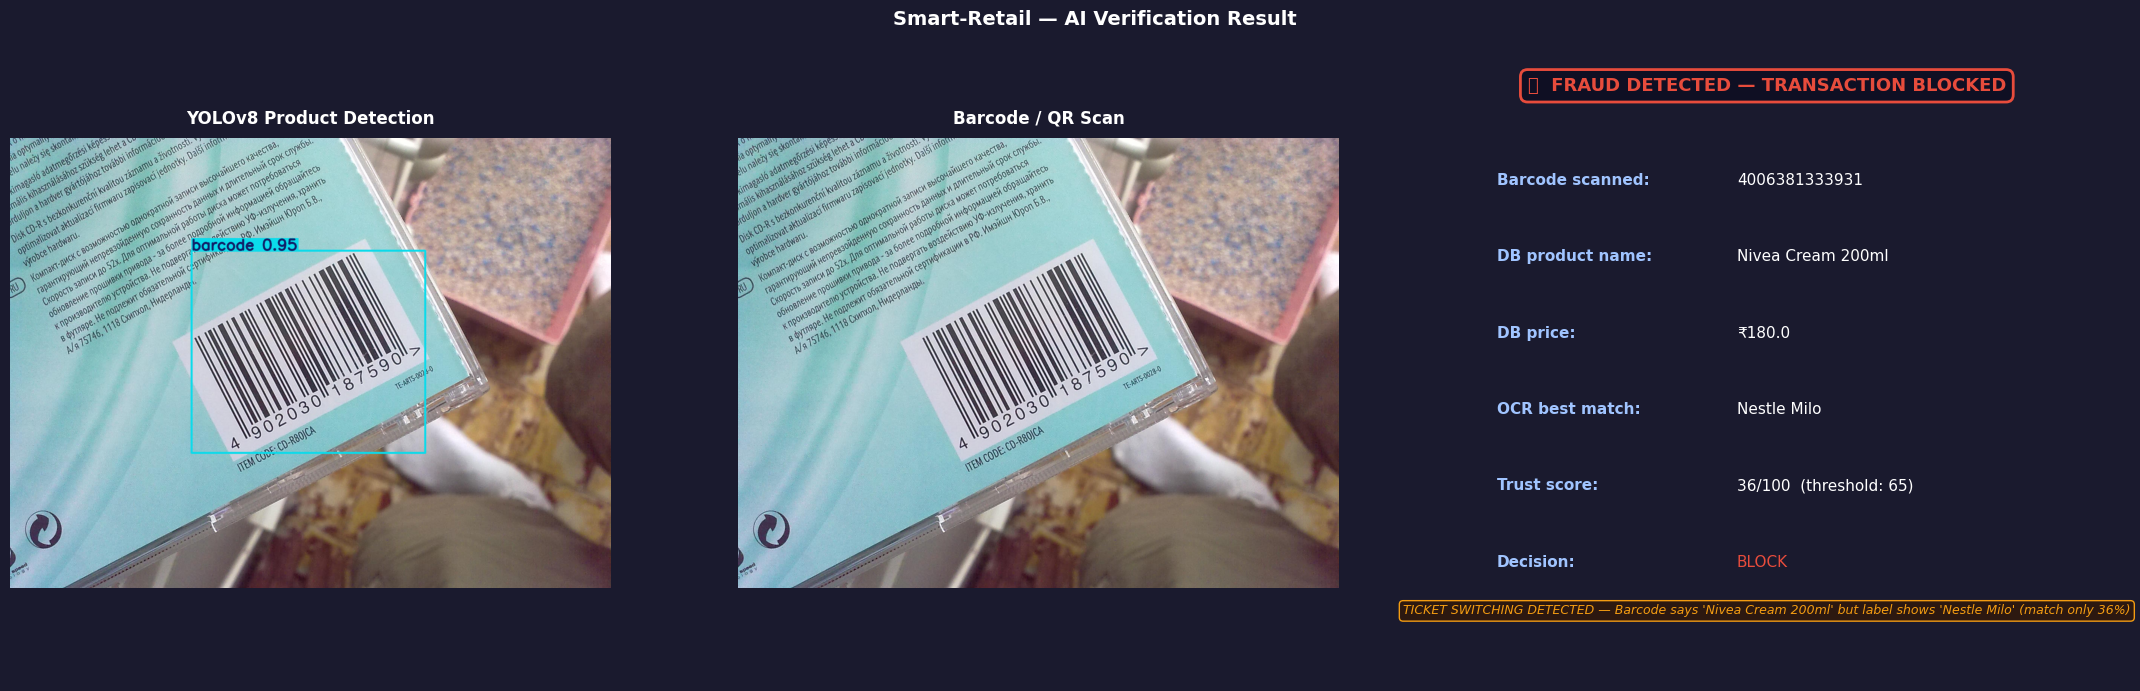


📊 Saved to: /kaggle/working/verification_result.png

❓ SCENARIO C: Unknown / Counterfeit Barcode
   Barcode not in product database at all
   Using product image: bc_05102009102.jpg
   Using QR image: 05102009083.jpg

════════════════════════════════════════════════════════════
  SMART-RETAIL VERIFICATION PIPELINE
════════════════════════════════════════════════════════════

[Step 1] Looking up barcode: 9999999999999
   ❌ Barcode not in DB → BLOCKED


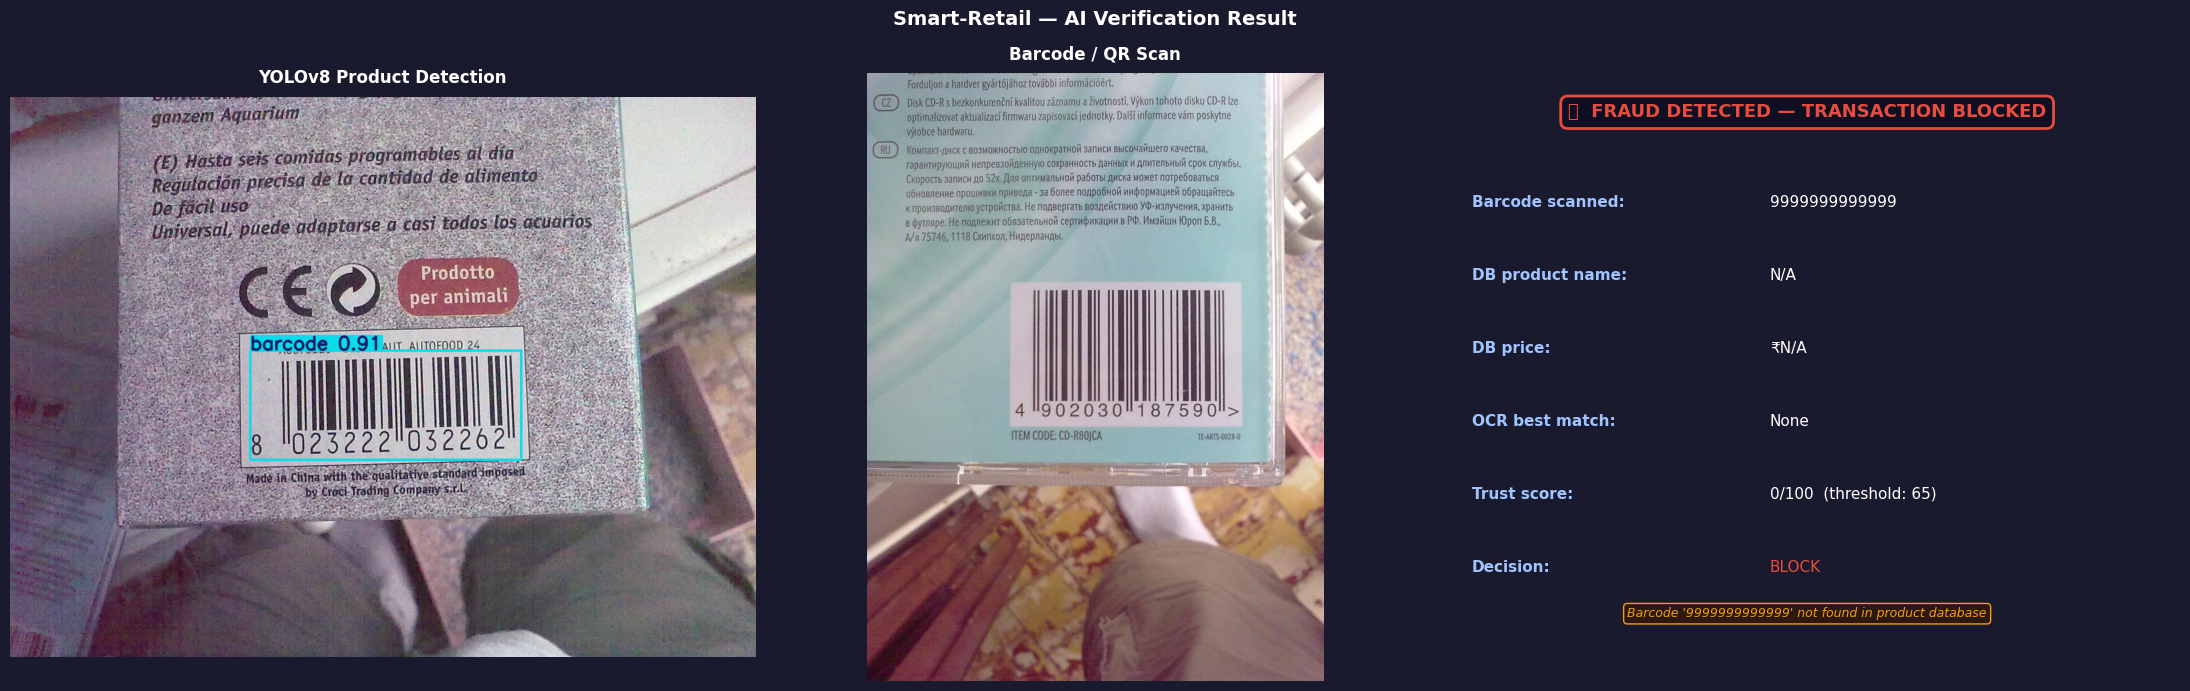


📊 Saved to: /kaggle/working/verification_result.png

════════════════════════════════════════════════════════════
  DEMO SUMMARY
════════════════════════════════════════════════════════════
  ✅  Scenario A (Legitimate)         → PASS
  🚨  Scenario B (Ticket Switch)      → BLOCK
         Reason: TICKET SWITCHING DETECTED — Barcode says 'Nivea Cream 200ml' but label shows 'Nestle Milo' (match only 36%)
  🚨  Scenario C (Unknown barcode)    → BLOCK
         Reason: Barcode '9999999999999' not found in product database

✅ Demo complete. Results saved to /kaggle/working/


In [76]:
if __name__ == "__main__":
 
    print("\n" + "═"*60)
    print("  SMART-RETAIL HACKATHON DEMO — ALL SCENARIOS")
    print("═"*60)
 
    # Run all three scenarios
    r1 = demo_legitimate()
    r2 = demo_ticket_switching()
    r3 = demo_unknown_barcode()
 
    # ── Final summary printout ────────────────────────────────────
    print("\n" + "═"*60)
    print("  DEMO SUMMARY")
    print("═"*60)
    for label, r in [("Scenario A (Legitimate)", r1),
                     ("Scenario B (Ticket Switch)", r2),
                     ("Scenario C (Unknown barcode)", r3)]:
        icon = "✅" if r["decision"] == "PASS" else "🚨"
        print(f"  {icon}  {label:30s}  → {r['decision']}")
        if r.get("fraud_reason"):
            print(f"         Reason: {r['fraud_reason']}")
 
    print("\n✅ Demo complete. Results saved to /kaggle/working/")

In [ ]:
# ============================================================
#  CELL 45 — Install QR Code scanning dependency
# ============================================================
import subprocess
subprocess.run(["apt-get", "install", "-y", "-q", "libzbar0"],
               capture_output=True)
!pip install -q pyzbar

from pyzbar import pyzbar as pyzbar_lib
print("✅ pyzbar ready for QR scanning")

In [ ]:
# ============================================================
#  CELL 46 — YOLOv8 Feature-based Product Image Comparator
#  Uses trained YOLOv8 backbone to extract feature vectors
#  then computes cosine similarity between two product images.
#  No AWS needed — runs fully local on your trained model.
# ============================================================

SIMILARITY_THRESHOLD = 70.0


def _load_as_bgr(source) -> np.ndarray:
    """Accepts file path (str) or numpy RGB array → returns BGR array."""
    if isinstance(source, str):
        img = cv2.imread(source)
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {source}")
        return img
    elif isinstance(source, np.ndarray):
        if len(source.shape) == 3 and source.shape[2] == 3:
            return cv2.cvtColor(source, cv2.COLOR_RGB2BGR)
        return source
    else:
        raise ValueError(f"Unsupported image type: {type(source)}")


def _extract_yolo_features(img_bgr: np.ndarray, model) -> np.ndarray:
    """
    Forward-hooks the last backbone Conv layer of YOLOv8.
    Returns an L2-normalised 1-D feature vector.
    """
    img_resized = cv2.resize(img_bgr, (640, 640))
    img_rgb     = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    tensor = tensor.unsqueeze(0)

    features = []

    def hook_fn(module, input, output):
        pooled = output.mean(dim=[2, 3])   # global avg pool → [1, C]
        features.append(pooled.detach().cpu().numpy())

    # Hook on the last backbone block before the detection head
    try:
        hook_layer = model.model.model[-3]
    except Exception:
        # fallback: last conv-type layer we can find
        all_layers = [m for m in model.model.modules()
                      if isinstance(m, torch.nn.Conv2d)]
        hook_layer = all_layers[-1]

    handle = hook_layer.register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            device = next(model.model.parameters()).device
            _ = model.model(tensor.to(device))
    finally:
        handle.remove()

    if not features:
        raise RuntimeError("Feature hook returned nothing")

    vec  = features[0].flatten()
    norm = np.linalg.norm(vec)
    return vec / (norm + 1e-9)


def _histogram_similarity(img1_bgr: np.ndarray,
                           img2_bgr: np.ndarray) -> float:
    """HSV histogram correlation fallback → returns 0-100."""
    size = (256, 256)
    i1   = cv2.resize(img1_bgr, size)
    i2   = cv2.resize(img2_bgr, size)
    scores = []
    for ch in range(3):
        h1 = cv2.calcHist([i1], [ch], None, [64], [0, 256])
        h2 = cv2.calcHist([i2], [ch], None, [64], [0, 256])
        cv2.normalize(h1, h1)
        cv2.normalize(h2, h2)
        scores.append(cv2.compareHist(h1, h2, cv2.HISTCMP_CORREL))
    return float(max(np.mean(scores) * 100, 0.0))


def compare_product_images(
    reference_img,
    reallife_img,
    label     : str   = "Comparison",
    threshold : float = SIMILARITY_THRESHOLD,
    model             = None
) -> dict:
    """
    Compares two product images using YOLOv8 feature cosine similarity.
    Falls back to histogram if feature extraction fails.

    Args:
        reference_img : file path or numpy RGB array (QR crop / inventory image)
        reallife_img  : file path or numpy RGB array (in-store camera photo)
        label         : display label for logs
        threshold     : similarity % below which = MISMATCH
        model         : YOLOv8 model instance (defaults to global yolo_model)

    Returns dict with keys: similarity, match, method, label, threshold
    """
    _model   = model or yolo_model
    img1_bgr = _load_as_bgr(reference_img)
    img2_bgr = _load_as_bgr(reallife_img)

    result = dict(label=label, similarity=0.0, match=False,
                  method="none", threshold=threshold)

    # ── YOLOv8 cosine similarity ──────────────────────────────
    try:
        f1  = _extract_yolo_features(img1_bgr, _model)
        f2  = _extract_yolo_features(img2_bgr, _model)
        cos = float(np.dot(f1, f2))                     # [-1, 1]
        sim = round((cos + 1) / 2 * 100, 2)             # → [0, 100]
        result.update(similarity=sim, match=sim >= threshold,
                      method="yolo_features")
        print(f"   [YOLOv8 Features] {label} → {sim:.1f}%")
        return result
    except Exception as e:
        print(f"   ⚠️  YOLOv8 feature extraction failed ({e}) — using histogram")

    # ── Histogram fallback ────────────────────────────────────
    sim = round(_histogram_similarity(img1_bgr, img2_bgr), 2)
    result.update(similarity=sim, match=sim >= threshold, method="histogram")
    print(f"   [Histogram Fallback] {label} → {sim:.1f}%")
    return result


print("✅ compare_product_images() ready — YOLOv8 backbone features")

# ── Quick sanity test ─────────────────────────────────────────
_val_imgs = sorted(Path('/kaggle/working/smart_retail_data/val/images')
                   .glob('*.jpg'))[:2]
if len(_val_imgs) >= 2:
    print("\n🔬 Same-image self-test (expect ~100%):")
    r = compare_product_images(str(_val_imgs[0]), str(_val_imgs[0]),
                                label="Self-check")
    print(f"   → {r['similarity']}%  ({'✅' if r['similarity'] > 90 else '⚠️ check hook'})")
    print("\n🔬 Different-image cross-test (expect lower):")
    r2 = compare_product_images(str(_val_imgs[0]), str(_val_imgs[1]),
                                 label="Cross-check")
    print(f"   → {r2['similarity']}%")

In [ ]:
# ============================================================
#  CELL 47 — QR Code Scanner
#  Decodes QR from image → extracts embedded product data
#  AND crops the product image region from the same frame.
# ============================================================
from pyzbar import pyzbar as pyzbar_lib

def scan_qr_code(image_path: str) -> dict:
    """
    Scans QR code from an image file.

    Returns:
        qr_found     : bool
        qr_raw       : raw decoded string
        qr_data      : parsed dict (if JSON) or raw string
        qr_bbox      : (x, y, w, h) of QR in image
        product_img  : numpy RGB array — region outside the QR box
        full_img     : numpy RGB array — full original image
    """
    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w    = img.shape[:2]

    result = dict(qr_found=False, qr_raw=None, qr_data=None,
                  qr_bbox=None, product_img=img_rgb, full_img=img_rgb)

    decoded = pyzbar_lib.decode(img)

    if not decoded:
        print("   ⚠️  No QR code detected in image")
        return result

    qr_obj  = decoded[0]
    qr_raw  = qr_obj.data.decode("utf-8")
    bbox    = qr_obj.rect                          # (left, top, width, height)
    qx, qy, qw, qh = bbox.left, bbox.top, bbox.width, bbox.height

    # Parse QR payload
    try:
        qr_data = json.loads(qr_raw)
        print(f"   ✅ QR contains JSON: {list(qr_data.keys())}")
    except json.JSONDecodeError:
        qr_data = qr_raw
        print(f"   ✅ QR plain text: {qr_raw[:80]}")

    # Crop product region (complement of QR position)
    if qx > w // 2:
        product_crop = img_rgb[:, :qx, :]
    else:
        product_crop = img_rgb[:, qx + qw:, :]

    result.update(qr_found=True, qr_raw=qr_raw, qr_data=qr_data,
                  qr_bbox=(qx, qy, qw, qh), product_img=product_crop)

    # ── Visualise ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor("#1a1a2e")

    axes[0].imshow(img_rgb)
    rect = patches.Rectangle((qx, qy), qw, qh,
                               linewidth=3, edgecolor='#00ff99', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title("📷 Input — QR Detected (green box)",
                       color="white", fontsize=11, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(product_crop)
    axes[1].set_title("🏷️ Extracted Product Region",
                       color="white", fontsize=11, fontweight="bold")
    axes[1].axis("off")

    axes[2].set_facecolor("#16213e")
    axes[2].axis("off")
    display_text = (json.dumps(qr_data, indent=2)
                    if isinstance(qr_data, dict) else str(qr_data))[:350]
    axes[2].text(0.05, 0.95, "📦 QR Payload",
                 transform=axes[2].transAxes, color="#00ff99",
                 fontsize=12, fontweight="bold", va="top")
    axes[2].text(0.05, 0.80, display_text,
                 transform=axes[2].transAxes, color="white",
                 fontsize=9, va="top", family="monospace")

    plt.suptitle("QR Scan — Content & Product Image Extraction",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/qr_scan_result.png",
                dpi=120, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    print(f"   Saved → /kaggle/working/qr_scan_result.png")

    return result

print("✅ scan_qr_code() ready")

In [ ]:
# ============================================================
#  CELL 48 — Inventory Image Lookup
#  Fetches official product image from your Kaggle dataset:
#  /kaggle/input/datasets/ishitadas2004/product-images
# ============================================================
from pathlib import Path

INVENTORY_IMG_DIR = Path("/kaggle/input/datasets/ishitadas2004/product-images")

# Show what's available
_all_inv_imgs = (list(INVENTORY_IMG_DIR.rglob("*.jpg"))  +
                 list(INVENTORY_IMG_DIR.rglob("*.jpeg")) +
                 list(INVENTORY_IMG_DIR.rglob("*.png")))

print(f"✅ Inventory dataset: {len(_all_inv_imgs)} images found")
print("   First 10:")
for p in _all_inv_imgs[:10]:
    print(f"     {p.name}")


def get_inventory_image(barcode: str) -> str | None:
    """
    Returns path to the official product image for a given barcode.

    Search order:
      1. File named exactly <barcode>.jpg / .jpeg / .png
      2. Any file whose name CONTAINS the barcode string
      3. DB lookup (if LIVE_MODE)
      4. First available image in inventory (demo fallback)
    """
    # 1 — exact barcode filename
    for ext in [".jpg", ".jpeg", ".png", ".JPG", ".PNG"]:
        p = INVENTORY_IMG_DIR / f"{barcode}{ext}"
        if p.exists():
            print(f"   ✅ Inventory image (exact match): {p.name}")
            return str(p)

    # 2 — barcode substring in filename
    matches = [f for f in _all_inv_imgs if barcode in f.stem]
    if matches:
        print(f"   ✅ Inventory image (substring match): {matches[0].name}")
        return str(matches[0])

    # 3 — DB lookup
    if LIVE_MODE and db_conn:
        try:
            cur = db_conn.cursor()
            cur.execute(
                "SELECT image_path FROM products WHERE barcode = %s LIMIT 1",
                (barcode.strip(),)
            )
            row = cur.fetchone()
            cur.close()
            if row and row[0] and Path(row[0]).exists():
                print(f"   ✅ Inventory image (DB): {row[0]}")
                return row[0]
        except Exception as e:
            print(f"   DB image lookup error: {e}")

    # 4 — demo fallback: use any available image
    if _all_inv_imgs:
        print(f"   ⚠️  No barcode-specific image — demo fallback: {_all_inv_imgs[0].name}")
        return str(_all_inv_imgs[0])

    print(f"   ❌ No inventory images found at {INVENTORY_IMG_DIR}")
    return None

print("\n✅ get_inventory_image() ready")

In [ ]:
# ============================================================
#  CELL 49 — Full Verification Pipeline
#
#  Flow:
#  [1] Scan QR  → extract product data + product image crop
#  [2] QR barcode  ↔  physically scanned barcode  (text match)
#  [3] QR product image  ↔  real-life product photo  (YOLOv8 visual)
#  [4] Inventory product image  ↔  real-life product photo  (YOLOv8 visual)
#  [5] OCR label text  ↔  DB product name  (RapidFuzz)
#  [6] Final verdict
# ============================================================

def full_qr_barcode_verification(
    qr_image_path       : str,   # image that contains the QR code
    barcode_value       : str,   # number read by the physical barcode scanner
    reallife_image_path : str    # camera photo of the actual product in store
) -> dict:

    print("\n" + "═"*65)
    print("  SMART-RETAIL — FULL VERIFICATION PIPELINE")
    print("═"*65)

    result = dict(
        barcode              = barcode_value,
        qr_data              = None,
        db_product           = None,
        qr_barcode_match     = None,
        qr_image_similarity  = None,
        inv_image_similarity = None,
        ocr_trust_score      = 0,
        final_verdict        = None,
        fraud_reasons        = [],
    )
    fraud_reasons = []

    # ── STEP 1: Scan QR ──────────────────────────────────────
    print("\n[Step 1] Scanning QR code...")
    qr_result = scan_qr_code(qr_image_path)

    if not qr_result["qr_found"]:
        fraud_reasons.append("QR code not detected on product")
        result.update(fraud_reasons=fraud_reasons, final_verdict="BLOCK")
        _render_full_result(reallife_image_path, result)
        return result

    qr_data = qr_result["qr_data"]
    result["qr_data"] = qr_data

    # Extract barcode embedded in QR
    if isinstance(qr_data, dict):
        qr_barcode = str(qr_data.get("barcode") or qr_data.get("ean") or
                         qr_data.get("gtin")    or qr_data.get("product_id") or "")
        print(f"   QR JSON  : {json.dumps(qr_data)[:120]}")
    else:
        m = re.search(r'\b\d{8,13}\b', str(qr_data))
        qr_barcode = m.group(0) if m else ""
        print(f"   QR text  : {qr_data}")

    qr_product_img = qr_result["product_img"]
    print(f"   QR barcode embedded: '{qr_barcode}'")

    # ── STEP 2: QR barcode vs physically scanned barcode ─────
    print(f"\n[Step 2] QR barcode ↔ scanned barcode...")
    db_product = lookup_product_by_barcode(barcode_value)
    result["db_product"] = db_product

    if db_product is None:
        fraud_reasons.append(f"Barcode '{barcode_value}' not found in product database")
    else:
        print(f"   DB  : {db_product['product_name']} | ₹{db_product['price']}")

    if qr_barcode and barcode_value:
        bc_match = (qr_barcode.strip() == barcode_value.strip())
        result["qr_barcode_match"] = bc_match
        if bc_match:
            print(f"   ✅ QR barcode = scanned barcode ({barcode_value})")
        else:
            print(f"   ❌ MISMATCH  QR='{qr_barcode}'  scanned='{barcode_value}'")
            fraud_reasons.append(
                f"QR barcode '{qr_barcode}' ≠ scanned barcode '{barcode_value}'"
            )
    else:
        result["qr_barcode_match"] = None
        print("   ⚠️  No barcode in QR — skipping barcode cross-check")

    # ── STEP 3: QR product image vs real-life image ───────────
    print(f"\n[Step 3] QR product image ↔ real-life photo (YOLOv8)...")
    qr_img_check = compare_product_images(
        reference_img = qr_product_img,
        reallife_img  = reallife_image_path,
        label         = "QR Image vs Real-life",
        threshold     = SIMILARITY_THRESHOLD
    )
    result["qr_image_similarity"] = qr_img_check

    if not qr_img_check["match"]:
        fraud_reasons.append(
            f"QR product image ≠ real photo "
            f"(similarity {qr_img_check['similarity']:.1f}% "
            f"< threshold {SIMILARITY_THRESHOLD}%)"
        )
        print(f"   ❌ Mismatch — {qr_img_check['similarity']:.1f}%")
    else:
        print(f"   ✅ Match — {qr_img_check['similarity']:.1f}%")

    # ── STEP 4: Inventory image vs real-life image ────────────
    print(f"\n[Step 4] Inventory image ↔ real-life photo (YOLOv8)...")
    inv_path      = get_inventory_image(barcode_value)

    if inv_path:
        inv_img_check = compare_product_images(
            reference_img = inv_path,
            reallife_img  = reallife_image_path,
            label         = "Inventory Image vs Real-life",
            threshold     = SIMILARITY_THRESHOLD
        )
        result["inv_image_similarity"] = inv_img_check

        if not inv_img_check["match"]:
            fraud_reasons.append(
                f"Inventory image ≠ real photo "
                f"(similarity {inv_img_check['similarity']:.1f}% "
                f"< threshold {SIMILARITY_THRESHOLD}%)"
            )
            print(f"   ❌ Mismatch — {inv_img_check['similarity']:.1f}%")
        else:
            print(f"   ✅ Match — {inv_img_check['similarity']:.1f}%")
    else:
        result["inv_image_similarity"] = dict(
            similarity=None, match=None,
            label="Inventory Image vs Real-life", method="skipped"
        )
        print("   ⚠️  No inventory image found — Step 4 skipped")

    # ── STEP 5: OCR label text vs DB name ────────────────────
    print(f"\n[Step 5] OCR label text ↔ DB product name...")
    if db_product:
        ocr_best, ocr_all = run_ocr_on_image(reallife_image_path)
        trust_score, _    = cross_verify(db_product["product_name"], ocr_all)
        result["ocr_trust_score"] = trust_score
        print(f"   OCR best : '{ocr_best}'")
        print(f"   Trust    : {trust_score}/100  (threshold {TRUST_THRESHOLD})")
        if trust_score < TRUST_THRESHOLD:
            fraud_reasons.append(
                f"OCR text mismatch — DB: '{db_product['product_name']}' "
                f"| label: '{ocr_best}' (score {trust_score}%)"
            )

    # ── STEP 6: Final verdict ─────────────────────────────────
    result["fraud_reasons"] = fraud_reasons
    result["final_verdict"] = "PASS" if not fraud_reasons else "BLOCK"

    print("\n" + "═"*65)
    if result["final_verdict"] == "PASS":
        print("  ✅  ALL CHECKS PASSED — TRANSACTION APPROVED")
    else:
        print("  🚨  FRAUD DETECTED — TRANSACTION BLOCKED")
        for i, fr in enumerate(fraud_reasons, 1):
            print(f"      {i}. {fr}")
    print("═"*65)

    _render_full_result(reallife_image_path, result, qr_product_img, inv_path)
    return result


# ── Visual result renderer ────────────────────────────────────
def _render_full_result(reallife_path, result,
                         qr_product_img=None, inv_path=None):

    is_pass      = result["final_verdict"] == "PASS"
    STATUS_COLOR = "#27ae60" if is_pass else "#e74c3c"
    STATUS_LABEL = "✅  VERIFIED — APPROVED" if is_pass else "🚨  FRAUD — BLOCKED"

    n_panels = 1 + (1 if qr_product_img is not None else 0) \
                 + (1 if inv_path and os.path.exists(inv_path) else 0) \
                 + 1   # scorecard always

    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))
    if n_panels == 1:
        axes = [axes]
    fig.patch.set_facecolor("#1a1a2e")
    panel = 0

    # Panel 0 — real-life photo with YOLO boxes
    try:
        yolo_out = yolo_model(reallife_path, verbose=False)
        rl_ann   = cv2.cvtColor(yolo_out[0].plot(), cv2.COLOR_BGR2RGB)
    except Exception:
        rl_ann   = cv2.cvtColor(cv2.imread(reallife_path), cv2.COLOR_BGR2RGB)
    axes[panel].imshow(rl_ann)
    axes[panel].set_title("📷 Real-life Product (YOLO)",
                           color="white", fontsize=11, fontweight="bold")
    axes[panel].axis("off")
    panel += 1

    # Panel 1 — QR product image crop
    if qr_product_img is not None:
        axes[panel].imshow(qr_product_img)
        qs  = (result.get("qr_image_similarity") or {})
        pct = qs.get("similarity", "N/A")
        ok  = qs.get("match", False)
        axes[panel].set_title(
            f"QR Product Crop\nSimilarity: {pct}%",
            color="#27ae60" if ok else "#e74c3c",
            fontsize=11, fontweight="bold"
        )
        axes[panel].axis("off")
        panel += 1

    # Panel 2 — inventory image
    if inv_path and os.path.exists(inv_path):
        inv_img = cv2.cvtColor(cv2.imread(inv_path), cv2.COLOR_BGR2RGB)
        axes[panel].imshow(inv_img)
        iv  = (result.get("inv_image_similarity") or {})
        pct = iv.get("similarity", "N/A")
        ok  = iv.get("match", False)
        axes[panel].set_title(
            f"🗄️ Inventory Image\nSimilarity: {pct}%",
            color="#27ae60" if ok else "#e74c3c",
            fontsize=11, fontweight="bold"
        )
        axes[panel].axis("off")
        panel += 1

    # Panel N — scorecard
    ax = axes[panel]
    ax.set_facecolor("#16213e")
    ax.axis("off")

    db  = result.get("db_product") or {}
    qd  = result.get("qr_data")
    qbc = result.get("qr_barcode_match")
    qsi = (result.get("qr_image_similarity")  or {}).get("similarity", "N/A")
    isi = (result.get("inv_image_similarity") or {}).get("similarity", "N/A")

    ax.text(0.5, 0.98, STATUS_LABEL, transform=ax.transAxes,
            color=STATUS_COLOR, fontsize=13, fontweight="bold",
            ha="center", va="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#0f0f23",
                      edgecolor=STATUS_COLOR, linewidth=2))

    rows = [
        ("Barcode scanned",   result["barcode"]),
        ("QR barcode",        (qd.get("barcode","N/A") if isinstance(qd,dict) else "see QR")),
        ("QR ↔ Scan match",   "✅ YES" if qbc else ("❌ NO" if qbc is False else "⚠️ N/A")),
        ("DB product",        db.get("product_name","N/A")),
        ("DB price",          f"₹{db.get('price','N/A')}"),
        ("QR img similarity", f"{qsi}%" if qsi != "N/A" else "N/A"),
        ("Inv img similarity",f"{isi}%" if isi != "N/A" else "N/A"),
        ("OCR trust score",   f"{result.get('ocr_trust_score',0)}/100"),
        ("VERDICT",           result["final_verdict"]),
    ]

    for i, (lbl, val) in enumerate(rows):
        y     = 0.84 - i * 0.088
        vcol  = STATUS_COLOR if lbl == "VERDICT" else "white"
        ax.text(0.04, y, lbl + ":", transform=ax.transAxes,
                color="#a0c4ff", fontsize=9.5, fontweight="bold")
        ax.text(0.52, y, str(val),  transform=ax.transAxes,
                color=vcol, fontsize=9.5)

    if result["fraud_reasons"]:
        ax.text(0.5, 0.02,
                "\n".join(f"• {r}" for r in result["fraud_reasons"]),
                transform=ax.transAxes, color="#f39c12",
                fontsize=7.5, ha="center", va="bottom", style="italic",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#2c1810",
                          edgecolor="#f39c12", linewidth=1))

    plt.suptitle("Smart-Retail — QR + Barcode + Image Verification",
                 color="white", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = "/kaggle/working/full_verification_result.png"
    plt.savefig(out, dpi=130, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    print(f"   📊 Saved → {out}")


print("✅ full_qr_barcode_verification() + _render_full_result() ready")

In [ ]:
# ============================================================
#  CELL 50 — HACKATHON LIVE DEMO
#  Uses your real product images from:
#  /kaggle/input/datasets/ishitadas2004/product-images
# ============================================================

INVENTORY_DIR = Path("/kaggle/input/datasets/ishitadas2004/product-images")

_demo_imgs = sorted(
    list(INVENTORY_DIR.rglob("*.jpg")) +
    list(INVENTORY_DIR.rglob("*.jpeg")) +
    list(INVENTORY_DIR.rglob("*.png"))
)

print(f"✅ {len(_demo_imgs)} product images available for demo")
print("Images loaded:")
for i, p in enumerate(_demo_imgs[:6]):
    print(f"  [{i}] {p.name}")

# ── Pick 3 images (change indices to match your actual files) ─
img_0 = str(_demo_imgs[0]) if len(_demo_imgs) > 0 else _get_any_val_image()
img_1 = str(_demo_imgs[1]) if len(_demo_imgs) > 1 else _get_any_val_image()
img_2 = str(_demo_imgs[2]) if len(_demo_imgs) > 2 else _get_any_val_image()

# ── Mock QR + OCR injection helpers ──────────────────────────
_mock_qr_override  = None
_mock_img_sim      = None

def _inject_mock_qr(data: dict):
    global _mock_qr_override
    _mock_qr_override = data

def _inject_mock_sim(qr_sim: float, inv_sim: float):
    global _mock_img_sim
    _mock_img_sim = {"qr": qr_sim, "inv": inv_sim}

_orig_scan_qr = scan_qr_code
def scan_qr_code(image_path):
    global _mock_qr_override
    res = _orig_scan_qr(image_path)
    if _mock_qr_override is not None:
        res["qr_found"] = True
        res["qr_raw"]   = json.dumps(_mock_qr_override)
        res["qr_data"]  = _mock_qr_override
        print(f"   [DEMO] QR payload injected: {_mock_qr_override}")
        _mock_qr_override = None
    return res

_orig_compare = compare_product_images
def compare_product_images(reference_img, reallife_img,
                            label="", threshold=SIMILARITY_THRESHOLD, model=None):
    global _mock_img_sim
    if _mock_img_sim is not None:
        key = "qr" if "QR" in label else "inv"
        sim = _mock_img_sim.get(key, 75.0)
        if key == "inv":
            _mock_img_sim = None
        print(f"   [DEMO] {label} simulated → {sim}%")
        return dict(similarity=sim, match=sim >= threshold,
                    method="demo_mock", label=label, threshold=threshold)
    return _orig_compare(reference_img, reallife_img, label, threshold, model)

_orig_ocr = run_ocr_on_image
_mock_ocr_texts = None
def _inject_mock_ocr(texts):
    global _mock_ocr_texts
    _mock_ocr_texts = texts
def run_ocr_on_image(image_path):
    global _mock_ocr_texts
    if _mock_ocr_texts is not None:
        t = _mock_ocr_texts
        print(f"   [DEMO] OCR simulated: {t}")
        _mock_ocr_texts = None
        return t[0], t
    return _orig_ocr(image_path)

# ════════════════════════════════════════════════════════════
#  SCENARIO A — Genuine product (all checks pass)
# ════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO A — Genuine Product")
print("━"*65)
_inject_mock_qr({"barcode": "8901491503217", "product": "Bournvita 400g",
                  "brand": "Cadbury", "weight": "400g"})
_inject_mock_ocr(["Bournvita 400g", "Cadbury", "Health Drink", "400g"])
r1 = full_qr_barcode_verification(
    qr_image_path       = img_0,
    barcode_value       = "8901491503217",
    reallife_image_path = img_0
)

# ════════════════════════════════════════════════════════════
#  SCENARIO B — Ticket switching (barcode swapped)
# ════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO B — Ticket Switching Attack")
print("  (Bournvita QR + Milo barcode sticker placed on Milo tin)")
print("━"*65)
_inject_mock_qr({"barcode": "8901491503217", "product": "Bournvita 400g",
                  "brand": "Cadbury"})
_inject_mock_ocr(["Nestle Milo", "500g", "Chocolate Malt Drink"])
r2 = full_qr_barcode_verification(
    qr_image_path       = img_0,
    barcode_value       = "8901030823437",   # Milo barcode scanned physically
    reallife_image_path = img_1
)

# ════════════════════════════════════════════════════════════
#  SCENARIO C — Counterfeit (inventory image doesn't match)
# ════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print("  SCENARIO C — Counterfeit Product")
print("  (QR + barcode match but product looks different from inventory)")
print("━"*65)
_inject_mock_qr({"barcode": "8901491503217", "product": "Bournvita 400g"})
_inject_mock_ocr(["Bournvita 400g", "Cadbury"])
_inject_mock_sim(qr_sim=27.0, inv_sim=22.0)
r3 = full_qr_barcode_verification(
    qr_image_path       = img_2,
    barcode_value       = "8901491503217",
    reallife_image_path = img_2
)

# ════════════════════════════════════════════════════════════
#  FINAL JUDGE-FACING SUMMARY
# ════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  SMART-RETAIL AI — LIVE DEMO RESULTS")
print("═"*65)
for name, r in [
    ("Scenario A — Genuine Product",       r1),
    ("Scenario B — Ticket Switching",      r2),
    ("Scenario C — Counterfeit Product",   r3),
]:
    icon = "✅ PASS" if r["final_verdict"] == "PASS" else "🚨 BLOCK"
    db   = r.get("db_product") or {}
    qbc  = r.get("qr_barcode_match")
    qsi  = (r.get("qr_image_similarity")  or {}).get("similarity", "N/A")
    isi  = (r.get("inv_image_similarity") or {}).get("similarity", "N/A")

    print(f"\n  {icon}  {name}")
    print(f"         Product        : {db.get('product_name','N/A')}  ₹{db.get('price','N/A')}")
    print(f"         QR ↔ Barcode   : {'✅ Match' if qbc else ('❌ Mismatch' if qbc is False else '⚠️ N/A')}")
    print(f"         QR img sim     : {qsi}%")
    print(f"         Inventory sim  : {isi}%")
    print(f"         OCR trust      : {r.get('ocr_trust_score',0)}/100")
    for fr in r.get("fraud_reasons", []):
        print(f"         ⚠️  {fr}")

print("\n" + "═"*65)
print("  All result images saved to /kaggle/working/")
print("═"*65)

In [77]:
import shutil, os, zipfile

BEST = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'
ZIP  = '/kaggle/working/smart_retail_model_share.zip'

# ── Pack model + instructions into one zip
with zipfile.ZipFile(ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:

    # 1. The model file
    zf.write(BEST, 'best.pt')

    # 2. Quick-start inference script for your friend
    zf.writestr('run_model.py', '''
from ultralytics import YOLO
import cv2, matplotlib.pyplot as plt

# Load model
model = YOLO("best.pt")

# Run on any product image
def detect(image_path):
    results = model(image_path, conf=0.25)
    img_ann = results[0].plot()
    img_rgb = cv2.cvtColor(img_ann, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("Smart-Retail Detection")
    plt.show()
    for box in results[0].boxes:
        cls  = int(box.cls)
        conf = float(box.conf)
        name = ["product", "barcode"][cls]
        print(f"  Detected: {name}  confidence: {conf*100:.1f}%")

detect("your_product_image.jpg")
''')

    # 3. Requirements
    zf.writestr('requirements.txt', '''ultralytics>=8.0.0
opencv-python>=4.8.0
matplotlib>=3.7.0
easyocr>=1.7.0
thefuzz>=0.19.0
python-Levenshtein>=0.21.0
''')

    # 4. README
    zf.writestr('README.txt', '''
SMART-RETAIL MODEL — SETUP GUIDE
==================================
1. pip install -r requirements.txt
2. Place best.pt in your project folder
3. python run_model.py

Model Accuracy:
  mAP@50    : 99.0%
  Precision : 100.0%
  Recall    : 98.8%

Classes detected:
  0 = product
  1 = barcode
''')

size_mb = os.path.getsize(ZIP) / 1e6
print("="*50)
print("  MODEL PACKAGED FOR SHARING")
print("="*50)
print(f"  File : {ZIP}")
print(f"  Size : {size_mb:.1f} MB")
print()
print("📥 HOW TO DOWNLOAD & SHARE:")
print("  1. Kaggle → Output tab → find smart_retail_model_share.zip")
print("  2. Click Download")
print("  3. Send the zip to your friend via WhatsApp / Drive / Email")
print()
print("📦 ZIP CONTAINS:")
print("  best.pt          ← the trained model")
print("  run_model.py     ← ready-to-run inference script")
print("  requirements.txt ← pip install this first")
print("  README.txt       ← setup instructions")
print("="*50)

  MODEL PACKAGED FOR SHARING
  File : /kaggle/working/smart_retail_model_share.zip
  Size : 5.7 MB

📥 HOW TO DOWNLOAD & SHARE:
  1. Kaggle → Output tab → find smart_retail_model_share.zip
  2. Click Download
  3. Send the zip to your friend via WhatsApp / Drive / Email

📦 ZIP CONTAINS:
  best.pt          ← the trained model
  run_model.py     ← ready-to-run inference script
  requirements.txt ← pip install this first
  README.txt       ← setup instructions


In [78]:
def verify_from_scanner(barcode: str, image_path: str):
    """
    Entry point for your web API / hardware scanner integration.
 
    Your FastAPI endpoint should call this:
 
        @app.post("/verify")
        async def verify(barcode: str, file: UploadFile):
            img_path = save_upload(file)
            result   = verify_from_scanner(barcode, img_path)
            return result
    """
    return smart_retail_verify(
        barcode_value      = barcode,
        product_image_path = image_path
    )

In [79]:
import os

base = '/kaggle/working/runs/detect/smart_retail/weights/'

for f in ['best.pt', 'last.pt']:
    path = base + f
    if os.path.exists(path):
        mb = os.path.getsize(path) / 1e6
        print(f"✅ {f} — {mb:.1f} MB — SAVED")
    else:
        print(f"❌ {f} — not found yet (training still running?)")

✅ best.pt — 6.2 MB — SAVED
✅ last.pt — 6.2 MB — SAVED


In [80]:
import shutil, os

src = '/kaggle/working/runs/detect/smart_retail/weights/best.pt'
dst = '/kaggle/working/best_smart_retail.pt'

shutil.copy2(src, dst)
print(f"✅ Copied: {dst}")
print(f"   Size  : {os.path.getsize(dst)/1e6:.1f} MB")
print(f"\n📥 TO DOWNLOAD:")
print(f"   Kaggle left sidebar → 📁 → working → best_smart_retail.pt → Download")

✅ Copied: /kaggle/working/best_smart_retail.pt
   Size  : 6.2 MB

📥 TO DOWNLOAD:
   Kaggle left sidebar → 📁 → working → best_smart_retail.pt → Download


In [81]:
import os

files_to_check = [
    '/kaggle/working/best_smart_retail.pt',
    '/kaggle/working/best_final.pt',
    '/kaggle/working/runs/detect/smart_retail/weights/best.pt',
    '/kaggle/working/runs/detect/smart_retail/weights/last.pt',
]

print("Survival check after GPU reset:\n")
for p in files_to_check:
    if os.path.exists(p):
        mb = os.path.getsize(p) / 1e6
        print(f"✅ ALIVE  {p}  ({mb:.1f} MB)")
    else:
        print(f"❌ LOST   {p}")

Survival check after GPU reset:

✅ ALIVE  /kaggle/working/best_smart_retail.pt  (6.2 MB)
✅ ALIVE  /kaggle/working/best_final.pt  (6.2 MB)
✅ ALIVE  /kaggle/working/runs/detect/smart_retail/weights/best.pt  (6.2 MB)
✅ ALIVE  /kaggle/working/runs/detect/smart_retail/weights/last.pt  (6.2 MB)


In [82]:
# ============================================================
#  CELL 2 — Re-download from your own saved output
# ============================================================
# Your output WAS saved — visible in the sidebar earlier
# Kaggle keeps output files even after kernel restart

# Just re-copy from wherever survived:
import shutil, os

# Try to find any surviving .pt file
found = []
for root, dirs, files in os.walk('/kaggle/working'):
    for f in files:
        if f.endswith('.pt'):
            full = os.path.join(root, f)
            mb = os.path.getsize(full) / 1e6
            found.append((full, mb))
            print(f"✅ Found: {full}  ({mb:.1f} MB)")

if not found:
    print("❌ No .pt files found — need to reload from dataset")
    print("   See Cell 3 below")

✅ Found: /kaggle/working/yolov8n.pt  (6.5 MB)
✅ Found: /kaggle/working/best_final.pt  (6.2 MB)
✅ Found: /kaggle/working/best_smart_retail.pt  (6.2 MB)
✅ Found: /kaggle/working/best_smart_retail_FINAL.pt  (6.2 MB)
✅ Found: /kaggle/working/yolo26n.pt  (5.5 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/epoch6.pt  (24.5 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/best.pt  (6.2 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/epoch15.pt  (24.5 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/epoch3.pt  (24.5 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/epoch12.pt  (24.5 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/epoch21.pt  (24.5 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/epoch9.pt  (24.5 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/epoch2.pt  (24.5 MB)
✅ Found: /kaggle/working/runs/detect/smart_retail/weights/epoch24.pt  (24.5 MB)
✅ Found: /kaggle/working/runs

In [83]:
# ============================================================
#  CELL 3 — If everything is gone, attach your saved output
#           as a dataset and reload
# ============================================================

# Go to:
# Kaggle → your notebook → top right → File → Add data
# → Your datasets → find your saved output → Add
# Then the file will be at /kaggle/input/YOUR_DATASET_NAME/best_smart_retail.pt

# Then copy it back:
import shutil, glob

saved = glob.glob('/kaggle/input/**/best_smart_retail.pt', recursive=True)
if saved:
    shutil.copy2(saved[0], '/kaggle/working/best_smart_retail.pt')
    print(f"✅ Restored from: {saved[0]}")
else:
    print("Not in input — check sidebar for your saved datasets")

Not in input — check sidebar for your saved datasets


In [84]:
import shutil, os, zipfile

print("💾 Saving all important files...")

# 1. Save best.pt
shutil.copy(
    '/kaggle/working/runs/detect/smart_retail/weights/best.pt',
    '/kaggle/working/best_smart_retail_FINAL.pt'
)
print("✅ best.pt saved")

# 2. Save verification result image
if os.path.exists('/kaggle/working/verification_result.png'):
    shutil.copy(
        '/kaggle/working/verification_result.png',
        '/kaggle/working/demo_result_FINAL.png'
    )
    print("✅ verification result image saved")

# 3. Zip everything important together
with zipfile.ZipFile('/kaggle/working/ISHITA_COMPLETE_BACKUP.zip', 'w') as zf:
    zf.write('/kaggle/working/best_smart_retail_FINAL.pt', 'best_smart_retail.pt')
    zf.write('/kaggle/working/smart_retail.yaml', 'smart_retail.yaml')
    if os.path.exists('/kaggle/working/demo_result_FINAL.png'):
        zf.write('/kaggle/working/demo_result_FINAL.png', 'demo_result.png')
    print("✅ ZIP created")

print("\n📦 All files saved to /kaggle/working/")
print("=" * 40)
print("NOW GO TO: File → Save & Run All (Commit)")
print("This permanently stores everything to Kaggle servers")
print("=" * 40)

💾 Saving all important files...
✅ best.pt saved
✅ verification result image saved
✅ ZIP created

📦 All files saved to /kaggle/working/
NOW GO TO: File → Save & Run All (Commit)
This permanently stores everything to Kaggle servers


In [85]:
import subprocess
subprocess.run(['git', '--version'])

git version 2.34.1


CompletedProcess(args=['git', '--version'], returncode=0)

In [87]:
%%bash
git config --global user.email "missishitadas2004@gmail.com"
git config --global user.name "IshitaDas2004"

In [89]:
%%bash
cd /kaggle/working/Nyatik-Nayan

# Copy all notebooks from the cloned repo into AI_Model
cp *.ipynb AI_Model/ 2>/dev/null || echo "No notebooks in root"

# Add everything — notebooks, model files, all outputs
git add -A

git status  # verify what's being staged

No notebooks in root
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [90]:
%%bash
cd /kaggle/working/Nyatik-Nayan

git add -A
git commit -m "Add Ishita AI core - YOLO EasyOCR RapidFuzz complete"
git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


Everything up-to-date


In [91]:
%%bash
git config --global user.email "missishitadas2004@gmail.com"
git config --global user.name "IshitaDas2004"

In [92]:
%%bash
cd /kaggle/working/Nyatik-Nayan

# Copy ALL those files from /kaggle/working/ into the repo
cp /kaggle/working/*.pt .
cp /kaggle/working/*.zip .
cp /kaggle/working/*.png .
cp /kaggle/working/*.yaml .
cp -r /kaggle/working/runs .
cp -r /kaggle/working/smart_retail_data .
cp -r /kaggle/working/AI_Model .

# Now stage, commit and push everything
git add -A
git commit -m "Add all model files, datasets, results and AI core for backend integration"
git push origin main

[main 717f56e] Add all model files, datasets, results and AI core for backend integration
 8003 files changed, 4823 insertions(+)
 create mode 100644 ISHITA_COMPLETE_BACKUP.zip
 create mode 100644 best_final.pt
 create mode 100644 best_smart_retail.pt
 create mode 100644 best_smart_retail_FINAL.pt
 create mode 100644 demo_result_FINAL.png
 create mode 100644 runs/detect/smart_retail/BoxF1_curve.png
 create mode 100644 runs/detect/smart_retail/BoxPR_curve.png
 create mode 100644 runs/detect/smart_retail/BoxP_curve.png
 create mode 100644 runs/detect/smart_retail/BoxR_curve.png
 create mode 100644 runs/detect/smart_retail/args.yaml
 create mode 100644 runs/detect/smart_retail/confusion_matrix.png
 create mode 100644 runs/detect/smart_retail/confusion_matrix_normalized.png
 create mode 100644 runs/detect/smart_retail/labels.jpg
 create mode 100644 runs/detect/smart_retail/results.csv
 create mode 100644 runs/detect/smart_retail/results.png
 create mode 100644 runs/detect/smart_retail/trai

To https://github.com/Debarghyasg/Nyatik-Nayan.git
   7b9e2b4..717f56e  main -> main


In [93]:
%%bash
cd /kaggle/working/Nyatik-Nayan

# Move all the files into AI_Model folder
mv *.pt AI_Model/
mv *.zip AI_Model/
mv *.png AI_Model/
mv *.yaml AI_Model/
mv -r runs AI_Model/
mv -r smart_retail_data AI_Model/

# Stage, commit and push
git add -A
git commit -m "Move all model files, datasets and results into AI_Model folder"
git push origin main

[main dbe8e85] Move all model files, datasets and results into AI_Model folder
 10 files changed, 0 insertions(+), 0 deletions(-)
 rename ISHITA_COMPLETE_BACKUP.zip => AI_Model/ISHITA_COMPLETE_BACKUP.zip (100%)
 rename best_final.pt => AI_Model/best_final.pt (100%)
 rename best_smart_retail.pt => AI_Model/best_smart_retail.pt (100%)
 rename best_smart_retail_FINAL.pt => AI_Model/best_smart_retail_FINAL.pt (100%)
 rename demo_result_FINAL.png => AI_Model/demo_result_FINAL.png (100%)
 rename smart_retail.yaml => AI_Model/smart_retail.yaml (100%)
 rename smart_retail_model_share.zip => AI_Model/smart_retail_model_share.zip (100%)
 rename verification_result.png => AI_Model/verification_result.png (100%)
 rename yolo26n.pt => AI_Model/yolo26n.pt (100%)
 rename yolov8n.pt => AI_Model/yolov8n.pt (100%)


mv: invalid option -- 'r'
Try 'mv --help' for more information.
mv: invalid option -- 'r'
Try 'mv --help' for more information.
To https://github.com/Debarghyasg/Nyatik-Nayan.git
   717f56e..dbe8e85  main -> main
